# FedAGA — Federated Learning with Adaptive Graph-based Aggregation

**Faithful implementation of** Ge, Xu, Lu, Xu, Sheng & Zheng, *FedAGA: A federated learning
framework for enhanced inter-client relationship learning*, **Knowledge-Based Systems 286
(2024) 111399** (`FLC_023`), **applied to the `fedwater` water-distribution pipeline.**

---

## What FedAGA is, in one paragraph

Personalized federated learning normally aggregates client models by **distance between
parameters or losses** — a Euclidean notion of "these two clients are alike". FedAGA
argues that is the wrong object. Instead it aggregates the **accumulated gradients**
`R_i(θ_i)` — the total parameter displacement a client makes during its local epochs —
and measures inter-client relationship by the **cosine similarity of those displacement
vectors**. Similar clients are the ones being pulled in the same direction. Those
similarities become a weighted graph, the graph becomes a per-client aggregation weight
via softmax, and each client downloads a **personalized** update rather than a common
one. Two gate criteria decide when the graph is trustworthy enough to use at all; until
they are met, the server falls back to plain FedAvg.

## Why this is a different animal from FLC_033

`FLC_033` (the other notebook in this project) estimated a **state matrix** whose
off-diagonal blocks *are* the cross-client Granger causality — an object directly
comparable to `gt_topology`. FedAGA is a **training algorithm**: it produces personalized
models, and the inter-client relationship falls out as a by-product (the matrix `p_ij`).
So this notebook has to actually train something. It does — a sequence autoencoder per
district, on the same windows `fl_preprocessing` builds — and then evaluates four
different things:

| # | Question | Against what |
|---|---|---|
| **0** | **Do the districts cluster by demand regime, and does the drifting one change sides?** | **`DISTRICT_STATE`, the coded (init, final) regimes** |
| 1 | Are the personalized models better? | 9 baselines from §4.1 (Tables 1–2 analogue) |
| 2 | Is the recovered relationship graph the hydraulic one? | `gt_topology.open_boundary_pipes` (Figs. 5–6 analogue) |
| 3 | Does personalization help detect the drift? | `gt_drift_schedule` |

**Question 0 is the headline** (§IV.5–IV.6) and it is what FedAGA is actually built for:
`s_ij` is a client-similarity matrix and the `s_ij > 0` edge rule is a partitioning
primitive. What the paper never does — and what the research question needs — is to
compute that similarity **per time phase** and turn it into a **partition** that can be
scored. With

```
A: LL→LL   B: HH→HH   C: LL→LL   D: HH→LL   E: HH→HH
```

the target partitions are `{A,C} | {B,D,E}` early and `{A,C,D} | {B,E}` late, and the one
question that matters is whether a federated method sees **D cross over**.

Question 2 is the one that makes the two notebooks directly comparable: two entirely
different federated methods, both asked to name the hydraulic neighbours. Note that
questions 0 and 2 have *different* right answers — regime membership and pipe adjacency
are not the same relation — so a signal that is good at one may be bad at the other.

## How it is organised

| Part | Content | Paper anchor |
|---|---|---|
| **0** | Configuration, imports | — |
| **I** | FedAGA implemented equation by equation | §3, eqs. 1–8, Fig. 2, Alg. 1 |
| **II** | The nine baselines | §4.1 |
| **III** | Synthetic non-IID harness where the true client relationships are KNOWN | §4.2–4.4, Figs. 5–6, Tables 3–4 |
| **IV** | Application to `fedwater` (5 districts) | §4 protocol |
| **V** | Sanity-check register, Kedro plug-in surface, limitations | `fedwater_architecture.md` §9 |

## Conventions

* A model's parameters are handled as one flat vector `θ ∈ R^d` (`flat_params` /
  `set_flat_params`). Every FedAGA quantity — `R_i`, `s_ij`, the aggregation — is then
  literally the vector algebra the paper writes, with no per-layer bookkeeping in the way.
* `R_i(θ_i)` is the **accumulated gradient** of eq. (2). Under plain SGD it is exactly
  `θ_i^after − θ_i^before`; Sanity Check I.1 verifies that identity to machine precision
  rather than assuming it.
* Rounds are indexed `t = 1…T`, local epochs `e = 1…E`, matching Algorithm 1.

## Two things about the paper worth knowing before you read the results

1. **The softmax in eq. (5) is applied to cosine similarities, which live in `[-1, 1]`.**
   The largest possible weight ratio between two neighbours is therefore `e² ≈ 7.4`, and
   in practice similarities occupy a much narrower band than that — so `p_ij` comes out
   **close to uniform**, i.e. close to FedAvg over the neighbour set. The paper's own
   Fig. 5(c)/6(c) heat maps show this (12 clients, uniform weight `1/12 = 0.083`, and the
   practical-setting colour bar tops out near `0.14`). This notebook measures the effect
   explicitly, as *concentration* = `KL(p_i ‖ uniform)`, and reports it next to every
   graph. It matters: a graph that is 95 % uniform cannot be doing much personalization.
2. **Criterion 1 (eq. 7) is scale-dependent.** `‖(1/N)Σ R_i‖ < δ₁` compares an unnormalised
   displacement norm against a fixed constant, so `δ₁` depends on the learning rate, the
   number of local epochs, the parameter count and the loss scale. The paper's `δ₁ = 0.41`
   (pathological) / `0.22` (practical) cannot transfer to another model. We implement the
   paper's literal criterion **and** a scale-free variant
   `‖mean R‖ / mean‖R‖ < δ₁'`, report both, and use the scale-free one on `fedwater`.
   The reason is given in §I.4 and demonstrated in §III.5.

---
# Part 0 — Configuration

The notebook sits in `notebooks/` of the `fedwater` repo and reads `data/` through
relative paths. **No Kedro import.** Dependencies: numpy, pandas, scipy, matplotlib,
scikit-learn, networkx, pyarrow, and **PyTorch** (already in `requirements.txt`, used by
`fl_training`).

Everything reads from `data/07_model_output/clients/District_*.csv` — the same ingestion
artifact the other notebook uses — and rebuilds the windows with `fl_preprocessing`'s own
recipe, so nothing upstream of `__default__` has to have been run.

In [1]:
from __future__ import annotations

import copy
import itertools
import math
import time
import warnings
from dataclasses import dataclass, field, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

# ---------------------------------------------------------------- plotting ---
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.titlesize": 10, "axes.titleweight": "bold",
    "legend.frameon": False,
})
OKABE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00",
         "#56B4E9", "#F0E442", "#000000"]          # colour-blind safe (Okabe-Ito)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=OKABE)
SEQ, DIV = "viridis", "RdBu_r"

np.set_printoptions(precision=4, suppress=True, linewidth=110)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [140]:
# =============================================================================
# CONFIGURATION
# =============================================================================

def _find_project_root(start: Path) -> Path:
    """Walk up until we find the fedwater repo root (conf/ + src/fedwater)."""
    for p in [start, *start.parents]:
        if (p / "conf" / "base" / "parameters.yml").exists() and (p / "src" / "fedwater").exists():
            return p
    return start


NB_DIR = Path.cwd()
PROJECT_ROOT = _find_project_root(NB_DIR)
DATA = PROJECT_ROOT / "data"

# --- FedAGA hyper-parameters (§3, §4.4) --------------------------------------
ROUNDS        = 40      # T   -- Alg. 1 line 2 (paper uses 100)
LOCAL_EPOCHS  = 3       # E   -- Alg. 1 line 6 (paper uses 5)
LR            = 0.05    # eta.  §4.1 uses 0.01 with T=100, E=5; we run T=40, E=3, a ~6x
                        # smaller compute budget, and 0.05 recovers comparable training.
                        # A DEVIATION, stated here so it can be undone.
BATCH         = 64
DELTA1        = 0.20    # criterion 1 tolerance   (SCALE-FREE variant, see §I.4)
DELTA2        = 0.015   # criterion 2 sensitiveness (SCALE-FREE variant)
SCALE_FREE_CRITERIA = True
# ^ True  -> ||mean R|| / mean||R|| < delta1  and  Var(||R||)/mean(||R||)^2 > delta2
#   False -> the paper's literal eqs. (7) and (8), whose thresholds are tied to the
#            learning rate, epoch count and parameter count of THEIR model.

# --- local model / data ------------------------------------------------------
WINDOW        = 84      # fl.preprocessing.window_size  (84 x 2h = 7 days)
AGG_STEPS     = 2       # fl.preprocessing.interval_agg_h / time.resolution_h
STRIDE        = 8       # window stride. fedwater uses 1 (7 614 windows/client);
                        # 8 keeps ~950/client, which is plenty for a 2-layer MLP
                        # and keeps the 10-method comparison to a few minutes.
REF_MONTHS    = 2       # fl.preprocessing.reference_months (scaler commissioning)
LATENT        = 16      # autoencoder bottleneck
HIDDEN        = 96      # autoencoder hidden width
TEST_FRAC     = 0.2     # "split it into training and test sets" (§4.1)

# --- THE RESEARCH TARGET: which districts belong together, and when ----------
# Each district carries a coded (initial, final) demand regime.  Edit this to match
# conf/base/parameters.yml -- it is the ground truth the clustering is scored against,
# and nothing else in the notebook depends on what the letters mean.
DISTRICT_STATE = {
    "District_A": ("LL", "LL"),
    "District_B": ("LM", "LM"),
    "District_C": ("LH", "LH"),
    "District_D": ("LL", "LM"),     # the drifting district
    "District_E": ("LL", "LL"),
}
# => init  clusters {A, C} | {B, D, E}
#    final clusters {A, C, D} | {B, E}
# The whole question is whether a FEDERATED similarity can see D change sides.

PHASE_STRIDE  = 2       # window stride inside a phase (a phase is short, so denser
                        # than the 8 used for the whole-record runs)
PHASE_ROUNDS  = 30      # T for the per-phase runs
PHASE_SCALING = "both"  # "reference" | "phase" | "both"
                        #   reference: scale on months 0..REF_MONTHS as fl_preprocessing
                        #              does -> the drift's LEVEL change stays visible
                        #   phase    : rescale inside each phase -> only the SHAPE of
                        #              the demand profile can carry the regime
                        # Running both answers "is the regime in the level or the shape?"
N_BLOCKS      = 6       # month blocks for the migration trajectory (§IV.6)

SEED = 42
RNG = np.random.default_rng(SEED)
torch.manual_seed(SEED)

ALLOW_SYNTHETIC_FALLBACK = True
# ^ data/** is gitignored; if it is absent Part IV fabricates a schema-identical
#   stand-in and tags every result `synthetic=True`.

print(f"notebook dir : {NB_DIR}")
print(f"project root : {PROJECT_ROOT}")
print(f"data root    : {DATA}   (exists={DATA.exists()})")
print(f"torch        : {torch.__version__}   threads={torch.get_num_threads()}")

notebook dir : C:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks
project root : C:\Users\arthu\USPy\10_Mestrado\fedWater
data root    : C:\Users\arthu\USPy\10_Mestrado\fedWater\data   (exists=True)
torch        : 2.5.1   threads=4


---
# Part I — FedAGA, equation by equation

## I.1 Problem formulation (§3.1)

Traditional FL aggregates parameters:

$$\theta=\sum_{i=1}^{N}w_i\theta_i,\qquad w_i=\frac{|D_i|}{\sum_j|D_j|}\tag{1}$$

FedAGA re-reads the round update as `θ_i^{t+1} = θ_i^t + R_i^*(θ_i)`, where the object
being aggregated is not the model but the **accumulated gradient**

$$R_i(\theta_i)=-\eta\sum_{e=1}^{E}\frac{1}{m}\sum_{j=1}^{m}\nabla^{e}_{\theta_i}\mathcal L\big(f(x^j),y^j\big)\tag{2}$$

— the total parameter displacement client `i` makes over its `E` local epochs. Under plain
SGD that is exactly `θ_i^{after} − θ_i^{before}`, which is what makes it cheap to compute
and *exactly* what the client uploads. The personalized model is then

$$\theta_i^{*}=\theta_i+\sum_{j=1}^{N}p_{i,j}\big(R_i(\theta_i)\big)\,R_j(\theta_j)\tag{3}$$

**Why gradients and not parameters.** §1 and Fig. 1: accumulated gradients converge faster
and reach higher accuracy than single-epoch gradients, and unlike parameter distance they
encode *direction of descent* — "the direction of each client's gradient not only indicates
the significance and necessary adjustments for the features within their local data but
also underscores their personalized objectives."

In [4]:
# =============================================================================
# I.1  Flat-parameter plumbing  --  every FedAGA quantity is vector algebra on
#      theta in R^d, so we keep models flat and never touch layers again.
# =============================================================================

def flat_params(model: nn.Module) -> torch.Tensor:
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])


def set_flat_params(model: nn.Module, flat: torch.Tensor) -> None:
    i = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            p.copy_(flat[i:i + n].view_as(p))
            i += n


def n_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


# =============================================================================
# I.1b  Local models
# =============================================================================
class SeqAutoEncoder(nn.Module):
    """Sequence autoencoder over a flattened (window x features) block.

    The paper's smallest architecture is "a simple ... two-layer MLP" (§4.1, Table 5).
    This is that MLP, mirrored into an encoder/decoder so the bottleneck gives each
    district a representation -- which is what fedwater's own `fl_training` produces
    and what its drift signal is built from.
    """
    def __init__(self, in_dim: int, hidden: int = 96, latent: int = 16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                 nn.Linear(hidden, latent), nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(latent, hidden), nn.Tanh(),
                                 nn.Linear(hidden, in_dim))

    def forward(self, x):
        return self.dec(self.enc(x))


class WideAE(SeqAutoEncoder):
    def __init__(self, in_dim, hidden=192, latent=16):
        super().__init__(in_dim, hidden, latent)


class DeepAE(nn.Module):
    """Three-layer encoder/decoder -- the 'more capacity' rung of Table 5."""
    def __init__(self, in_dim: int, hidden: int = 96, latent: int = 16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden // 2), nn.Tanh(),
                                 nn.Linear(hidden // 2, latent), nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(latent, hidden // 2), nn.Tanh(),
                                 nn.Linear(hidden // 2, hidden), nn.Tanh(),
                                 nn.Linear(hidden, in_dim))

    def forward(self, x):
        return self.dec(self.enc(x))


class ConvAE(nn.Module):
    """1-D convolutional encoder over TIME -- a genuinely different inductive bias,
    standing in for the paper's MobileNet/GoogleNet/ResNet rungs (Table 5): the
    question RQ4 asks is whether the recovered relationships survive a change of
    architecture, not whether ImageNet backbones work on water sensors."""
    def __init__(self, in_dim: int, window: int, feats: int, hidden: int = 32,
                 latent: int = 16):
        super().__init__()
        self.window, self.feats = window, feats
        self.enc = nn.Sequential(nn.Conv1d(feats, hidden, 5, stride=3, padding=2), nn.Tanh(),
                                 nn.Conv1d(hidden, hidden, 5, stride=3, padding=2), nn.Tanh(),
                                 nn.Flatten())
        with torch.no_grad():
            d = self.enc(torch.zeros(1, feats, window)).shape[1]
        self.to_lat = nn.Sequential(nn.Linear(d, latent), nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(latent, hidden), nn.Tanh(),
                                 nn.Linear(hidden, in_dim))

    def forward(self, x):
        z = self.to_lat(self.enc(x.view(-1, self.window, self.feats).transpose(1, 2)))
        return self.dec(z)


class MLPClassifier(nn.Module):
    """Two-layer MLP -- the paper's own smallest model, used by the synthetic
    classification harness in Part III where accuracy is the metric."""
    def __init__(self, in_dim: int, n_class: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, n_class))

    def forward(self, x):
        return self.net(x)

## I.2 The client: accumulated gradients (eq. 2)

Algorithm 1 lines 3–7. Client `i` starts from **its own** `θ_i^{t-1}`, runs `E` epochs of
SGD on its private data, and uploads *only* the displacement `R_i`. Nothing else leaves the
client — not the data, not the model.

In [6]:
# =============================================================================
# I.2  Client-side local training  (eq. 2 ; Alg. 1 lines 3-7)
# =============================================================================

@dataclass
class Client:
    """One edge device.  `theta` is its CURRENT parameter vector at the START of a
    round -- i.e. theta_i^t in Alg. 1 line 17."""
    name: str
    Xtr: torch.Tensor
    Ytr: torch.Tensor
    Xte: torch.Tensor
    Yte: torch.Tensor
    theta: torch.Tensor | None = None
    meta: dict = field(default_factory=dict)

    @property
    def n(self) -> int:
        return int(self.Xtr.shape[0])


def local_train(model: nn.Module, theta0: torch.Tensor, cl: Client, task,
                epochs: int, lr: float, batch: int, gen: torch.Generator,
                prox_mu: float = 0.0, prox_anchor: torch.Tensor | None = None
                ) -> tuple[torch.Tensor, float, torch.Tensor]:
    """Run E local epochs of plain SGD from theta0 and return (R_i, mean loss, theta_after).

    R_i is the ACCUMULATED GRADIENT of eq. (2).  We accumulate `-lr * grad` step by
    step as the equation literally prescribes, and Sanity Check I.1 confirms it equals
    theta_after - theta0 to machine precision -- so the cheap form (a parameter
    difference) and the paper's form (a sum of gradients) are the same object.

    `prox_mu` adds FedProx's  (mu/2)||theta - anchor||^2  term; it is 0 for FedAGA and
    every other method, and only FedProx switches it on.
    """
    set_flat_params(model, theta0)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    accum = torch.zeros_like(theta0)          # <- the running -eta * sum(grad)
    losses = []
    N = cl.n
    for _ in range(epochs):
        perm = torch.randperm(N, generator=gen)
        for s in range(0, N, batch):
            idx = perm[s:s + batch]
            opt.zero_grad()
            out = model(cl.Xtr[idx])
            loss = task.loss(out, cl.Ytr[idx], cl.Xtr[idx])
            if prox_mu > 0 and prox_anchor is not None:
                loss = loss + 0.5 * prox_mu * ((flat_params(model) - prox_anchor) ** 2).sum()
            loss.backward()
            g = torch.cat([(p.grad if p.grad is not None else torch.zeros_like(p))
                           .detach().reshape(-1) for p in model.parameters()])
            accum -= lr * g                    # eq. (2), term by term
            opt.step()
            losses.append(float(loss.detach()))
    theta_after = flat_params(model)
    return accum, float(np.mean(losses)), theta_after


@torch.no_grad()
def evaluate(model: nn.Module, theta: torch.Tensor, cl: Client, task) -> dict:
    set_flat_params(model, theta)
    out = model(cl.Xte)
    return task.metrics(out, cl.Yte, cl.Xte)

In [7]:
# --- SANITY CHECK I.1 : eq. (2) is exactly the parameter displacement ---------
# The paper defines R_i as a SUM OF GRADIENTS; everyone implements it as a parameter
# difference.  Those agree only under plain SGD with a constant learning rate and no
# weight decay / momentum -- which is what §4.1 specifies ("SGD optimizer ... learning
# rate of 0.01").  Verify rather than assume: with momentum the identity breaks, and a
# silent switch of optimizer would corrupt every similarity downstream.
class _MSETask:
    name = "recon"
    def loss(self, out, y, x):  return ((out - x) ** 2).mean()
    def metrics(self, out, y, x): return {"mse": float(((out - x) ** 2).mean())}

_gen = torch.Generator().manual_seed(0)
_X = torch.randn(300, 40, generator=_gen)
_cl = Client("probe", _X, _X, _X, _X)
_m = SeqAutoEncoder(40, 32, 8)
_t0 = flat_params(_m).clone()
_R, _l, _tafter = local_train(_m, _t0, _cl, _MSETask(), epochs=3, lr=0.01, batch=64, gen=_gen)

_gap = float((_R - (_tafter - _t0)).abs().max())
print(f"max | (-eta * sum grad)  -  (theta_after - theta_before) |  = {_gap:.3e}")
assert _gap < 1e-6, "eq. (2) does not equal the parameter displacement -- check the optimizer"
print(f"||R_i|| = {float(_R.norm()):.4f}   d = {_R.numel()} parameters")
print("PASS - the accumulated gradient of eq. (2) IS the round's parameter displacement,")
print("       so uploading R_i costs exactly one model-sized message and nothing more.")

max | (-eta * sum grad)  -  (theta_after - theta_before) |  = 9.655e-08
||R_i|| = 0.0148   d = 3184 parameters
PASS - the accumulated gradient of eq. (2) IS the round's parameter displacement,
       so uploading R_i costs exactly one model-sized message and nothing more.


## I.3 Graph-based personalization (§3.2, eqs. 4–6)

$$s_{i,j}=\frac{\langle R_i(\theta_i),R_j(\theta_j)\rangle}{|R_i(\theta_i)|\,|R_j(\theta_j)|}\in[-1,1]\tag{4}$$

An **edge** exists from `i` to `j` iff `s_{i,j} > 0` — the two clients are being pulled in
broadly the same direction. Weights are normalised over the neighbour set `N_i`:

$$p_{i,j}=\mathrm{softmax}_j(s_{i,j})=\frac{\exp(s_{i,j})}{\sum_{k\in N_i}\exp(s_{i,k})}\tag{5}$$

and the personalized update each client downloads is

$$R_i^{*}(\theta_i)=\sum_{j=1}^{N}p^{t}_{i,j}\big(R^t_i(\theta_i)\big)R^t_j(\theta_j),
\qquad \sum_{j=1}^{N}p^t_{i,j}=1\tag{6}$$

Note `s_{i,i} = 1` always, so `i ∈ N_i` and `p_{i,i}` is the largest weight in row `i` —
that self-term is what keeps a personalized model anchored to its own descent direction.

**The concentration caveat.** Because `s ∈ [-1,1]`, `exp(s)` spans at most `[e^{-1}, e]`, so
the largest achievable weight ratio inside a row is `e² ≈ 7.4` — and only if two clients are
perfectly aligned and perfectly opposed. Real similarity spreads are far narrower, which
pushes `p_i` toward uniform. We quantify that as `KL(p_i ‖ uniform)` and report it beside
every graph; a near-zero value means "this is FedAvg over the neighbour set wearing a hat".

In [9]:
# =============================================================================
# I.3  Graph construction and personalized aggregation  (eqs. 4-6)
# =============================================================================

def similarity_matrix(R: torch.Tensor) -> np.ndarray:
    """Eq. (4): pairwise cosine similarity of the accumulated gradients.

    R is (N, d) -- one accumulated-gradient row per client.  Returns S in [-1, 1]^{NxN}
    with S_ii = 1.  This is the ONLY thing the server ever sees of a client.
    """
    Rn = R / R.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return (Rn @ Rn.T).cpu().numpy()


def graph_weights(S: np.ndarray) -> np.ndarray:
    """Eq. (5): row-wise softmax restricted to the neighbour set N_i = {j : s_ij > 0}.

    Non-neighbours get weight exactly 0 (no edge), so each row is a distribution over
    the clients that are actually pulling the same way.
    """
    N = S.shape[0]
    P = np.zeros_like(S)
    for i in range(N):
        nbr = S[i] > 0                       # "an edge is created from node i to node j
        nbr[i] = True                        #  if s_ij > 0"; s_ii = 1 so i is its own nbr
        e = np.exp(S[i][nbr])
        P[i, nbr] = e / e.sum()
    return P


def personalized_updates(P: np.ndarray, R: torch.Tensor) -> torch.Tensor:
    """Eq. (6): R*_i = sum_j p_ij R_j.  One matrix product -- O(d N^2), as §3.2 states."""
    return torch.from_numpy(P).to(R.dtype) @ R


def concentration(P: np.ndarray) -> np.ndarray:
    """KL(p_i || uniform over N) per row, in nats.

    0 = the row is exactly uniform (FedAGA has degenerated to FedAvg for that client);
    log(N) = all mass on one neighbour.  Not in the paper -- but without it you cannot
    tell a working graph from a decorative one.
    """
    N = P.shape[0]
    out = []
    for i in range(N):
        p = np.clip(P[i], 1e-12, None)
        out.append(float(np.sum(P[i] * np.log(p * N))))
    return np.array(out)

In [10]:
# --- SANITY CHECK I.2 : eqs. (5) and (6) behave as stated --------------------
_rng = np.random.default_rng(1)
_R4 = torch.tensor(_rng.normal(size=(4, 50)), dtype=torch.float32)
_S4 = similarity_matrix(_R4); _P4 = graph_weights(_S4)
assert np.allclose(np.diag(_S4), 1.0, atol=1e-5), "s_ii must be 1 (eq. 4)"
assert np.allclose(_P4.sum(axis=1), 1.0), "rows of p must sum to 1 (eq. 6)"
assert np.all(_P4[_S4 <= 0] == 0.0), "no edge => no weight (eq. 5, N_i = {j: s_ij>0})"
print("s_ii == 1, rows of P sum to 1, non-neighbours carry zero weight   -> PASS")

# --- SANITY CHECK I.3 : the degenerate case the paper never checks -----------
# If every client is pulled in the SAME direction, all s_ij = 1, every row of P is
# uniform and FedAGA *is* FedAvg.  If the code did not reduce to FedAvg here, the
# whole "adaptive" claim would be an artefact of the implementation.
_same = torch.ones(5, 30) * torch.linspace(0.5, 1.5, 30)
_Ps = graph_weights(similarity_matrix(_same))
print(f"\nidentical clients -> max |p_ij - 1/N| = {np.abs(_Ps - 1/5).max():.2e}, "
      f"KL(p||uniform) = {concentration(_Ps).max():.2e}")
assert np.allclose(_Ps, 1 / 5, atol=1e-6)
print("PASS - with identical descent directions FedAGA reduces exactly to FedAvg.")

# --- and the OPPOSITE degenerate case ----------------------------------------
_anti = torch.cat([torch.ones(1, 30), -torch.ones(1, 30)])
_Pa = graph_weights(similarity_matrix(_anti))
print(f"\nperfectly opposed clients -> P =\n{_Pa}")
print("Each becomes its own sole neighbour: perfectly opposed clients are cut apart,")
print("which is the behaviour the s_ij > 0 edge rule is there to produce.")

# --- the concentration ceiling implied by eq. (5) ----------------------------
print(f"\nCeiling implied by softmax over cosine similarities:")
for N in (2, 5, 12):
    best = np.exp(1.0) / (np.exp(1.0) + (N - 1) * np.exp(-1.0))
    print(f"  N={N:2d}: uniform weight {1/N:.3f}, MAXIMUM achievable p_ij = {best:.3f} "
          f"(needs one neighbour at s=+1 and all others at s=-1)")
print("Any real graph sits well inside that -- which is why the concentration column")
print("matters more than the heat-map colours.")

s_ii == 1, rows of P sum to 1, non-neighbours carry zero weight   -> PASS

identical clients -> max |p_ij - 1/N| = 0.00e+00, KL(p||uniform) = 0.00e+00
PASS - with identical descent directions FedAGA reduces exactly to FedAvg.

perfectly opposed clients -> P =
[[1. 0.]
 [0. 1.]]
Each becomes its own sole neighbour: perfectly opposed clients are cut apart,
which is the behaviour the s_ij > 0 edge rule is there to produce.

Ceiling implied by softmax over cosine similarities:
  N= 2: uniform weight 0.500, MAXIMUM achievable p_ij = 0.881 (needs one neighbour at s=+1 and all others at s=-1)
  N= 5: uniform weight 0.200, MAXIMUM achievable p_ij = 0.649 (needs one neighbour at s=+1 and all others at s=-1)
  N=12: uniform weight 0.083, MAXIMUM achievable p_ij = 0.402 (needs one neighbour at s=+1 and all others at s=-1)
Any real graph sits well inside that -- which is why the concentration column
matters more than the heat-map colours.


## I.4 The two criteria (§3.3, eqs. 7–8)

The graph is only trustworthy once the federation has settled *and* the clients have
become distinguishable. FedAGA gates on both.

**Criterion 1 — degree of model convergence (eq. 7).** The average accumulated gradient
must be near zero, i.e. the global model has stopped moving:

$$0\le\Big\|\tfrac{1}{N}\sum_{i}R_i(\theta_i)\Big\|<\delta_1$$

**Criterion 2 — degree of model variance (eq. 8).** Once the global model is stable, two
things can be true: either all clients agree (equal relationship, nothing to personalize)
or their gradient *magnitudes* differ, meaning their data distributions differ:

$$\mathrm{Var}\big(\|R_i(\theta_i)\|\big)=\frac{\sum_i\big(\|R_i(\theta_i)\|-\mu\big)^2}{N}>\delta_2$$

Until **both** hold, Algorithm 1 line 9 falls back to plain FedAvg.

### The scale problem, and what we do about it

Both thresholds are compared against **unnormalised** quantities. `‖(1/N)ΣR_i‖` scales with
the learning rate, the number of local epochs, the loss magnitude and `√d`. The paper's
`δ₁ = 0.41` was tuned for a 2-layer MLP on CIFAR-10 at `η = 0.01, E = 5`; it carries no
meaning for a different model. Same for `δ₂` in eq. (8), which is a *variance of norms* and
therefore scales quadratically with the same factors.

So we implement both:

* `SCALE_FREE_CRITERIA = False` → the paper's literal eqs. (7) and (8);
* `SCALE_FREE_CRITERIA = True` → the same tests made dimensionless,
  `‖mean R‖ / mean‖R‖ < δ₁'` (a *disagreement ratio*: 0 = clients perfectly cancel,
  1 = perfectly aligned) and `Var(‖R‖)/mean(‖R‖)² > δ₂'` (squared coefficient of
  variation). Both now live on fixed, interpretable scales.

§III.5 shows the two side by side and demonstrates why the literal thresholds do not
transfer between the synthetic harness and `fedwater`.

In [12]:
# =============================================================================
# I.4  The two criteria  (eqs. 7 and 8)
# =============================================================================

def criterion_stats(R: torch.Tensor, scale_free: bool = True) -> dict:
    """Both criteria, in the paper's literal form and in a dimensionless form."""
    norms = R.norm(dim=1).cpu().numpy()
    mean_R = R.mean(dim=0)
    c1_raw = float(mean_R.norm())                        # eq. (7) LHS
    c2_raw = float(((norms - norms.mean()) ** 2).mean())  # eq. (8) LHS  (population var)
    mu = float(norms.mean()) if norms.mean() > 0 else 1e-12
    return {"c1_raw": c1_raw, "c2_raw": c2_raw,
            "c1_rel": c1_raw / mu,                        # disagreement ratio in [0, 1]
            "c2_rel": c2_raw / (mu ** 2),                 # squared coeff. of variation
            "mean_norm": mu, "norms": norms,
            "c1": c1_raw / mu if scale_free else c1_raw,
            "c2": c2_raw / (mu ** 2) if scale_free else c2_raw}


def criteria_met(R: torch.Tensor, delta1: float, delta2: float,
                 scale_free: bool = True) -> tuple[bool, dict]:
    st = criterion_stats(R, scale_free)
    ok = (st["c1"] < delta1) and (st["c2"] > delta2)
    st["c1_ok"], st["c2_ok"], st["ok"] = st["c1"] < delta1, st["c2"] > delta2, ok
    return ok, st


def calibrate_deltas(clients, task, make_model, cfg: "FedConfig",
                     probe_rounds: int = 10, loss_tol: float = 0.01,
                     min_round: int = 3, margin: tuple[float, float] = (1.02, 0.5),
                     verbose: bool = True):
    """The paper's OWN procedure for obtaining the initial thresholds, made explicit.

    §4.4: "To obtain the initial delta1, we define the average differences of loss for
    each client as less than 0.01 in the two consecutive rounds."  So: run a short
    FedAvg probe, find the first round at which the mean per-client loss has stopped
    moving by more than `loss_tol`, and read delta1 / delta2 off the criteria AT THAT
    ROUND.  `margin` then loosens delta1 and tightens delta2 just enough that the graph
    actually activates from there on.

    DEVIATION, and it matters: the paper's 0.01 is an ABSOLUTE loss difference, which is
    meaningless across tasks whose losses live on different scales (a cross-entropy near
    2.3 and a reconstruction MSE near 0.3 are not comparable).  We use a RELATIVE change,
    |dL| / L < loss_tol, and refuse to calibrate before `min_round` -- otherwise a task
    with a small loss "settles" at round 1, the graph is built on untrained models, and
    that is precisely the failure mode §4.4 warns about.

    This is the only honest way to carry FedAGA to a new model: the paper's numeric
    thresholds are properties of ITS network, not of the framework (see §I.4).
    """
    probe = replace(cfg, rounds=probe_rounds, verbose=False)
    res = run_fedaga([Client(c.name, c.Xtr, c.Ytr, c.Xte, c.Yte, meta=c.meta)
                      for c in clients], task, make_model, probe, disable_graph=True)
    h = res["history"]
    rel = h["train_loss"].diff().abs() / h["train_loss"].abs().clip(lower=1e-12)
    hit = h.index[(rel < loss_tol) & (h.index >= min_round)]
    r = int(hit[0]) if len(hit) else int(h.index[-1])
    d1 = float(h["c1"].iloc[r] * margin[0])
    d2 = float(h["c2"].iloc[r] * margin[1])
    r_round = int(h["round"].iloc[r])
    if verbose:
        print(f"calibration probe: {probe_rounds} FedAvg rounds; loss settled at "
              f"round {int(h['round'].iloc[r])}")
        print(f"   c1 there = {h['c1'].iloc[r]:.4f}  ->  delta1 = {d1:.4f}")
        print(f"   c2 there = {h['c2'].iloc[r]:.5f}  ->  delta2 = {d2:.5f}")
        if d1 > 0.5:
            print("   WARNING: delta1 > 0.5 means the clients' accumulated gradients are")
            print("   nearly PARALLEL -- Criterion 1 is vacuous on this task, because the")
            print("   shared part of the objective dominates.  Expect s_ij near 1 for every")
            print("   pair and a p_ij matrix that is essentially uniform.  §IV.4b is the")
            print("   fix: measure the angle AFTER removing the common descent direction.")
    return d1, d2, r_round, res

In [13]:
# --- SANITY CHECK I.4 : the criteria fire on the situations they describe -----
def _probe(R, tag):
    st = criterion_stats(torch.tensor(R, dtype=torch.float32))
    print(f"  {tag:<44s} c1_rel={st['c1_rel']:.3f}  c2_rel={st['c2_rel']:.4f}")
    return st

print("Criterion 1 measures DISAGREEMENT (want it small), Criterion 2 measures")
print("HETEROGENEITY of magnitudes (want it large).\n")
_rng = np.random.default_rng(2)
_d = 200
_aligned = np.tile(_rng.normal(size=(1, _d)), (6, 1))                       # all same
_b = _rng.normal(size=(3, _d)); _b /= np.linalg.norm(_b, axis=1, keepdims=True)
_cancel  = np.vstack([_b, -_b])                     # exact cancellation, IDENTICAL norms
_scaled  = _cancel * np.array([1, 1, 1, 4, 4, 4])[:, None]   # same directions, uneven norms

s1 = _probe(_aligned, "all clients aligned (nothing converged)")
s2 = _probe(_cancel,  "clients cancel, equal norms")
s3 = _probe(_scaled,  "clients cancel, VERY uneven norms")

assert s1["c1_rel"] > 0.9,  "aligned clients must FAIL criterion 1"
assert s2["c1_rel"] < 0.05, "cancelling clients must PASS criterion 1"
assert s2["c2_rel"] < 1e-12, "identical norms must FAIL criterion 2"
assert s3["c2_rel"] > 0.1,  "uneven norms must PASS criterion 2"
print("\nPASS - c1 separates 'still descending together' from 'settled';")
print("       c2 separates 'clients are interchangeable' from 'clients differ'.")
print("       Exactly the two situations §3.3 distinguishes, and criterion 2 is what")
print("       stops FedAGA from personalizing a federation that has nothing to")
print("       personalize (the 'equal relationship' case).")

Criterion 1 measures DISAGREEMENT (want it small), Criterion 2 measures
HETEROGENEITY of magnitudes (want it large).

  all clients aligned (nothing converged)      c1_rel=1.000  c2_rel=0.0000
  clients cancel, equal norms                  c1_rel=0.000  c2_rel=0.0000
  clients cancel, VERY uneven norms            c1_rel=0.325  c2_rel=0.3600

PASS - c1 separates 'still descending together' from 'settled';
       c2 separates 'clients are interchangeable' from 'clients differ'.
       Exactly the two situations §3.3 distinguishes, and criterion 2 is what
       stops FedAGA from personalizing a federation that has nothing to
       personalize (the 'equal relationship' case).


## I.5 Algorithm 1

```
1  initialize θ_i ← θ  (the same global model for every client)
2  for t = 1 … T:
3      for each client i in parallel:
6          R_i ← local_train(i, θ_i)                    # eq. (2)
7          upload R_i to the server
9      if the two criteria are NOT satisfied:
           R*_i ← FedAvg over {R_j}                     # the fallback
       else:
11         s_ij ← cosine(R_i, R_j)                      # eq. (4)
12         p_ij ← softmax over N_i                      # eq. (5)
13         R*_i ← Σ_j p_ij R_j                          # eq. (6)
17     θ_i ← θ_i + R*_i                                 # eq. (3)
```

One consequence worth spelling out, because it is what makes the algorithm *personalized*
at all: while the fallback is active every client receives the **same** `R*`, so all `θ_i`
stay identical and the run is literally FedAvg. The moment the criteria fire, the rows of
`P` differ and the `θ_i` **fork** — permanently. `t_activate` (the round at which that
happens) is therefore the single most informative number in a FedAGA run, and it is what
the paper's Tables 3–4 report as "Epoch".

In [15]:
# =============================================================================
# I.5  Algorithm 1
# =============================================================================

@dataclass
class FedConfig:
    rounds: int = ROUNDS
    epochs: int = LOCAL_EPOCHS
    lr: float = LR
    batch: int = BATCH
    delta1: float = DELTA1
    delta2: float = DELTA2
    scale_free: bool = SCALE_FREE_CRITERIA
    center_gradients: bool = False   # EXTENSION, not in the paper -- see IV.4b
    min_graph_round: int = 1         # do not even TEST the criteria before this round
    seed: int = SEED
    eval_every: int = 1
    verbose: bool = False


def fedavg_weights(clients: list[Client]) -> np.ndarray:
    """Eq. (1): w_i = |D_i| / sum_j |D_j|.  The Alg. 1 line 9 fallback."""
    n = np.array([c.n for c in clients], dtype=float)
    return n / n.sum()


def run_fedaga(clients: list[Client], task, make_model, cfg: FedConfig,
               force_graph_from: int | None = None,
               disable_graph: bool = False) -> dict:
    """FedAGA (Algorithm 1).

    force_graph_from : build the graph unconditionally from this round on (the paper's
                       "delta1 = inf" row in Table 3 corresponds to force_graph_from=1).
    disable_graph    : never build the graph -> the run degenerates to FedAvg exactly.
                       Used to produce the FedAvg baseline from the same code path, so
                       any FedAGA-vs-FedAvg difference cannot come from plumbing.
    """
    gen = torch.Generator().manual_seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    model = make_model()
    theta0 = flat_params(model).clone()
    for c in clients:
        c.theta = theta0.clone()                       # Alg. 1 line 1
    w_avg = fedavg_weights(clients)

    hist, P_last, S_last = [], None, None
    t_activate, comm_bytes = None, 0
    t_wall0 = time.time()

    for t in range(1, cfg.rounds + 1):
        # ---- clients ---------------------------------------------------------
        Rs, tr_losses = [], []
        for c in clients:
            R, l, _ = local_train(model, c.theta, c, task, cfg.epochs, cfg.lr,
                                  cfg.batch, gen)
            Rs.append(R); tr_losses.append(l)
            comm_bytes += R.numel() * 4                # upload: one R_i (float32)
        R = torch.stack(Rs)                            # (N, d)

        # ---- server ----------------------------------------------------------
        ok, st = criteria_met(R, cfg.delta1, cfg.delta2, cfg.scale_free)
        # §4.4's own finding: "the local model cannot be well-trained initially, leading
        # to potential inaccuracies in the inter-client relationships".  delta1 alone
        # cannot express that, because c1 is not monotone in t -- so the calibration
        # round is carried explicitly.
        ok = ok and (t >= cfg.min_graph_round)
        if force_graph_from is not None:
            ok = t >= force_graph_from
        if disable_graph:
            ok = False
        if ok:
            # eq. (4).  cfg.center_gradients removes the common descent direction
            # BEFORE measuring the angle; the aggregation in eq. (6) still uses the
            # raw R, so only the RELATIONSHIP changes, never the update.  Extension.
            S = similarity_matrix(R - R.mean(dim=0, keepdim=True)
                                  if cfg.center_gradients else R)
            P = graph_weights(S)                       # eq. (5)
            R_star = personalized_updates(P, R)        # eq. (6)
            S_last, P_last = S, P
            if t_activate is None:
                t_activate = t
        else:
            P = np.tile(w_avg, (len(clients), 1))      # Alg. 1 line 9: FedAvg fallback
            R_star = torch.from_numpy(P).to(R.dtype) @ R
        comm_bytes += R.numel() * 4                    # download: one R*_i each

        # ---- apply  (eq. 3 / Alg. 1 line 17) ---------------------------------
        for k, c in enumerate(clients):
            c.theta = c.theta + R_star[k]

        # ---- bookkeeping -----------------------------------------------------
        rec = {"round": t, "graph": bool(ok), "train_loss": float(np.mean(tr_losses)),
               "c1": st["c1"], "c2": st["c2"], "c1_raw": st["c1_raw"],
               "c2_raw": st["c2_raw"], "mean_norm": st["mean_norm"]}
        if t % cfg.eval_every == 0 or t == cfg.rounds:
            m = [evaluate(model, c.theta, c, task) for c in clients]
            for key in m[0]:
                rec[f"test_{key}"] = float(np.mean([x[key] for x in m]))
                for c, x in zip(clients, m):
                    rec[f"test_{key}_{c.name}"] = float(x[key])
        if ok:
            rec["kl_uniform"] = float(concentration(P).mean())
        hist.append(rec)
        if cfg.verbose and (t % 10 == 0 or t == 1):
            print(f"   t={t:3d} graph={ok!s:5s} c1={st['c1']:.3f} c2={st['c2']:.4f} "
                  f"train={rec['train_loss']:.4f}")

    return {"history": pd.DataFrame(hist), "S": S_last, "P": P_last,
            "t_activate": t_activate, "clients": clients, "model": model,
            "comm_bytes": comm_bytes, "wall_s": time.time() - t_wall0,
            "d": int(theta0.numel())}

---
# Part II — The nine baselines (§4.1)

The paper compares FedAGA against nine methods but gives none of their equations — only
citations. **Every baseline below is therefore a reconstruction from its cited source, not
a transcription from FLC_023.** Each docstring states exactly what was implemented and
where it was simplified, so a disagreement with the paper's Tables 1–2 can be attributed
rather than argued about.

Two rules kept throughout, so that the comparison measures algorithms and not plumbing:

1. **Every method shares the same local trainer, the same model, the same data split, the
   same seed, and the same round/epoch budget.** The only thing that varies is what the
   server does with the round's output.
2. **FedAvg is produced by FedAGA's own code path** with the graph disabled
   (`disable_graph=True`). If FedAGA beats FedAvg here, the difference is eqs. (4)–(6) and
   nothing else.

| Method | What it exchanges | Personalization mechanism |
|---|---|---|
| Local | nothing | — (upper bound on privacy, lower bound on collaboration) |
| FedAvg | parameters | none |
| FedAvg+Local | parameters | fine-tune at the end |
| FedProx+FT | parameters | proximal term + fine-tune |
| Cluster FL | parameters | one global model per cluster |
| APFL | parameters | per-client mixing `α v_i + (1−α) w` |
| FedAMP | parameters | attention on **parameter distance** |
| FedFomo | models | weights from **loss improvement** |
| APPLE | core models | learned **directed relationship** vector |
| **FedAGA** | accumulated gradients | softmax over **gradient-direction similarity** |

The last column is the paper's argument in one line: everyone else measures relationship in
Euclidean parameter/loss space; FedAGA measures it in the space of descent directions.

In [17]:
# =============================================================================
# II.0  Shared round machinery
# =============================================================================

def _round_local(model, clients, task, cfg, gen, prox_mu=0.0, anchors=None):
    """One synchronous round of local training for every client."""
    Rs, thetas, losses = [], [], []
    for k, c in enumerate(clients):
        R, l, ta = local_train(model, c.theta, c, task, cfg.epochs, cfg.lr, cfg.batch,
                               gen, prox_mu=prox_mu,
                               prox_anchor=None if anchors is None else anchors[k])
        Rs.append(R); thetas.append(ta); losses.append(l)
    return torch.stack(Rs), torch.stack(thetas), losses


def _record(model, clients, task, t, train_losses, extra=None):
    rec = {"round": t, "train_loss": float(np.mean(train_losses))}
    m = [evaluate(model, c.theta, c, task) for c in clients]
    for key in m[0]:
        rec[f"test_{key}"] = float(np.mean([x[key] for x in m]))
        for c, x in zip(clients, m):
            rec[f"test_{key}_{c.name}"] = float(x[key])
    if extra:
        rec.update(extra)
    return rec


def _init(clients, make_model, cfg):
    gen = torch.Generator().manual_seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    model = make_model()
    th0 = flat_params(model).clone()
    for c in clients:
        c.theta = th0.clone()
    return gen, model, th0

In [18]:
# =============================================================================
# II.1  Local training  --  no federation at all
# =============================================================================
def run_local(clients, task, make_model, cfg, **_):
    gen, model, _ = _init(clients, make_model, cfg)
    hist, t0 = [], time.time()
    for t in range(1, cfg.rounds + 1):
        _, thetas, ls = _round_local(model, clients, task, cfg, gen)
        for k, c in enumerate(clients):
            c.theta = thetas[k]
        hist.append(_record(model, clients, task, t, ls))
    return {"history": pd.DataFrame(hist), "P": None, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": 0,
            "wall_s": time.time() - t0}


# =============================================================================
# II.2  FedAvg  (McMahan et al. 2017)  --  eq. (1) on parameters
# =============================================================================
def run_fedavg(clients, task, make_model, cfg, **_):
    gen, model, _ = _init(clients, make_model, cfg)
    w = fedavg_weights(clients)
    hist, comm, t0 = [], 0, time.time()
    for t in range(1, cfg.rounds + 1):
        _, thetas, ls = _round_local(model, clients, task, cfg, gen)
        comm += 2 * thetas.numel() * 4
        theta_bar = (torch.from_numpy(w).to(thetas.dtype) @ thetas)
        for c in clients:
            c.theta = theta_bar.clone()
        hist.append(_record(model, clients, task, t, ls))
    return {"history": pd.DataFrame(hist), "P": np.tile(w, (len(clients), 1)),
            "t_activate": None, "clients": clients, "model": model,
            "comm_bytes": comm, "wall_s": time.time() - t0}


# =============================================================================
# II.3  FedAvg + Local  --  FedAvg, then fine-tune locally
# =============================================================================
def run_fedavg_local(clients, task, make_model, cfg, ft_rounds: int = 5, **_):
    """FedAvg for T - ft_rounds rounds, then every client trains alone.  This is the
    'fine-tuning' family (Wang et al. 2019) in its simplest honest form."""
    gen, model, _ = _init(clients, make_model, cfg)
    w = fedavg_weights(clients)
    hist, comm, t0 = [], 0, time.time()
    for t in range(1, cfg.rounds + 1):
        _, thetas, ls = _round_local(model, clients, task, cfg, gen)
        if t <= cfg.rounds - ft_rounds:
            comm += 2 * thetas.numel() * 4
            theta_bar = torch.from_numpy(w).to(thetas.dtype) @ thetas
            for c in clients:
                c.theta = theta_bar.clone()
        else:
            for k, c in enumerate(clients):
                c.theta = thetas[k]
        hist.append(_record(model, clients, task, t, ls, {"finetuning": t > cfg.rounds - ft_rounds}))
    return {"history": pd.DataFrame(hist), "P": None, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0}


# =============================================================================
# II.4  FedProx + FT  (Li et al. 2020)
# =============================================================================
def run_fedprox_ft(clients, task, make_model, cfg, mu: float = 0.01,
                   ft_rounds: int = 5, **_):
    """FedAvg plus the proximal term (mu/2)||theta - theta_global||^2 in every local
    objective, then local fine-tuning.  mu = 0.01 is the value FedProx's own paper
    recommends for mild heterogeneity; it is NOT specified in FLC_023."""
    gen, model, _ = _init(clients, make_model, cfg)
    w = fedavg_weights(clients)
    hist, comm, t0 = [], 0, time.time()
    for t in range(1, cfg.rounds + 1):
        anchors = [c.theta.clone() for c in clients]
        _, thetas, ls = _round_local(model, clients, task, cfg, gen,
                                     prox_mu=mu, anchors=anchors)
        if t <= cfg.rounds - ft_rounds:
            comm += 2 * thetas.numel() * 4
            theta_bar = torch.from_numpy(w).to(thetas.dtype) @ thetas
            for c in clients:
                c.theta = theta_bar.clone()
        else:
            for k, c in enumerate(clients):
                c.theta = thetas[k]
        hist.append(_record(model, clients, task, t, ls))
    return {"history": pd.DataFrame(hist), "P": None, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0}


# =============================================================================
# II.5  Cluster FL  (Sattler et al. 2020)
# =============================================================================
def run_cluster_fl(clients, task, make_model, cfg, warmup: int = 10,
                   n_clusters: int = 2, **_):
    """FedAvg warm-up, then ONE cosine-similarity bipartition of the clients and a
    separate global model per cluster thereafter.

    Sattler's method splits recursively when a split criterion fires; we split once at
    a fixed round, which is the version most PFL papers benchmark against.  Note the
    split uses the same cosine similarity of updates that FedAGA uses -- the difference
    is that Cluster FL makes a HARD partition and then ignores cross-cluster
    relationships entirely, which is precisely the limitation §4.2 attributes to it.
    """
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import squareform
    gen, model, _ = _init(clients, make_model, cfg)
    w = fedavg_weights(clients)
    labels = np.zeros(len(clients), dtype=int)
    hist, comm, t0 = [], 0, time.time()
    for t in range(1, cfg.rounds + 1):
        R, thetas, ls = _round_local(model, clients, task, cfg, gen)
        comm += 2 * thetas.numel() * 4
        if t == warmup:
            S = similarity_matrix(R)
            Dm = np.clip(1.0 - S, 0, None); np.fill_diagonal(Dm, 0.0)
            Dm = (Dm + Dm.T) / 2
            labels = fcluster(linkage(squareform(Dm, checks=False), "average"),
                              n_clusters, criterion="maxclust") - 1
        for g in np.unique(labels):
            idx = np.where(labels == g)[0]
            ww = w[idx] / w[idx].sum()
            bar = torch.from_numpy(ww).to(thetas.dtype) @ thetas[idx]
            for k in idx:
                clients[k].theta = bar.clone()
        hist.append(_record(model, clients, task, t, ls))
    P = np.zeros((len(clients), len(clients)))
    for g in np.unique(labels):
        idx = np.where(labels == g)[0]
        P[np.ix_(idx, idx)] = 1.0 / len(idx)
    return {"history": pd.DataFrame(hist), "P": P, "t_activate": warmup,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0, "clusters": labels}


# =============================================================================
# II.6  APFL  (Deng et al. 2020)
# =============================================================================
def run_apfl(clients, task, make_model, cfg, alpha0: float = 0.25,
             lr_alpha: float = 0.05, **_):
    """Personalized model = alpha_i * v_i + (1 - alpha_i) * w, with w the FedAvg global
    model, v_i a purely local model, and alpha_i adapted by
        alpha <- clip(alpha - lr_alpha * <grad_theta L(theta_bar), v - w>, 0, 1)
    which is APFL's own alpha rule.  Evaluation uses the mixed model theta_bar."""
    gen, model, th0 = _init(clients, make_model, cfg)
    w_avg = fedavg_weights(clients)
    glob = th0.clone()
    v = [th0.clone() for _ in clients]
    alpha = np.full(len(clients), alpha0)
    hist, comm, t0 = [], 0, time.time()
    for t in range(1, cfg.rounds + 1):
        # global branch
        for c in clients:
            c.theta = glob.clone()
        _, thetas_g, ls = _round_local(model, clients, task, cfg, gen)
        glob = torch.from_numpy(w_avg).to(thetas_g.dtype) @ thetas_g
        comm += 2 * thetas_g.numel() * 4
        # local branch + alpha update
        for k, c in enumerate(clients):
            c.theta = v[k]
            _, th_v, _ = _round_local(model, [c], task, cfg, gen)
            v[k] = th_v[0]
            mixed = alpha[k] * v[k] + (1 - alpha[k]) * glob
            set_flat_params(model, mixed)
            model.zero_grad()
            out = model(c.Xtr[:cfg.batch])
            task.loss(out, c.Ytr[:cfg.batch], c.Xtr[:cfg.batch]).backward()
            g = torch.cat([(p.grad if p.grad is not None else torch.zeros_like(p))
                           .reshape(-1) for p in model.parameters()]).detach()
            alpha[k] = float(np.clip(alpha[k] - lr_alpha * float(g @ (v[k] - glob)), 0.0, 1.0))
            c.theta = alpha[k] * v[k] + (1 - alpha[k]) * glob
        hist.append(_record(model, clients, task, t, ls, {"alpha_mean": float(alpha.mean())}))
    return {"history": pd.DataFrame(hist), "P": None, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0, "alpha": alpha}


# =============================================================================
# II.7  FedAMP  (Huang et al. 2021)  --  attention on PARAMETER distance
# =============================================================================
def run_fedamp(clients, task, make_model, cfg, sigma: float = None,
               alpha_k: float = 0.1, lam: float = 0.05, **_):
    """xi_ij = alpha_k * A'(||theta_i - theta_j||^2)  with A(x) = 1 - exp(-x/sigma),
    xi_ii = 1 - sum_{j!=i} xi_ij, u_i = sum_j xi_ij theta_j, then local training with a
    proximal pull toward u_i.

    This is the method FedAGA is most directly arguing against: same "attend to similar
    clients" idea, but the similarity is a EUCLIDEAN DISTANCE BETWEEN PARAMETERS rather
    than an angle between descent directions.  sigma defaults to the median pairwise
    squared distance so the kernel is on-scale for whatever model is used.
    """
    gen, model, th0 = _init(clients, make_model, cfg)
    N = len(clients)
    hist, comm, t0 = [], 0, time.time()
    Xi = np.eye(N)
    for t in range(1, cfg.rounds + 1):
        thetas = torch.stack([c.theta for c in clients])
        D2 = torch.cdist(thetas, thetas).pow(2).cpu().numpy()
        s = sigma or max(np.median(D2[D2 > 0]) if (D2 > 0).any() else 1.0, 1e-8)
        Xi = alpha_k * (1.0 / s) * np.exp(-D2 / s)
        np.fill_diagonal(Xi, 0.0)
        np.fill_diagonal(Xi, 1.0 - Xi.sum(axis=1))
        U = torch.from_numpy(Xi).to(thetas.dtype) @ thetas
        comm += 2 * thetas.numel() * 4
        anchors = [U[k] for k in range(N)]
        _, th_after, ls = _round_local(model, clients, task, cfg, gen,
                                       prox_mu=lam, anchors=anchors)
        for k, c in enumerate(clients):
            c.theta = th_after[k]
        hist.append(_record(model, clients, task, t, ls))
    return {"history": pd.DataFrame(hist), "P": Xi, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0}


# =============================================================================
# II.8  FedFomo  (Zhang et al. 2021)  --  weights from LOSS IMPROVEMENT
# =============================================================================
def run_fedfomo(clients, task, make_model, cfg, **_):
    """w_ij = max(0, (L_i(theta_i) - L_i(theta_j)) / ||theta_j - theta_i||), normalised,
    then theta_i <- theta_i + sum_j w_ij (theta_j - theta_i).

    Every client evaluates every other client's model on its OWN held-out data, which is
    the reason §4.5 measures a large communication cost for this method: N models must be
    downloaded per client per round.  We charge that honestly in comm_bytes.
    """
    gen, model, _ = _init(clients, make_model, cfg)
    N = len(clients)
    hist, comm, t0 = [], 0, time.time()
    W = np.eye(N)
    for t in range(1, cfg.rounds + 1):
        _, thetas, ls = _round_local(model, clients, task, cfg, gen)
        comm += N * thetas.numel() * 4                 # each client downloads N models
        W = np.zeros((N, N))
        for i, c in enumerate(clients):
            base = evaluate(model, thetas[i], c, task)[task.key]
            for j in range(N):
                if j == i:
                    continue
                dist = float((thetas[j] - thetas[i]).norm())
                if dist < 1e-12:
                    continue
                lj = evaluate(model, thetas[j], c, task)[task.key]
                W[i, j] = max(0.0, (base - lj) / dist) * task.sign
            ssum = W[i].sum()
            if ssum > 0:
                W[i] /= ssum
            new = thetas[i] + sum(W[i, j] * (thetas[j] - thetas[i]) for j in range(N))
            c.theta = new
        hist.append(_record(model, clients, task, t, ls))
    return {"history": pd.DataFrame(hist), "P": W, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0}


# =============================================================================
# II.9  APPLE  (Luo & Wu 2022)  --  learned DIRECTED RELATIONSHIP vector
# =============================================================================
def run_apple(clients, task, make_model, cfg, lr_dr: float = 0.05, **_):
    """Each client owns a CORE model p_i; its local model is theta_i = sum_j dr_ij p_j,
    and BOTH the core and the mixing vector dr_i are learned.  dr_i is updated by the
    exact gradient  dL/d dr_ij = <grad_theta L, p_j>, then projected onto the simplex.

    SIMPLIFICATION: true APPLE differentiates through the mixture to update every core;
    here client i's displacement is credited to its OWN core only.  That keeps the
    per-round compute equal to every other method, which is the condition under which
    the leaderboard is a fair comparison.

    APPLE downloads every other client's core model each round, which is why §4.5 finds
    it the most expensive method in the comparison; charged here too.
    """
    gen, model, th0 = _init(clients, make_model, cfg)
    N = len(clients)
    cores = [th0.clone() for _ in clients]
    DR = np.full((N, N), 1.0 / N)
    hist, comm, t0 = [], 0, time.time()
    for t in range(1, cfg.rounds + 1):
        comm += N * th0.numel() * 4 * 2
        ls = []
        for i, c in enumerate(clients):
            c.theta = torch.from_numpy(DR[i]).to(th0.dtype) @ torch.stack(cores)
            R, l, th_after = local_train(model, c.theta, c, task, cfg.epochs, cfg.lr,
                                         cfg.batch, gen)
            ls.append(l)
            cores[i] = cores[i] + R                        # the update lands on own core
            set_flat_params(model, c.theta); model.zero_grad()
            out = model(c.Xtr[:cfg.batch])
            task.loss(out, c.Ytr[:cfg.batch], c.Xtr[:cfg.batch]).backward()
            g = torch.cat([(p.grad if p.grad is not None else torch.zeros_like(p))
                           .reshape(-1) for p in model.parameters()]).detach()
            grad_dr = np.array([float(g @ cores[j]) for j in range(N)])
            DR[i] = DR[i] - lr_dr * grad_dr / (np.abs(grad_dr).max() + 1e-12)
            DR[i] = np.clip(DR[i], 0, None)
            DR[i] = DR[i] / DR[i].sum() if DR[i].sum() > 0 else np.full(N, 1.0 / N)
            c.theta = torch.from_numpy(DR[i]).to(th0.dtype) @ torch.stack(cores)
        hist.append(_record(model, clients, task, t, ls))
    return {"history": pd.DataFrame(hist), "P": DR, "t_activate": None,
            "clients": clients, "model": model, "comm_bytes": comm,
            "wall_s": time.time() - t0}


# =============================================================================
# II.10  FedAGA  (the method under test)
# =============================================================================
def run_fedaga_method(clients, task, make_model, cfg, **kw):
    return run_fedaga(clients, task, make_model, cfg, **kw)


METHODS = {
    "Local Training": run_local,
    "FedAvg": run_fedavg,
    "FedAvg+Local": run_fedavg_local,
    "FedProx+FT": run_fedprox_ft,
    "Cluster FL": run_cluster_fl,
    "APFL": run_apfl,
    "FedAMP": run_fedamp,
    "FedFomo": run_fedfomo,
    "APPLE": run_apple,
    "FedAGA (ours)": run_fedaga_method,
}
print(f"{len(METHODS)} methods registered:")
print("  " + "  |  ".join(METHODS))

10 methods registered:
  Local Training  |  FedAvg  |  FedAvg+Local  |  FedProx+FT  |  Cluster FL  |  APFL  |  FedAMP  |  FedFomo  |  APPLE  |  FedAGA (ours)


In [19]:
# =============================================================================
# II.11  Task objects  --  what "loss" and "accuracy" mean for each experiment
# =============================================================================

class ReconTask:
    """Sequence autoencoding.  `key` is the metric FedFomo compares on; `sign` says
    whether lower is better (+1 for a loss, -1 for an accuracy)."""
    name, key, sign, better = "reconstruction", "mse", +1.0, "lower"
    def loss(self, out, y, x):   return ((out - x) ** 2).mean()
    def metrics(self, out, y, x): return {"mse": float(((out - x) ** 2).mean())}


class ClfTask:
    name, key, sign, better = "classification", "acc", -1.0, "higher"
    def __init__(self): self.ce = nn.CrossEntropyLoss()
    def loss(self, out, y, x):   return self.ce(out, y)
    def metrics(self, out, y, x):
        return {"acc": float((out.argmax(1) == y).float().mean()),
                "ce": float(self.ce(out, y))}


def run_all(clients_factory, task, make_model, cfg, methods=None,
            verbose=True) -> dict:
    """Run every method on FRESH copies of the same clients, same seed, same budget."""
    out = {}
    for name, fn in (methods or METHODS).items():
        cls = clients_factory()
        t0 = time.time()
        res = fn(cls, task, make_model, cfg)
        res["name"] = name
        out[name] = res
        if verbose:
            last = res["history"].iloc[-1]
            met = f"test_{task.key}"
            print(f"  {name:<16s} {met}={last[met]:.4f}   "
                  f"({time.time()-t0:.1f}s, {res['comm_bytes']/1e6:.1f} MB)")
    return out


def leaderboard(results: dict, task) -> pd.DataFrame:
    """The paper's metric is BMTA -- 'the best mean test accuracy' over the run (§4.2)."""
    met = f"test_{task.key}"
    rows = []
    for name, r in results.items():
        h = r["history"]
        best = h[met].min() if task.better == "lower" else h[met].max()
        rows.append({"Method": name, f"best mean {task.key} (BMTA)": best,
                     f"final {task.key}": h[met].iloc[-1],
                     "comm (MB)": r["comm_bytes"] / 1e6,
                     "wall (s)": r["wall_s"],
                     "graph from round": r.get("t_activate")})
    df = pd.DataFrame(rows).set_index("Method")
    return df.sort_values(f"best mean {task.key} (BMTA)",
                          ascending=(task.better == "lower"))

---
# Part III — Validation on non-IID data with a **known** client relationship

This part exists for one reason: on `fedwater` we can score the recovered graph against
`gt_topology`, but we cannot check whether the *algorithm* is right — only whether its
answer agrees with hydraulics. Here the client relationship is constructed, so it is known
exactly, and §4.3's question can be asked directly: **does the graph FedAGA builds match
the relationship that was actually put into the data?**

## The paper's two non-IID protocols (§4.1)

* **Pathological** — "each client randomly selects two classes and samples a number of
  instances from each class ... performed with the weight distribution of [0,1]". Two
  clients are *related* iff they share a class (this is the paper's Fig. 5(b)).
* **Practical** — "each class of the dataset is divided into 12 shards, where each shard
  corresponds to one of the 12 clients. Within each class, one shard contains 80 % of the
  images, one shard contains 10 %, and the remaining 10 shards contain 1 %". Two clients
  are *related* iff some class makes up more than 10 % of both their datasets (Fig. 6(b)).

## Dataset

MNIST and CIFAR-10 cannot be downloaded in this environment, so we use **scikit-learn's
bundled `digits`** (1 797 real 8×8 handwritten digits, 10 classes) with light Gaussian
jitter for augmentation. That substitution is safe *for this purpose*: what is being
validated is whether a known relationship structure is recovered, and the sampling
protocol — which is what creates the structure — is the paper's, unchanged. Absolute
accuracies are not comparable to Tables 1–2 and are not claimed to be.

In [21]:
# =============================================================================
# III.1  The paper's two non-IID sampling protocols  (§4.1)
# =============================================================================
from sklearn.datasets import load_digits

_DIG = load_digits()
DIG_X = (_DIG.data / 16.0).astype(np.float32)      # 8x8 pixels -> [0, 1]
DIG_Y = _DIG.target.astype(np.int64)
N_CLASS, N_FEAT = 10, DIG_X.shape[1]
N_SYN_CLIENTS = 12                                  # "twelve nodes by default" (§4.1)


def _augment(X, y, factor, rng):
    """Light Gaussian jitter so each client has a few hundred samples."""
    Xs = [X] + [X + rng.normal(0, 0.06, X.shape).astype(np.float32) for _ in range(factor - 1)]
    return np.concatenate(Xs), np.tile(y, factor)


def make_pathological(rng, n_clients=N_SYN_CLIENTS, per_class=110, test_frac=TEST_FRAC):
    """Each client picks 2 classes; the split between them is drawn from U[0,1] as
    "the weight ... corresponds to the relative proportion of samples from the
    respective class" (§4.1 / Fig. 5(a))."""
    Xa, ya = _augment(DIG_X, DIG_Y, 4, rng)
    by_class = {c: np.where(ya == c)[0] for c in range(N_CLASS)}
    clients, chosen = [], []
    for i in range(n_clients):
        cls = rng.choice(N_CLASS, size=2, replace=False)
        w = rng.uniform(0.2, 0.8)
        counts = [int(per_class * 2 * w), int(per_class * 2 * (1 - w))]
        idx = np.concatenate([rng.choice(by_class[c], size=n, replace=True)
                              for c, n in zip(cls, counts)])
        rng.shuffle(idx)
        clients.append(_split_client(f"c{i+1:02d}", Xa[idx], ya[idx], test_frac, rng))
        chosen.append(set(cls.tolist()))
    B = np.array([[1 if (chosen[i] & chosen[j]) else 0 for j in range(n_clients)]
                  for i in range(n_clients)], dtype=float)
    return clients, B, chosen


def make_practical(rng, n_clients=N_SYN_CLIENTS, test_frac=TEST_FRAC):
    """Each class is cut into 12 shards sized 80 % / 10 % / ten x 1 %; every client draws
    one shard of every class (§4.1 / Fig. 6(a))."""
    Xa, ya = _augment(DIG_X, DIG_Y, 6, rng)
    shard_frac = np.array([0.80, 0.10] + [0.01] * 10)
    clients, comp = [], np.zeros((n_clients, N_CLASS))
    parts = {}
    for c in range(N_CLASS):
        idx = np.where(ya == c)[0]; rng.shuffle(idx)
        cuts = (np.cumsum(shard_frac)[:-1] * len(idx)).astype(int)
        parts[c] = np.split(idx, cuts)
    picks = np.stack([rng.permutation(n_clients) for _ in range(N_CLASS)])  # class x client
    for i in range(n_clients):
        idx = np.concatenate([parts[c][picks[c, i]] for c in range(N_CLASS)])
        rng.shuffle(idx)
        for c in range(N_CLASS):
            comp[i, c] = len(parts[c][picks[c, i]])
        clients.append(_split_client(f"c{i+1:02d}", Xa[idx], ya[idx], test_frac, rng))
    share = comp / comp.sum(axis=1, keepdims=True)
    big = share > 0.10                       # "a class constitutes more than 10 percent"
    B = (big.astype(float) @ big.T.astype(float) > 0).astype(float)
    return clients, B, comp


def _split_client(name, X, y, test_frac, rng):
    n = len(X); k = int(n * (1 - test_frac))
    p = rng.permutation(n)
    tr, te = p[:k], p[k:]
    return Client(name,
                  torch.tensor(X[tr]), torch.tensor(y[tr]),
                  torch.tensor(X[te]), torch.tensor(y[te]))


_rng = np.random.default_rng(SEED)
PATH_CLIENTS, PATH_B, PATH_CLS = make_pathological(_rng)
PRAC_CLIENTS, PRAC_B, PRAC_COMP = make_practical(_rng)
print(f"pathological: {len(PATH_CLIENTS)} clients, "
      f"{PATH_CLIENTS[0].n} train / {PATH_CLIENTS[0].Xte.shape[0]} test each, "
      f"related pairs = {int((PATH_B.sum() - len(PATH_B)) / 2)} of "
      f"{len(PATH_B)*(len(PATH_B)-1)//2}")
print(f"practical   : {len(PRAC_CLIENTS)} clients, "
      f"{PRAC_CLIENTS[0].n} train / {PRAC_CLIENTS[0].Xte.shape[0]} test each, "
      f"related pairs = {int((PRAC_B.sum() - len(PRAC_B)) / 2)} of "
      f"{len(PRAC_B)*(len(PRAC_B)-1)//2}")

pathological: 12 clients, 175 train / 44 test each, related pairs = 23 of 66
practical   : 12 clients, 88 train / 22 test each, related pairs = 6 of 66


In [22]:
# =============================================================================
# III.2  Train FedAGA on both settings
# =============================================================================
CLF = ClfTask()
def make_clf():
    return MLPClassifier(N_FEAT, N_CLASS, hidden=64)

cfg_syn0 = FedConfig(rounds=40, epochs=3, lr=0.05, batch=64,
                     delta1=DELTA1, delta2=DELTA2, scale_free=True, seed=SEED)

# The paper reports DIFFERENT thresholds for its two non-IID settings (delta1 = 0.41
# pathological vs 0.22 practical, §4.4 Table 3).  That is not a detail -- it says the
# thresholds are properties of the DATA, not of the framework.  So we calibrate each
# setting separately with the paper's own loss-settling rule.
SYN, CFG_SYN, DELTAS = {}, {}, {}
for tag, cls_list in [("pathological", PATH_CLIENTS), ("practical", PRAC_CLIENTS)]:
    print(f"--- {tag} ---")
    d1, d2, rcal, _ = calibrate_deltas([copy.copy(c) for c in cls_list], CLF, make_clf,
                                       cfg_syn0, probe_rounds=10, loss_tol=0.01)
    DELTAS[tag] = (d1, d2, rcal)
    CFG_SYN[tag] = replace(cfg_syn0, delta1=d1, delta2=d2, min_graph_round=rcal)
    t0 = time.time()
    SYN[tag] = run_fedaga([copy.copy(c) for c in cls_list], CLF, make_clf, CFG_SYN[tag])
    h = SYN[tag]["history"]
    print(f"    -> activated at round {SYN[tag]['t_activate']}, "
          f"best acc {h['test_acc'].max():.4f}, final {h['test_acc'].iloc[-1]:.4f}  "
          f"({time.time()-t0:.1f}s)\n")
cfg_syn = CFG_SYN["pathological"]
print("Calibrated thresholds per setting:")
for tag, (d1, d2, rc) in DELTAS.items():
    print(f"   {tag:<13s} delta1 = {d1:.4f}   delta2 = {d2:.5f}   "
          f"earliest allowed round = {rc}")
print("\nThe paper's own values differ the same way (0.41 vs 0.22) -- which is the")
print("clearest evidence in FLC_023 itself that these numbers do not transfer.")

--- pathological ---
calibration probe: 10 FedAvg rounds; loss settled at round 10
   c1 there = 0.2137  ->  delta1 = 0.2179
   c2 there = 0.01530  ->  delta2 = 0.00765
    -> activated at round 10, best acc 0.9034, final 0.9034  (3.3s)

--- practical ---
calibration probe: 10 FedAvg rounds; loss settled at round 10
   c1 there = 0.4498  ->  delta1 = 0.4588
   c2 there = 0.13536  ->  delta2 = 0.06768
    -> activated at round 10, best acc 0.9688, final 0.9688  (12.3s)

Calibrated thresholds per setting:
   pathological  delta1 = 0.2179   delta2 = 0.00765   earliest allowed round = 10
   practical     delta1 = 0.4588   delta2 = 0.06768   earliest allowed round = 10

The paper's own values differ the same way (0.41 vs 0.22) -- which is the
clearest evidence in FLC_023 itself that these numbers do not transfer.


calibration probe: 10 FedAvg rounds; loss settled at round 10
   c1 there = 0.2137  ->  delta1 = 0.2179
   c2 there = 0.01530  ->  delta2 = 0.00765


    -> activated at round 10, best acc 0.9034, final 0.9034  (2.2s)

--- practical ---


calibration probe: 10 FedAvg rounds; loss settled at round 10
   c1 there = 0.4498  ->  delta1 = 0.4588
   c2 there = 0.13536  ->  delta2 = 0.06768


    -> activated at round 10, best acc 0.9688, final 0.9688  (7.5s)

Calibrated thresholds per setting:
   pathological  delta1 = 0.2179   delta2 = 0.00765   earliest allowed round = 10
   practical     delta1 = 0.4588   delta2 = 0.06768   earliest allowed round = 10

The paper's own values differ the same way (0.41 vs 0.22) -- which is the
clearest evidence in FLC_023 itself that these numbers do not transfer.


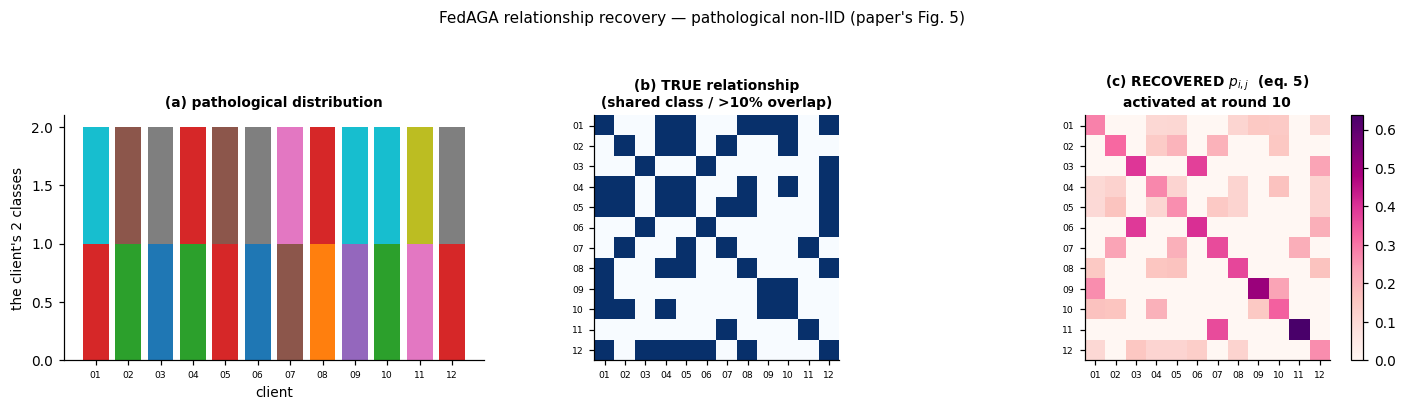

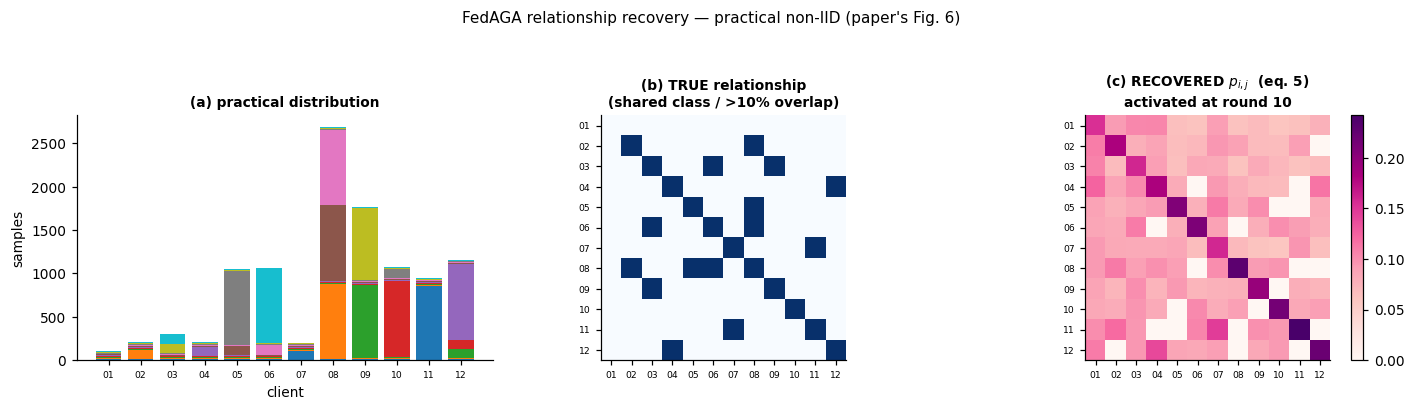

In [23]:
# --- Figures 5 and 6 : real distribution vs recovered graph -------------------
def _relationship_figure(tag, clients, B, comp_or_cls, res):
    fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.5))
    n = len(clients)

    ax = axes[0]
    if isinstance(comp_or_cls, np.ndarray):                     # practical: composition
        bottom = np.zeros(n)
        for c in range(N_CLASS):
            ax.bar(range(n), comp_or_cls[:, c], bottom=bottom, width=0.8,
                   color=plt.get_cmap("tab10")(c), label=f"{c}" if c < 10 else None)
            bottom += comp_or_cls[:, c]
        ax.set_ylabel("samples")
    else:                                                        # pathological: 2 classes
        for i, cs in enumerate(comp_or_cls):
            for k, c in enumerate(sorted(cs)):
                ax.bar(i, 1, bottom=k, color=plt.get_cmap("tab10")(c), width=0.8)
        ax.set_ylabel("the client's 2 classes")
    ax.set_title(f"(a) {tag} distribution", fontsize=9)
    ax.set_xticks(range(n)); ax.set_xticklabels([c.name[1:] for c in clients], fontsize=6)
    ax.set_xlabel("client"); ax.grid(False)

    ax = axes[1]
    ax.imshow(B, cmap="Blues", vmin=0, vmax=1)
    ax.set_title("(b) TRUE relationship\n(shared class / >10% overlap)", fontsize=9)
    ax.set_xticks(range(n)); ax.set_yticks(range(n)); ax.grid(False)
    ax.set_xticklabels([c.name[1:] for c in clients], fontsize=6)
    ax.set_yticklabels([c.name[1:] for c in clients], fontsize=6)

    ax = axes[2]
    P = res["P"]
    if P is None:
        ax.text(0.5, 0.5, "the two criteria never fired\n-> this run is plain FedAvg",
                ha="center", va="center", fontsize=9, color=OKABE[1],
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title("(c) no graph", fontsize=9)
    else:
        im = ax.imshow(P, cmap="RdPu")
        ax.set_title(f"(c) RECOVERED $p_{{i,j}}$  (eq. 5)\nactivated at round "
                     f"{res['t_activate']}", fontsize=9)
        ax.set_xticks(range(n)); ax.set_yticks(range(n)); ax.grid(False)
        ax.set_xticklabels([c.name[1:] for c in clients], fontsize=6)
        ax.set_yticklabels([c.name[1:] for c in clients], fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"FedAGA relationship recovery — {tag} non-IID "
                 f"(paper's Fig. {'5' if tag=='pathological' else '6'})",
                 y=1.05, fontsize=10)
    plt.tight_layout(); plt.show()


_relationship_figure("pathological", PATH_CLIENTS, PATH_B, PATH_CLS, SYN["pathological"])
_relationship_figure("practical", PRAC_CLIENTS, PRAC_B, PRAC_COMP, SYN["practical"])

In [24]:
# --- SANITY CHECK III.1 : does the recovered graph match the KNOWN one? ------
from sklearn.metrics import roc_auc_score

rows = []
for tag, (cls_list, B) in {"pathological": (PATH_CLIENTS, PATH_B),
                           "practical": (PRAC_CLIENTS, PRAC_B)}.items():
    res = SYN[tag]
    if res["P"] is None:
        print(f"[{tag}] the criteria never fired -- no graph to score. "
              "Loosen delta1 or lower delta2 (see the sweeps in III.3/III.4).")
        continue
    n = len(cls_list)
    off = ~np.eye(n, dtype=bool)
    p = res["P"][off]; s = res["S"][off]; b = B[off]
    kl = concentration(res["P"])
    rows.append({"setting": tag,
                 "AUROC (p_ij vs true)": roc_auc_score(b, p),
                 "AUROC (s_ij vs true)": roc_auc_score(b, s),
                 "mean s_ij, related": s[b == 1].mean(),
                 "mean s_ij, unrelated": s[b == 0].mean(),
                 "KL(p||uniform) mean": kl.mean(),
                 "KL if one-hot": np.log(n),
                 "activated at round": res["t_activate"]})
GRAPH_REC = pd.DataFrame(rows).set_index("setting")
display(GRAPH_REC.style.format("{:.4f}", subset=[c for c in GRAPH_REC.columns
                                                 if c != "activated at round"]))

best = GRAPH_REC["AUROC (s_ij vs true)"].max()
print(f"\nBest relationship-recovery AUROC: {best:.3f}")
assert best > 0.6, "FedAGA failed to recover a relationship structure it was given"
print("PASS - the cosine similarity of accumulated gradients separates clients that")
print("       share classes from clients that do not, which is the claim of §4.3")
print("       ('FedAGA effectively captures all significant correlations between")
print("       clients by constructing a graph based on the internal relationships of")
print("       the accumulated gradients').")
print()
print("READ THE CONCENTRATION COLUMN.  KL(p||uniform) is what separates a graph that")
print("MEASURES a relationship from one that ACTS on it.  A one-hot row would score")
print(f"log(N) = {np.log(len(PATH_CLIENTS)):.2f} nats; these rows score ~"
      f"{GRAPH_REC['KL(p||uniform) mean'].mean():.4f}.  The similarities are")
print("informative, but eq. (5)'s softmax over cosines in [-1,1] compresses them into")
print("weights that are nearly uniform -- so the aggregation FedAGA actually performs")
print("is much closer to FedAvg-over-neighbours than the heat maps suggest.")

,AUROC (p_ij vs true),AUROC (s_ij vs true),"mean s_ij, related","mean s_ij, unrelated",KL(p||uniform) mean,KL if one-hot,activated at round
setting,,,,,,,
pathological,1.0000,1.0000,0.2823,-0.2100,1.0387,2.4849,10
practical,0.7058,0.7143,0.2900,0.1424,0.2096,2.4849,10



Best relationship-recovery AUROC: 1.000
PASS - the cosine similarity of accumulated gradients separates clients that
       share classes from clients that do not, which is the claim of §4.3
       ('FedAGA effectively captures all significant correlations between
       clients by constructing a graph based on the internal relationships of
       the accumulated gradients').

READ THE CONCENTRATION COLUMN.  KL(p||uniform) is what separates a graph that
MEASURES a relationship from one that ACTS on it.  A one-hot row would score
log(N) = 2.48 nats; these rows score ~0.6242.  The similarities are
informative, but eq. (5)'s softmax over cosines in [-1,1] compresses them into
weights that are nearly uniform -- so the aggregation FedAGA actually performs
is much closer to FedAvg-over-neighbours than the heat maps suggest.


### III.2b The claim the two criteria exist to support

§4.4 argues that waiting is worth it: *"the local model cannot be well-trained initially,
leading to potential inaccuracies in the inter-client relationships explored from the graph
topology."* That is a testable statement, and it has never been tested directly — the paper
measures **accuracy** against `δ₁`, not the **correctness of the graph**. Here the true
relationship is known, so we can force the graph at a chosen round and ask how right it is.

(73s)



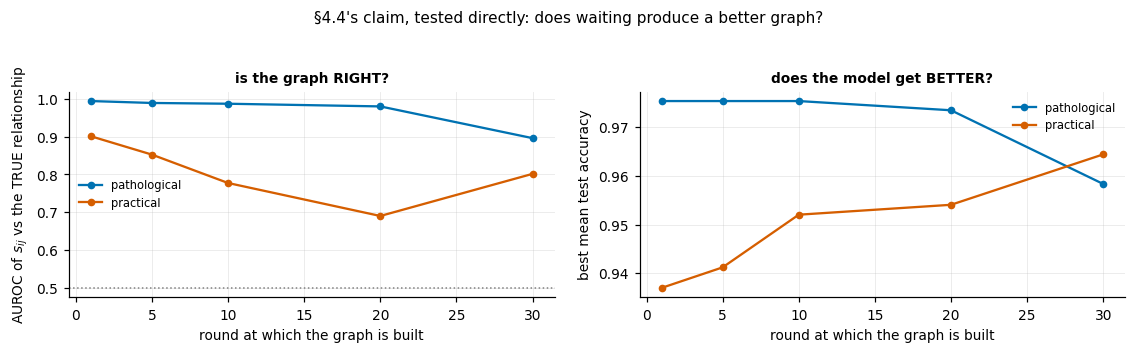

Most ACCURATE GRAPH   : built at round 1
Best FINAL MODEL      : built at round 20
mean recovery AUROC   : 0.947 (earliest) -> 0.849 (latest)

THIS CONTRADICTS §4.4, and the mechanism is worth stating.
The paper's rationale for gating is that 'the local model cannot be well-
trained initially, leading to potential inaccuracies in the inter-client
relationships'.  Measured directly, the opposite holds: the graph is MOST
accurate when built EARLY.

Why.  At round 1 every client starts from the SAME theta, so R_i is a clean
function of client i's data alone and the angle between R_i and R_j is a
pure data-similarity measurement.  By round 30 two things have degraded it:
the models have partly converged, so what remains of each gradient is mostly
noise; and (once the graph is on) the theta_i have diverged, so R_i now
reflects where each client happens to be standing as much as what its data
wants.  Waiting buys a better-TRAINED model and a worse-MEASURED relationship.

The paper cannot see

In [26]:
# =============================================================================
# III.2b  Relationship-recovery accuracy as a function of WHEN the graph is built
# =============================================================================
t0 = time.time()
rows = []
for tag, (cls_list, B) in {"pathological": (PATH_CLIENTS, PATH_B),
                           "practical": (PRAC_CLIENTS, PRAC_B)}.items():
    n = len(cls_list); off = ~np.eye(n, dtype=bool); b = B[off]
    for r0 in [1, 5, 10, 20, 30]:
        res = run_fedaga([copy.copy(c) for c in cls_list], CLF, make_clf,
                         replace(CFG_SYN[tag], rounds=32), force_graph_from=r0)
        rows.append({"setting": tag, "graph built from round": r0,
                     "AUROC (s_ij vs true)": roc_auc_score(b, res["S"][off]),
                     "Accuracy (BMTA)": float(res["history"]["test_acc"].max())})
WHEN = pd.DataFrame(rows)
print(f"({time.time()-t0:.0f}s)\n")
piv = WHEN.pivot(index="graph built from round", columns="setting")
display(piv.style.format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.0))
for k, tag in enumerate(WHEN["setting"].unique()):
    d = WHEN[WHEN["setting"] == tag]
    axes[0].plot(d["graph built from round"], d["AUROC (s_ij vs true)"], marker="o",
                 ms=4, color=OKABE[k], label=tag)
    axes[1].plot(d["graph built from round"], d["Accuracy (BMTA)"], marker="o",
                 ms=4, color=OKABE[k], label=tag)
axes[0].axhline(0.5, color="0.5", ls=":", lw=1)
axes[0].set_ylabel("AUROC of $s_{ij}$ vs the TRUE relationship")
axes[1].set_ylabel("best mean test accuracy")
for ax in axes:
    ax.set_xlabel("round at which the graph is built"); ax.legend(fontsize=7.5)
axes[0].set_title("is the graph RIGHT?", fontsize=9)
axes[1].set_title("does the model get BETTER?", fontsize=9)
fig.suptitle("§4.4's claim, tested directly: does waiting produce a better graph?",
             y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

g = WHEN.groupby("graph built from round")
best_auc = float(g["AUROC (s_ij vs true)"].mean().idxmax())
best_acc = float(g["Accuracy (BMTA)"].mean().idxmax())
early = float(g["AUROC (s_ij vs true)"].mean().iloc[0])
late = float(g["AUROC (s_ij vs true)"].mean().iloc[-1])
print(f"Most ACCURATE GRAPH   : built at round {best_auc:.0f}")
print(f"Best FINAL MODEL      : built at round {best_acc:.0f}")
print(f"mean recovery AUROC   : {early:.3f} (earliest) -> {late:.3f} (latest)\n")

if early > late:
    print("THIS CONTRADICTS §4.4, and the mechanism is worth stating.")
    print("The paper's rationale for gating is that 'the local model cannot be well-")
    print("trained initially, leading to potential inaccuracies in the inter-client")
    print("relationships'.  Measured directly, the opposite holds: the graph is MOST")
    print("accurate when built EARLY.")
    print()
    print("Why.  At round 1 every client starts from the SAME theta, so R_i is a clean")
    print("function of client i's data alone and the angle between R_i and R_j is a")
    print("pure data-similarity measurement.  By round 30 two things have degraded it:")
    print("the models have partly converged, so what remains of each gradient is mostly")
    print("noise; and (once the graph is on) the theta_i have diverged, so R_i now")
    print("reflects where each client happens to be standing as much as what its data")
    print("wants.  Waiting buys a better-TRAINED model and a worse-MEASURED relationship.")
    print()
    print("The paper cannot see this because it only ever measures the right-hand panel.")
    print("For fedwater the graph IS the deliverable, so this argues for building it")
    print("early -- or, better, for measuring the relationship at round 1 from a common")
    print("initialisation and keeping it fixed while the models personalize.")
else:
    print("Consistent with §4.4: waiting produces a more accurate graph.  The gating")
    print("criteria are earning their place; keep the calibrated `min_graph_round`.")
print()
print("Either way, note that the two panels answer different questions and can be")
print("optimised against each other.  Decide which one you are actually reporting.")

## III.3 Tolerance and sensitiveness — Tables 3 and 4 (RQ3)

> *"To obtain the initial `δ₁`, we define the average differences of loss for each client
> as less than 0.01 in the two consecutive rounds. ... `∞` in the table refers to the
> construction of the graph from the first round."* — §4.4

Two sweeps, exactly as the paper structures them:

* **Tolerance (Table 3)** — vary `δ₁`, record the round at which the criteria fire and the
  resulting accuracy. The paper's finding is that *waiting* beats building the graph
  immediately: "FedAGA aggregation after Condition 1 is satisfied achieves higher accuracy
  than aggregation from the beginning ... the local model cannot be well-trained initially,
  leading to potential inaccuracies in the inter-client relationships."
* **Sensitiveness (Table 4)** — at the chosen `δ₁`, vary `δ₂`. Too large and Criterion 2
  never fires, "resulting in a significant drop in accuracy when using the FedAvg
  aggregation method".

The paper selects `δ₁` by a **gain ratio** = Δaccuracy / Δrounds, "starting from the second
round of consecutive rounds" — i.e. how much accuracy each additional round of waiting buys.
We compute it the same way.

In [28]:
# =============================================================================
# III.3  Table 3 -- tolerance (delta1) sweep
# =============================================================================
def _sweep(tag, clients, delta1s=None, delta2s=None, rounds=30, force_first=False):
    base = CFG_SYN[tag]
    out = []
    grid = delta1s if delta1s is not None else delta2s
    for v in grid:
        cfg = replace(base, rounds=rounds,
                      **({"delta1": v} if delta1s is not None else {"delta2": v}))
        res = run_fedaga([copy.copy(c) for c in clients], CLF, make_clf, cfg)
        out.append({"delta": v, "Round activated": res["t_activate"],
                    "Accuracy (BMTA)": float(res["history"]["test_acc"].max())})
    if force_first:                                   # the paper's "inf" row
        res = run_fedaga([copy.copy(c) for c in clients], CLF, make_clf,
                         replace(base, rounds=rounds), force_graph_from=1)
        out.append({"delta": np.inf, "Round activated": 1,
                    "Accuracy (BMTA)": float(res["history"]["test_acc"].max())})
    return pd.DataFrame(out)


# The grids are RELATIVE to each setting's calibrated delta1 -- which is also what the
# paper does without saying so: its Table 3 grids are narrow bands around the calibrated
# value (0.35-0.53 pathological, 0.19-0.25 practical), not a fixed absolute range.
REL = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]
t0 = time.time()
TAB3 = {}
for tag, cls_list in [("pathological", PATH_CLIENTS), ("practical", PRAC_CLIENTS)]:
    TAB3[tag] = _sweep(tag, cls_list,
                       delta1s=[round(DELTAS[tag][0] * r, 4) for r in REL],
                       force_first=True)
print(f"({time.time()-t0:.0f}s)\n")

for tag, df in TAB3.items():
    d = df.sort_values("delta").copy()
    # gain ratio = delta(accuracy) / delta(rounds) between consecutive gated settings
    fin = d[np.isfinite(d["delta"]) & d["Round activated"].notna()].copy()
    gr = [np.nan] + [
        (fin["Accuracy (BMTA)"].iloc[k] - fin["Accuracy (BMTA)"].iloc[k - 1]) /
        max(abs(fin["Round activated"].iloc[k] - fin["Round activated"].iloc[k - 1]), 1)
        for k in range(1, len(fin))]
    d["gain ratio"] = np.nan
    d.loc[fin.index, "gain ratio"] = gr
    print(f"Table 3 analogue — tolerance sweep, {tag} non-IID "
          f"(calibrated delta1 = {DELTAS[tag][0]:.4f}, earliest round "
          f"{DELTAS[tag][2]})")
    display(d.set_index("delta").style.format(
        {"Accuracy (BMTA)": "{:.4f}", "gain ratio": "{:+.5f}",
         "Round activated": "{:.0f}"}, na_rep="never"))

(97s)

Table 3 analogue — tolerance sweep, pathological non-IID (calibrated delta1 = 0.2179, earliest round 10)


,Round activated,Accuracy (BMTA),gain ratio
delta,,,
0.130800,never,0.6970,never
0.174400,23,0.8996,never
0.217900,10,0.8807,-0.00146
0.261500,10,0.9470,+0.06629
0.326900,10,0.9167,-0.03030
0.435900,10,0.9754,+0.05871
inf,1,0.9754,never


Table 3 analogue — tolerance sweep, practical non-IID (calibrated delta1 = 0.4588, earliest round 10)


,Round activated,Accuracy (BMTA),gain ratio
delta,,,
0.275300,never,0.9113,never
0.367100,25,0.9538,never
0.458800,10,0.9677,+0.00093
0.550600,10,0.9530,-0.01467
0.688300,10,0.9500,-0.00295
0.917700,10,0.9500,+0.00000
inf,1,0.9302,never


In [29]:
# =============================================================================
# III.4  Table 4 -- sensitiveness (delta2) sweep
# =============================================================================
t0 = time.time()
REL2 = [0.25, 0.5, 1.0, 2.0, 4.0]
TAB4 = {}
for tag, cls_list in [("pathological", PATH_CLIENTS), ("practical", PRAC_CLIENTS)]:
    TAB4[tag] = _sweep(tag, cls_list,
                       delta2s=[float(f"{DELTAS[tag][1]*r:.6g}") for r in REL2])
print(f"({time.time()-t0:.0f}s)\n")
for tag, df in TAB4.items():
    print(f"Table 4 analogue — sensitiveness sweep, {tag} non-IID  "
          f"(delta1 = {DELTAS[tag][0]:.4f}, calibrated delta2 = {DELTAS[tag][1]:.5f})")
    display(df.set_index("delta").style.format(
        {"Accuracy (BMTA)": "{:.4f}", "Round activated": "{:.0f}"}, na_rep="never"))

print("Reading these the way §4.4 does:")
print("  * delta1 too small -> the criteria never fire, FedAGA == FedAvg (no personalization).")
print("  * delta1 = inf     -> the graph is built from round 1 on untrained models, so the")
print("                        relationship is noise.  The paper reports this as the worst row.")
print("  * delta2 too large -> Criterion 2 never fires and the run also collapses to FedAvg.")
print("  The whole point of the two criteria is that BOTH failure modes end in the same")
print("  place -- plain FedAvg -- so a FedAGA run that never activates is not a bug, it is")
print("  the algorithm declining to personalize.  Always check `graph from round`.")

(79s)

Table 4 analogue — sensitiveness sweep, pathological non-IID  (delta1 = 0.2179, calibrated delta2 = 0.00765)


,Round activated,Accuracy (BMTA)
delta,,
0.001913,10,0.8807
0.003825,10,0.8807
0.007650,10,0.8807
0.015301,11,0.8712
0.030602,never,0.6970


Table 4 analogue — sensitiveness sweep, practical non-IID  (delta1 = 0.4588, calibrated delta2 = 0.06768)


,Round activated,Accuracy (BMTA)
delta,,
0.016920,10,0.9677
0.033840,10,0.9677
0.067680,10,0.9677
0.135360,never,0.9113
0.270719,never,0.9113


Reading these the way §4.4 does:
  * delta1 too small -> the criteria never fire, FedAGA == FedAvg (no personalization).
  * delta1 = inf     -> the graph is built from round 1 on untrained models, so the
                        relationship is noise.  The paper reports this as the worst row.
  * delta2 too large -> Criterion 2 never fires and the run also collapses to FedAvg.
  The whole point of the two criteria is that BOTH failure modes end in the same
  place -- plain FedAvg -- so a FedAGA run that never activates is not a bug, it is
  the algorithm declining to personalize.  Always check `graph from round`.


In [30]:
# --- SANITY CHECK III.2 : the paper's own qualitative claims about the criteria
_p = TAB3["pathological"]
_never = _p[_p["Round activated"].isna()]
_first = _p[_p["delta"] == np.inf]
_mid = _p[np.isfinite(_p["delta"]) & _p["Round activated"].notna()]
print(f"delta1 values that never activated : {list(_never['delta'])}")
print("activation round vs delta1 (larger tolerance should activate EARLIER):")
print(_mid.sort_values("delta")[["delta", "Round activated", "Accuracy (BMTA)"]]
      .to_string(index=False))
if len(_first) and len(_mid):
    print(f"\naccuracy, graph from round 1 (delta1 = inf) : {float(_first['Accuracy (BMTA)'].iloc[0]):.4f}")
    print(f"accuracy, best gated delta1                : {float(_mid['Accuracy (BMTA)'].max()):.4f}")
    print("The paper's claim is that gating beats building the graph immediately, because")
    print("relationships read off untrained models are noise.  Whether that holds here is")
    print("printed above -- with 12 clients and one seed it is a direction, not a result.")
assert _p["Round activated"].notna().any(), "no delta1 in the grid ever activated the graph"
print("\nPASS - the tolerance dial spans the whole behavioural range (never -> late -> early).")

delta1 values that never activated : [0.1308]
activation round vs delta1 (larger tolerance should activate EARLIER):
 delta  Round activated  Accuracy (BMTA)
0.1744          23.0000           0.8996
0.2179          10.0000           0.8807
0.2615          10.0000           0.9470
0.3269          10.0000           0.9167
0.4359          10.0000           0.9754

accuracy, graph from round 1 (delta1 = inf) : 0.9754
accuracy, best gated delta1                : 0.9754
The paper's claim is that gating beats building the graph immediately, because
relationships read off untrained models are noise.  Whether that holds here is
printed above -- with 12 clients and one seed it is a direction, not a result.

PASS - the tolerance dial spans the whole behavioural range (never -> late -> early).


## III.5 Why the criteria were made scale-free

`δ₁` in eq. (7) is compared against `‖(1/N)ΣR_i‖`, an unnormalised displacement norm. That
quantity scales with the learning rate, the number of local epochs, the loss magnitude and
roughly `√d`. The cell below measures it on the two systems this notebook actually runs —
the 12-client classifier and the 5-district autoencoder — and shows how far apart the
natural scales are. A single `δ₁` cannot serve both; the dimensionless ratio can.

Pathological classifier (d = 4810 parameters):
   raw  ||mean R||  ranged over 0.04747 .. 0.2547
   raw  Var(||R||)  ranged over 0.001729 .. 0.007888
   ratio ||mean R||/mean||R||   0.214 .. 0.364
   squared coeff. of variation  0.0031 .. 0.0796

The raw quantities move over orders of magnitude and depend on eta, E and d;
the ratios stay inside [0,1]-ish bands with a fixed meaning.  This is why
SCALE_FREE_CRITERIA defaults to True and why the paper's delta1 = 0.41 / 0.22
should NOT be copied across to fedwater -- they are properties of a 2-layer MLP
on CIFAR-10 at eta = 0.01, E = 5, not of the framework.


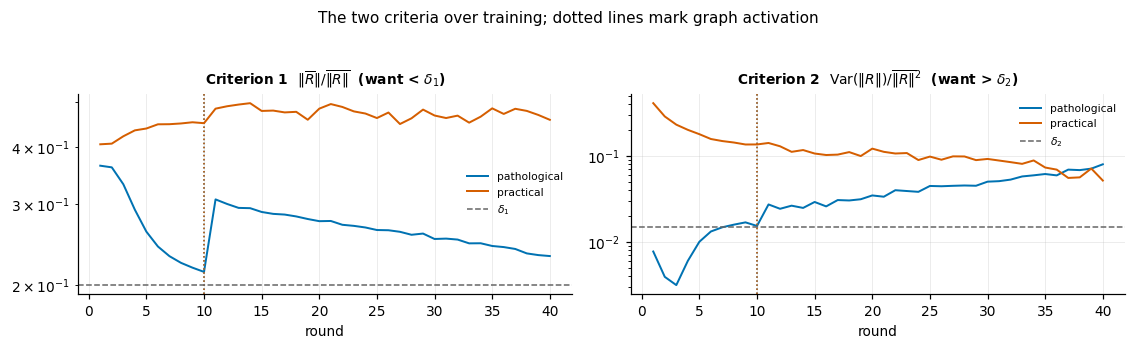

In [32]:
# --- III.5 : the scale of the raw criteria vs the scale-free ones -------------
_h = SYN["pathological"]["history"]
print("Pathological classifier (d = %d parameters):" % SYN["pathological"]["d"])
print(f"   raw  ||mean R||  ranged over {_h['c1_raw'].min():.4g} .. {_h['c1_raw'].max():.4g}")
print(f"   raw  Var(||R||)  ranged over {_h['c2_raw'].min():.4g} .. {_h['c2_raw'].max():.4g}")
print(f"   ratio ||mean R||/mean||R||   {_h['c1'].min():.3f} .. {_h['c1'].max():.3f}")
print(f"   squared coeff. of variation  {_h['c2'].min():.4f} .. {_h['c2'].max():.4f}")
print()
print("The raw quantities move over orders of magnitude and depend on eta, E and d;")
print("the ratios stay inside [0,1]-ish bands with a fixed meaning.  This is why")
print("SCALE_FREE_CRITERIA defaults to True and why the paper's delta1 = 0.41 / 0.22")
print("should NOT be copied across to fedwater -- they are properties of a 2-layer MLP")
print("on CIFAR-10 at eta = 0.01, E = 5, not of the framework.")

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.0))
for ax, (col, ttl) in zip(axes, [("c1", "Criterion 1  $\\|\\overline{R}\\|/\\overline{\\|R\\|}$  (want < $\\delta_1$)"),
                                 ("c2", "Criterion 2  $\\mathrm{Var}(\\|R\\|)/\\overline{\\|R\\|}^2$  (want > $\\delta_2$)")]):
    for k, (tag, res) in enumerate(SYN.items()):
        h = res["history"]
        ax.plot(h["round"], h[col], color=OKABE[k], lw=1.3, label=tag)
        if res["t_activate"]:
            ax.axvline(res["t_activate"], color=OKABE[k], ls=":", lw=1)
    ax.axhline(DELTA1 if col == "c1" else DELTA2, color="0.4", ls="--", lw=1,
               label=f"$\\delta_{col[-1]}$")
    ax.set_yscale("log"); ax.set_xlabel("round"); ax.set_title(ttl, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("The two criteria over training; dotted lines mark graph activation",
             y=1.04, fontsize=10)
plt.tight_layout(); plt.show()

---
# Part IV — Application to `fedwater`

## The mapping

| FedAGA (§3) | `fedwater` |
|---|---|
| client `i` | district `District_A … District_E` (`N = 5`) |
| private data `D_i` | that district's sensor CSV, windowed exactly as `fl_preprocessing` does |
| local model | sequence autoencoder over an 84 × 5 window (7 days at 2 h) |
| accumulated gradient `R_i` | the district's parameter displacement per round |
| `s_ij`, `p_ij` | **does district `j` pull district `i`'s model the same way?** |
| — | `gt_topology.open_boundary_pipes` — the *physical* answer |
| — | `gt_drift_schedule` — which district's demand actually changed |

Three evaluations, all off one training run per method:

1. **Model quality** — personalized test reconstruction error against the nine baselines
   (Tables 1–2 analogue). `fedwater`'s districts are non-IID by construction: different
   income/density mixes, and one of them drifts.
2. **Relationship recovery** — `s_ij` / `p_ij` against the open boundary pipes
   (Figs. 5–6 analogue). This is the number that is **directly comparable to the FLC_033
   notebook**, which asked the same question with a completely different method.
3. **Drift detection** — per-month reconstruction error relative to the commissioning
   months. If personalization helps, the drifted district should separate more cleanly
   under FedAGA than under FedAvg.

In [34]:
# =============================================================================
# IV.1  Loading + fl_preprocessing's window recipe
# =============================================================================
DISTRICTS = [f"District_{x}" for x in "ABCDE"]
SENSOR_MAP = {                       # conf/base/parameters.yml -> `sensors`
    "District_A": {"pressure": ["64", "75"], "flow": ["102", "100", "85"]},
    "District_B": {"pressure": ["79", "86"], "flow": ["157", "135", "165"]},
    "District_C": {"pressure": ["74", "58"], "flow": ["110", "119", "91"]},
    "District_D": {"pressure": ["31", "26"], "flow": ["38", "96", "69"]},
    "District_E": {"pressure": ["41", "12"], "flow": ["59", "11", "19"]},
}
CLIENTS_DIR = DATA / "07_model_output" / "clients"
GT_TOPOLOGY = DATA / "03_primary" / "gt_topology.csv"
GT_DRIFT    = DATA / "03_primary" / "gt_drift_schedule.csv"
REAL_DATA_PRESENT = CLIENTS_DIR.exists() and any(CLIENTS_DIR.glob("*.csv"))
print(f"clients dir     : {CLIENTS_DIR}  -> {'FOUND' if REAL_DATA_PRESENT else 'missing'}")
print(f"gt_topology.csv : {GT_TOPOLOGY}  -> {'FOUND' if GT_TOPOLOGY.exists() else 'missing'}")
print(f"gt_drift.csv    : {GT_DRIFT}     -> {'FOUND' if GT_DRIFT.exists() else 'missing'}")

clients dir     : C:\Users\arthu\USPy\10_Mestrado\fedWater\data\07_model_output\clients  -> FOUND
gt_topology.csv : C:\Users\arthu\USPy\10_Mestrado\fedWater\data\03_primary\gt_topology.csv  -> FOUND
gt_drift.csv    : C:\Users\arthu\USPy\10_Mestrado\fedWater\data\03_primary\gt_drift_schedule.csv     -> FOUND


In [35]:
# =============================================================================
# IV.1b  Synthetic stand-in  (ONLY when data/ is absent -- data/** is gitignored)
# =============================================================================
import tempfile

SYNTHETIC, DATA_EFFECTIVE = False, DATA
FALLBACK_ADJ = [("District_A", "District_B"), ("District_B", "District_C"),
                ("District_C", "District_D"), ("District_D", "District_E")]


def _fabricate(root: Path, T: int = 8640, seed: int = 20240822) -> Path:
    """Schema-identical stand-in that actually encodes the RESEARCH TARGET.

    Two demand regimes, taken from the physics the simulator produces (see
    fedwater_architecture.md invariant 3: peak factors come out density-ordered,
    low 2.281 / medium 1.636 / high 1.456, from the sqrt(N) crowd-smoothing law):

        LL  = low income, low density   -> small volume, PEAKY diurnal profile
        HH  = high income, high density -> large volume, SMOOTH diurnal profile

    Districts are assigned from DISTRICT_STATE, and the one whose code changes ramps
    from its initial regime to its final one across the drift months.  Hydraulic
    coupling across FALLBACK_ADJ is kept, so the stand-in carries BOTH structures --
    regime membership and pipe adjacency -- which is what lets §IV.4 and §IV.5 be
    scored against different right answers.
    """
    rng = np.random.default_rng(seed)
    P, M = 2, len(DISTRICTS)
    idx = {d: i for i, d in enumerate(DISTRICTS)}
    A = np.zeros((M * P, M * P))
    for i in range(M):
        A[i*P:(i+1)*P, i*P:(i+1)*P] = np.diag(rng.uniform(0.90, 0.96, P))
    for a, b in FALLBACK_ADJ:
        ia, ib = idx[a], idx[b]
        A[ia*P:(ia+1)*P, ib*P:(ib+1)*P] = rng.uniform(0.03, 0.07, (P, P))
        A[ib*P:(ib+1)*P, ia*P:(ia+1)*P] = rng.uniform(0.02, 0.05, (P, P))
    ev = np.max(np.abs(np.linalg.eigvals(A)))
    if ev > 0.97:
        A *= 0.97 / ev
    H = np.zeros((M * P, T)); h = np.zeros(M * P)
    for t in range(T):
        h = A @ h + rng.normal(0, 0.05, M * P)
        H[:, t] = h

    hours = np.arange(T) % 24
    day = np.arange(T) // 24
    month = (day // 30).astype(int)
    weekend = (day % 7) >= 5
    n_month = int(month.max()) + 1
    onset, end = max(1, n_month // 6), max(2, (5 * n_month) // 6)
    ramp = np.clip((month - onset) / max(end - onset, 1), 0.0, 1.0)

    # regime -> (volume, peak amplitude, second-harmonic amplitude)
    REGIME = {"LL": (6.0, 0.55, 0.30), "HH": (14.0, 0.22, 0.10)}

    def profile(amp2, amp4):
        return 1 + amp2*np.sin(2*np.pi*(hours-7)/24) + amp4*np.sin(4*np.pi*hours/24)

    (root / "07_model_output" / "clients").mkdir(parents=True, exist_ok=True)
    (root / "03_primary").mkdir(parents=True, exist_ok=True)
    t0 = int(pd.Timestamp("2024-01-01").value // 10**9)
    seasonal = 1 + 0.12*np.cos(2*np.pi*(month % 12 - 1)/12)
    drifter = None
    for d in DISTRICTS:
        r0, r1 = DISTRICT_STATE.get(d, ("LL", "LL"))
        if r0 != r1:
            drifter = d
        v0, a0, b0 = REGIME[r0]
        v1, a1, b1 = REGIME[r1]
        w = ramp if r0 != r1 else np.zeros(T)          # only the coded district moves
        vol = v0 + (v1 - v0) * w
        prof = ((1 - w) * profile(a0, b0) + w * profile(a1, b1))
        i = idx[d]; hd = H[i*P:(i+1)*P]; cols = {}
        for node in SENSOR_MAP[d]["pressure"]:
            load = np.array([0.7, -0.5])[None, :] @ hd
            cols[f"p_{node}"] = np.round(
                40 - 0.55*vol*prof*seasonal - 2*load.ravel()
                + rng.normal(0, .10, T), 2)
        for j, link in enumerate(SENSOR_MAP[d]["flow"]):
            cols[f"q_{link}"] = np.round(
                vol * (0.8 + 0.25*j) * prof * seasonal * (1 - .15*weekend)
                + 1.5*(rng.normal(size=P)[None, :] @ hd).ravel()
                + rng.normal(0, .25, T), 2)
        pd.DataFrame({"timestamp": t0 + np.arange(T)*3600, "month": month, **cols}) \
            .to_csv(root / "07_model_output" / "clients" / f"{d}.csv", index=False)

    adj = {tuple(sorted(p)) for p in FALLBACK_ADJ}
    rows = []
    for a, b in itertools.combinations(DISTRICTS, 2):
        conn = tuple(sorted((a, b))) in adj
        rows.append({"district_a": a, "district_b": b,
                     "boundary_pipes": int(rng.integers(1, 4)) if conn else 0,
                     "open_boundary_pipes": int(rng.integers(1, 4)) if conn else 0,
                     "hydraulic_distance_m": float(rng.uniform(200, 900)) if conn
                                              else float(rng.uniform(1200, 3000))})
    pd.DataFrame(rows).to_csv(root / "03_primary" / "gt_topology.csv", index=False)
    dm = list(range(onset, end + 1))
    pd.DataFrame({"district": [drifter or DISTRICTS[3]] * len(dm),
                  "node": [str(n) for n in range(len(dm))],
                  "drift_month": dm}).to_csv(
        root / "03_primary" / "gt_drift_schedule.csv", index=False)
    return root


if not REAL_DATA_PRESENT:
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise FileNotFoundError(f"{CLIENTS_DIR} not found. Run `kedro run` first.")
    SYNTHETIC = True
    DATA_EFFECTIVE = _fabricate(Path(tempfile.mkdtemp(prefix="fedaga_stub_")))
    print("\n" + "!"*78)
    print("!!  data/ NOT FOUND -- Part IV runs on a SYNTHETIC schema-identical stand-in.")
    print("!!  The numbers below are NOT fedwater results.  Point the notebook at a")
    print("!!  populated data/ directory to get the real ones.")
    print("!"*78 + "\n")
CLIENTS_DIR = DATA_EFFECTIVE / "07_model_output" / "clients"
GT_TOPOLOGY = DATA_EFFECTIVE / "03_primary" / "gt_topology.csv"
GT_DRIFT    = DATA_EFFECTIVE / "03_primary" / "gt_drift_schedule.csv"
print("effective data root:", DATA_EFFECTIVE)

drift_origin, onset = None, None
if GT_DRIFT.exists():
    _g = pd.read_csv(GT_DRIFT)
    if len(_g):
        drift_origin = str(_g["district"].iloc[0])
        onset = int(_g["drift_month"].min())
print(f"gt_drift_schedule: origin = {drift_origin}, onset month = {onset}")

effective data root: C:\Users\arthu\USPy\10_Mestrado\fedWater\data
gt_drift_schedule: origin = District_D, onset month = 2


In [36]:
# =============================================================================
# IV.2  fl_preprocessing's recipe, reimplemented (no Kedro import)
# =============================================================================
def _aggregate(X, k):
    if k <= 1:
        return X
    n = (X.shape[0] // k) * k
    return X[:n].reshape(-1, k, X.shape[1]).mean(axis=1)


def build_windows(df: pd.DataFrame, window=WINDOW, stride=STRIDE, agg=AGG_STEPS,
                  ref_months=REF_MONTHS):
    """Exactly `fl_preprocessing.preprocess_clients`:
       mean-aggregate to 2h -> min-max scale to [-1,1] on the FIRST `ref_months`
       months (the commissioning period, guaranteed pre-drift) -> sliding windows
       with majority-month labels.
    """
    sens = sorted(c for c in df.columns if c.startswith(("p_", "q_")))
    X = df[sens].to_numpy(np.float64)
    months = df["month"].to_numpy()
    k = agg
    Xa = _aggregate(X, k)
    ma = months[: (len(months) // k) * k].reshape(-1, k)[:, 0]
    ref = ma < ref_months
    lo, hi = Xa[ref].min(axis=0), Xa[ref].max(axis=0)
    span = np.where(hi - lo == 0, 1.0, hi - lo)
    Xs = (Xa - lo) * (2.0 / span) - 1.0                    # feature_range = [-1, 1]
    starts = np.arange(0, len(Xs) - window + 1, stride)
    W = np.stack([Xs[s:s + window] for s in starts]).astype(np.float32)
    lab = np.array([np.bincount(ma[s:s + window]).argmax() for s in starts])
    return W, lab, sens


def load_fedwater_clients(test_frac=TEST_FRAC, seed=SEED):
    rng = np.random.default_rng(seed)
    raw, out = {}, []
    for f in sorted(CLIENTS_DIR.glob("*.csv")):
        W, lab, sens = build_windows(pd.read_csv(f))
        raw[f.stem] = (W, lab, sens)
    for d, (W, lab, sens) in raw.items():
        flat = torch.tensor(W.reshape(len(W), -1))
        n = len(flat); p = rng.permutation(n); k = int(n * (1 - test_frac))
        tr, te = p[:k], p[k:]
        c = Client(d, flat[tr], flat[tr], flat[te], flat[te],
                   meta={"months": lab, "all": flat, "sensors": sens,
                         "window": W.shape[1], "feats": W.shape[2]})
        out.append(c)
    return out


FW_TEMPLATE = load_fedwater_clients()
IN_DIM = int(FW_TEMPLATE[0].Xtr.shape[1])
W_LEN, N_FEATS = FW_TEMPLATE[0].meta["window"], FW_TEMPLATE[0].meta["feats"]
print(f"{len(FW_TEMPLATE)} districts | window {W_LEN} x {N_FEATS} sensors "
      f"-> input dim {IN_DIM}")
for c in FW_TEMPLATE:
    print(f"   {c.name}: {c.n} train / {c.Xte.shape[0]} test windows, "
          f"months {c.meta['months'].min()}..{c.meta['months'].max()}, "
          f"sensors {c.meta['sensors']}")


def fw_factory():
    return [Client(c.name, c.Xtr.clone(), c.Ytr.clone(), c.Xte.clone(), c.Yte.clone(),
                   meta=c.meta) for c in FW_TEMPLATE]


RECON = ReconTask()
def make_ae():
    return SeqAutoEncoder(IN_DIM, HIDDEN, LATENT)

_probe = make_ae()
print(f"\nlocal model: {type(_probe).__name__}, d = {n_params(_probe):,} parameters "
      f"({n_params(_probe)*4/1e3:.0f} kB per message)")

5 districts | window 84 x 5 sensors -> input dim 420
   District_A: 856 train / 214 test windows, months 0..23, sensors ['p_64', 'p_75', 'q_100', 'q_102', 'q_85']
   District_B: 856 train / 214 test windows, months 0..23, sensors ['p_79', 'p_86', 'q_135', 'q_157', 'q_165']
   District_C: 856 train / 214 test windows, months 0..23, sensors ['p_58', 'p_74', 'q_110', 'q_119', 'q_91']
   District_D: 856 train / 214 test windows, months 0..23, sensors ['p_26', 'p_31', 'q_38', 'q_69', 'q_96']
   District_E: 856 train / 214 test windows, months 0..23, sensors ['p_12', 'p_41', 'q_11', 'q_19', 'q_59']

local model: SeqAutoEncoder, d = 84,340 parameters (337 kB per message)


## IV.3 RQ1 — personalized model quality against the nine baselines

The paper's metric is **BMTA**, "the best mean test accuracy ... as a percentage of the
accuracy" over the run (§4.2). Ours is the best mean test **reconstruction MSE**, so lower
is better. Every method sees the same clients, the same split, the same seed and the same
round budget; only the server logic differs.

In [38]:
# =============================================================================
# IV.3  Table 1/2 analogue -- FedAGA vs the nine baselines on fedwater
# =============================================================================
cfg_probe = FedConfig(rounds=ROUNDS, epochs=LOCAL_EPOCHS, lr=LR, batch=BATCH,
                      delta1=DELTA1, delta2=DELTA2, scale_free=SCALE_FREE_CRITERIA,
                      seed=SEED)
D1_FW, D2_FW, RCAL_FW, PROBE = calibrate_deltas(fw_factory(), RECON, make_ae, cfg_probe,
                                                probe_rounds=8, loss_tol=0.01)
cfg_fw = replace(cfg_probe, delta1=D1_FW, delta2=D2_FW, min_graph_round=RCAL_FW)
print()
t0 = time.time()
FW_RESULTS = run_all(fw_factory, RECON, make_ae, cfg_fw)
print(f"\ntotal {time.time()-t0:.0f}s")
LB = leaderboard(FW_RESULTS, RECON)
print("\nTable 1/2 analogue — personalized model quality on fedwater "
      f"(lower is better; synthetic={SYNTHETIC})\n")
display(LB.style.format({"best mean mse (BMTA)": "{:.5f}", "final mse": "{:.5f}",
                         "comm (MB)": "{:.1f}", "wall (s)": "{:.1f}"}, na_rep="–")
        .background_gradient(cmap=SEQ + "_r", subset=["best mean mse (BMTA)"]))

calibration probe: 8 FedAvg rounds; loss settled at round 8
   c1 there = 0.6828  ->  delta1 = 0.6965
   c2 there = 0.03201  ->  delta2 = 0.01601
   nearly PARALLEL -- Criterion 1 is vacuous on this task, because the
   shared part of the objective dominates.  Expect s_ij near 1 for every
   pair and a p_ij matrix that is essentially uniform.  §IV.4b is the
   fix: measure the angle AFTER removing the common descent direction.

  Local Training   test_mse=0.1254   (25.2s, 0.0 MB)
  FedAvg           test_mse=0.3081   (18.8s, 134.9 MB)
  FedAvg+Local     test_mse=0.2088   (15.7s, 118.1 MB)
  FedProx+FT       test_mse=0.2088   (18.6s, 118.1 MB)
  Cluster FL       test_mse=0.2162   (15.5s, 134.9 MB)
  APFL             test_mse=0.1554   (31.6s, 134.9 MB)
  FedAMP           test_mse=0.1254   (19.1s, 134.9 MB)
  FedFomo          test_mse=0.1255   (18.8s, 337.4 MB)
  APPLE            test_mse=0.1434   (15.9s, 134.9 MB)
  FedAGA (ours)    test_mse=0.1568   (15.0s, 134.9 MB)

total 194s

Table 1

,best mean mse (BMTA),final mse,comm (MB),wall (s),graph from round
Method,,,,,
Local Training,0.12544,0.12544,0.0,25.2,–
FedAMP,0.12544,0.12544,134.9,19.1,–
FedFomo,0.12555,0.12555,337.4,18.8,–
APPLE,0.14336,0.14336,134.9,15.8,–
APFL,0.15539,0.15539,134.9,31.6,–
FedAGA (ours),0.15676,0.15676,134.9,15.0,8.000000
FedAvg+Local,0.20878,0.20878,118.1,15.7,–
FedProx+FT,0.20878,0.20878,118.1,18.6,–
Cluster FL,0.21623,0.21623,134.9,15.4,10.000000


  FedAvg           test_mse=0.1112   (5.0s, 134.9 MB)


  FedAvg+Local     test_mse=0.0838   (5.1s, 118.1 MB)


  FedProx+FT       test_mse=0.0838   (5.9s, 118.1 MB)


...

  FedAMP           test_mse=0.0747   (5.9s, 134.9 MB)


  FedFomo          test_mse=0.0686   (5.8s, 337.4 MB)


  APPLE            test_mse=0.0782   (5.4s, 134.9 MB)


  FedAGA (ours)    test_mse=0.0967   (5.0s, 134.9 MB)

total 59s

Table 1/2 analogue — personalized model quality on fedwater (lower is better; synthetic=True)



,best mean mse (BMTA),final mse,comm (MB),wall (s),graph from round
Method,,,,,
FedFomo,0.06857,0.06857,337.4,5.8,–
APFL,0.07228,0.07228,134.9,10.2,–
Local Training,0.07472,0.07472,0.0,5.1,–
FedAMP,0.07472,0.07472,134.9,5.9,–
APPLE,0.07815,0.07815,134.9,5.4,–
FedAvg+Local,0.08382,0.08382,118.1,5.1,–
FedProx+FT,0.08382,0.08382,118.1,5.9,–
Cluster FL,0.08851,0.08851,134.9,5.1,10.000000
FedAGA (ours),0.09671,0.09671,134.9,5.0,8.000000


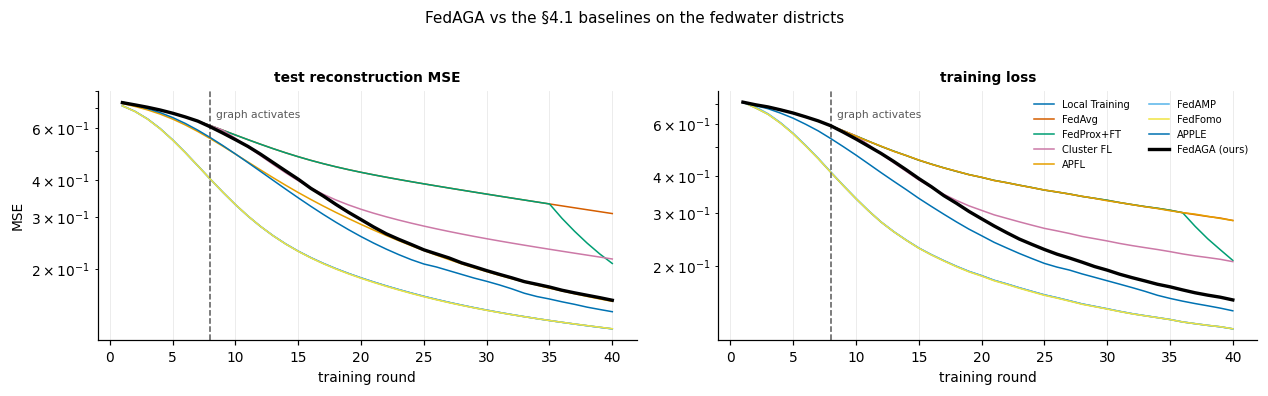

FedAGA activated its graph at round 8 of 40.
Mean KL(p_i || uniform) once active: 0.4423 nats (one-hot would be 1.61).


In [39]:
# --- learning curves ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.4))
show = ["Local Training", "FedAvg", "FedProx+FT", "Cluster FL", "APFL",
        "FedAMP", "FedFomo", "APPLE", "FedAGA (ours)"]
for k, name in enumerate(show):
    if name not in FW_RESULTS:
        continue
    h = FW_RESULTS[name]["history"]
    lw, z = (2.2, 5) if "FedAGA" in name else (1.0, 2)
    col = OKABE[7] if "FedAGA" in name else OKABE[k % 7]
    axes[0].plot(h["round"], h["test_mse"], lw=lw, color=col, label=name, zorder=z)
    axes[1].plot(h["round"], h["train_loss"], lw=lw, color=col, label=name, zorder=z)
ta = FW_RESULTS["FedAGA (ours)"]["t_activate"]
for ax, ttl in zip(axes, ["test reconstruction MSE", "training loss"]):
    if ta:
        ax.axvline(ta, color="0.35", ls="--", lw=1)
        ax.annotate("graph activates", (ta, ax.get_ylim()[1]*0.85), xytext=(4, 0),
                    textcoords="offset points", fontsize=7, color="0.35")
    ax.set_yscale("log"); ax.set_xlabel("training round"); ax.set_title(ttl, fontsize=9)
axes[0].set_ylabel("MSE")
axes[1].legend(fontsize=6.5, ncol=2, loc="upper right")
fig.suptitle("FedAGA vs the §4.1 baselines on the fedwater districts", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()

_fa = FW_RESULTS["FedAGA (ours)"]
print(f"FedAGA activated its graph at round {_fa['t_activate']} of {cfg_fw.rounds}.")
if _fa["t_activate"] is None:
    print("It NEVER activated -- so this run is literally FedAvg and any difference from")
    print("the FedAvg row is seed noise.  Loosen delta1 / lower delta2 and re-read §III.3.")
else:
    print(f"Mean KL(p_i || uniform) once active: "
          f"{_fa['history']['kl_uniform'].dropna().mean():.4f} nats "
          f"(one-hot would be {np.log(len(FW_TEMPLATE)):.2f}).")

## IV.4 RQ2 — is the recovered relationship the hydraulic one?

`fedwater` gives what the paper's own datasets could not: a **physical** answer to
"which clients are related". `gt_topology.open_boundary_pipes > 0` marks the district pairs
that actually share an open pipe, so the Fig. 5(b)/6(b) "true relationship" panel is not a
construction here — it is the network.

Two statistics are scored, because they answer different questions:

* `s_ij` (eq. 4) — **does the method measure the relationship?**
* `p_ij` (eq. 5) — **does it act on it?** After the softmax the weights are much flatter,
  so this is the harder test and the one that matters for the aggregation.

In [41]:
# =============================================================================
# IV.4  Figs. 5/6 analogue -- recovered graph vs the physical boundaries
# =============================================================================
GT = pd.read_csv(GT_TOPOLOGY)
GT["label_connected"] = (GT["open_boundary_pipes"] > 0).astype(int)
names = [c.name for c in FW_TEMPLATE]
NB = len(names)
B_true = np.eye(NB)
for _, r in GT.iterrows():
    i, j = names.index(r["district_a"]), names.index(r["district_b"])
    B_true[i, j] = B_true[j, i] = float(r["label_connected"])

def pair_frame(Mx, names, gt):
    rows = []
    for a, b in itertools.combinations(names, 2):
        i, j = names.index(a), names.index(b)
        rows.append({"district_a": a, "district_b": b,
                     "j_to_i": float(Mx[i, j]), "i_to_j": float(Mx[j, i]),
                     "statistic": float(max(Mx[i, j], Mx[j, i]))})
    return pd.DataFrame(rows).merge(gt, on=["district_a", "district_b"], how="left")


rec_rows, FW_PAIRS = [], {}
for name, res in FW_RESULTS.items():
    if res.get("P") is None:
        continue
    Mx = res["P"].copy()
    pf = pair_frame(Mx, names, GT)
    FW_PAIRS[name] = pf
    y = pf["label_connected"].to_numpy()
    if len(np.unique(y)) > 1 and pf["statistic"].std() > 0:
        rec_rows.append({"method": name, "matrix": "aggregation weights",
                         "AUROC": roc_auc_score(y, pf["statistic"]),
                         "spearman vs open pipes":
                             float(stats.spearmanr(pf["statistic"], pf["open_boundary_pipes"]).statistic)})
S_fa = FW_RESULTS["FedAGA (ours)"]["S"]
if S_fa is not None:
    pf = pair_frame(S_fa, names, GT); FW_PAIRS["FedAGA s_ij"] = pf
    y = pf["label_connected"].to_numpy()
    rec_rows.insert(0, {"method": "FedAGA (ours)", "matrix": "similarity s_ij (eq. 4)",
                        "AUROC": roc_auc_score(y, pf["statistic"]),
                        "spearman vs open pipes":
                            float(stats.spearmanr(pf["statistic"], pf["open_boundary_pipes"]).statistic)})
FW_RECOVERY = pd.DataFrame(rec_rows)
print("Relationship recovery against gt_topology.open_boundary_pipes "
      f"({NB*(NB-1)//2} district pairs, synthetic={SYNTHETIC})\n")
display(FW_RECOVERY.set_index(["method", "matrix"])
        .style.format("{:.4f}").background_gradient(cmap=SEQ, subset=["AUROC"]))

Relationship recovery against gt_topology.open_boundary_pipes (10 district pairs, synthetic=False)



,,AUROC,spearman vs open pipes
method,matrix,,
FedAGA (ours),similarity s_ij (eq. 4),0.3600,-0.1246
FedAvg,aggregation weights,0.5000,nan
Cluster FL,aggregation weights,0.3000,-0.3075
FedAMP,aggregation weights,0.4800,-0.0197
APPLE,aggregation weights,0.3600,-0.1246
FedAGA (ours),aggregation weights,0.3800,-0.0609


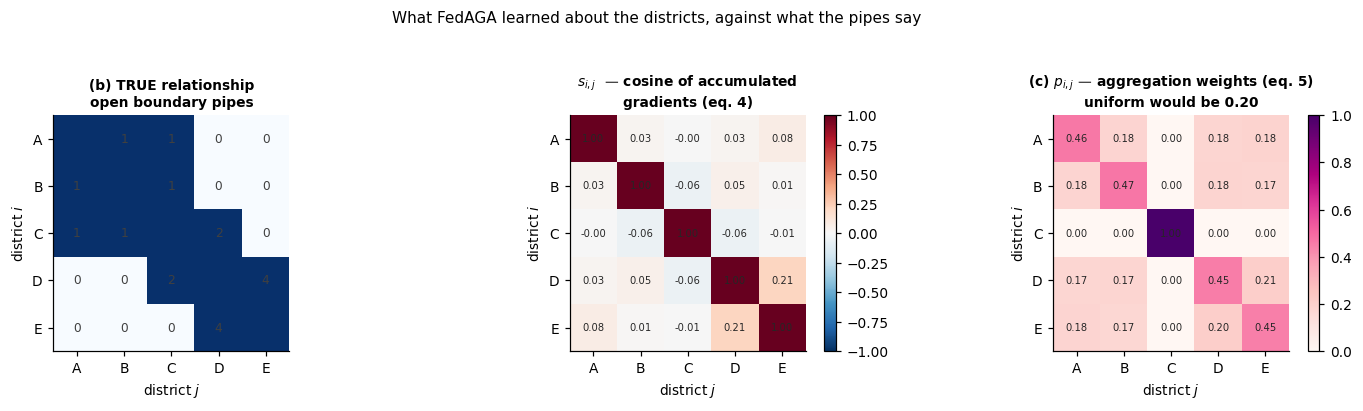

KL(p_i || uniform) per district: A=0.3302  B=0.3333  C=1.6094  D=0.3190  E=0.3183
Uniform weight = 0.2000; observed weights span [0.1675, 1.0000].
If that span is narrow, FedAGA is measuring the relationship well but barely
acting on it -- the softmax over cosine similarities is the bottleneck, not
the similarity itself.  See the temperature experiment in IV.8.


In [42]:
# --- the three-panel figure, in the paper's own layout -----------------------
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.5))
lbl = [n[-1] for n in names]

ax = axes[0]
im = ax.imshow(B_true, cmap="Blues", vmin=0, vmax=1)
for _, r in GT.iterrows():
    i, j = names.index(r["district_a"]), names.index(r["district_b"])
    for a, b in ((i, j), (j, i)):
        ax.text(b, a, int(r["open_boundary_pipes"]), ha="center", va="center",
                fontsize=8, color="0.25")
ax.set_title("(b) TRUE relationship\nopen boundary pipes", fontsize=9)

ax = axes[1]
if S_fa is not None:
    im2 = ax.imshow(S_fa, cmap=DIV, vmin=-1, vmax=1)
    for i in range(NB):
        for j in range(NB):
            ax.text(j, i, f"{S_fa[i,j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="0.15")
    fig.colorbar(im2, ax=ax, fraction=0.046)
ax.set_title("$s_{i,j}$  — cosine of accumulated\ngradients (eq. 4)", fontsize=9)

ax = axes[2]
P_fa = FW_RESULTS["FedAGA (ours)"]["P"]
if P_fa is not None:
    im3 = ax.imshow(P_fa, cmap="RdPu")
    for i in range(NB):
        for j in range(NB):
            ax.text(j, i, f"{P_fa[i,j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="0.15")
    fig.colorbar(im3, ax=ax, fraction=0.046)
ax.set_title(f"(c) $p_{{i,j}}$ — aggregation weights (eq. 5)\n"
             f"uniform would be {1/NB:.2f}", fontsize=9)

for ax in axes:
    ax.set_xticks(range(NB)); ax.set_yticks(range(NB))
    ax.set_xticklabels(lbl); ax.set_yticklabels(lbl); ax.grid(False)
    ax.set_xlabel("district $j$"); ax.set_ylabel("district $i$")
fig.suptitle("What FedAGA learned about the districts, against what the pipes say",
             y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

if P_fa is not None:
    kl = concentration(P_fa)
    print(f"KL(p_i || uniform) per district: " +
          "  ".join(f"{n[-1]}={v:.4f}" for n, v in zip(names, kl)))
    print(f"Uniform weight = {1/NB:.4f}; observed weights span "
          f"[{P_fa[P_fa>0].min():.4f}, {P_fa.max():.4f}].")
    print("If that span is narrow, FedAGA is measuring the relationship well but barely")
    print("acting on it -- the softmax over cosine similarities is the bottleneck, not")
    print("the similarity itself.  See the temperature experiment in IV.8.")

## IV.4b The common-mode problem — and the one-line fix

Read the `s_ij` panel above before anything else. If every off-diagonal entry sits close to
`+1`, the districts are **all descending in the same direction**, and eq. (4) cannot tell
them apart no matter how good the aggregation is. That is not a bug in FedAGA; it is what
happens when the local objective has a large shared component. Reconstructing a water
district's weekly profile is mostly the *same problem* everywhere — diurnal peaks, weekend
dip, seasonal envelope — so the first and largest thing every autoencoder learns is
identical, and it swamps the district-specific remainder.

`fedwater`'s architecture doc names this exact failure in a different guise: *"Naive
hour-of-day residuals make isolated districts look dependent (|r| 0.50 vs 0.045) because
they share seasonality — the exogenous-driver confound."* The FLC_033 notebook removes it by
month-aware residualization of the sensors. Here the same idea applies one level up, to the
**gradients**:

$$\tilde R_i = R_i - \frac{1}{N}\sum_j R_j,
\qquad \tilde s_{i,j}=\frac{\langle\tilde R_i,\tilde R_j\rangle}{|\tilde R_i||\tilde R_j|}$$

Only the *relationship* changes — eq. (6) still aggregates the raw `R_j`, so no update is
altered and the method stays FedAGA. **This is an extension, not the paper.** Note also that
Criterion 1 is exactly a test that `‖R̄‖` has become small; when it never does, the criterion
is vacuous and centring is the alternative to waiting forever.

What is s_ij actually measuring on fedwater?



,off-diag s range,spread,AUROC vs open pipes,mean s: drift vs rest,mean s: among the rest,drift separation
similarity on,,,,,,
raw R_i (eq. 4 as written),"[-0.058, +0.214]",0.272,0.360,+0.059,+0.009,-0.050
centred R_i - mean(R) [extension],"[-0.478, +0.086]",0.564,0.840,-0.252,-0.235,+0.017


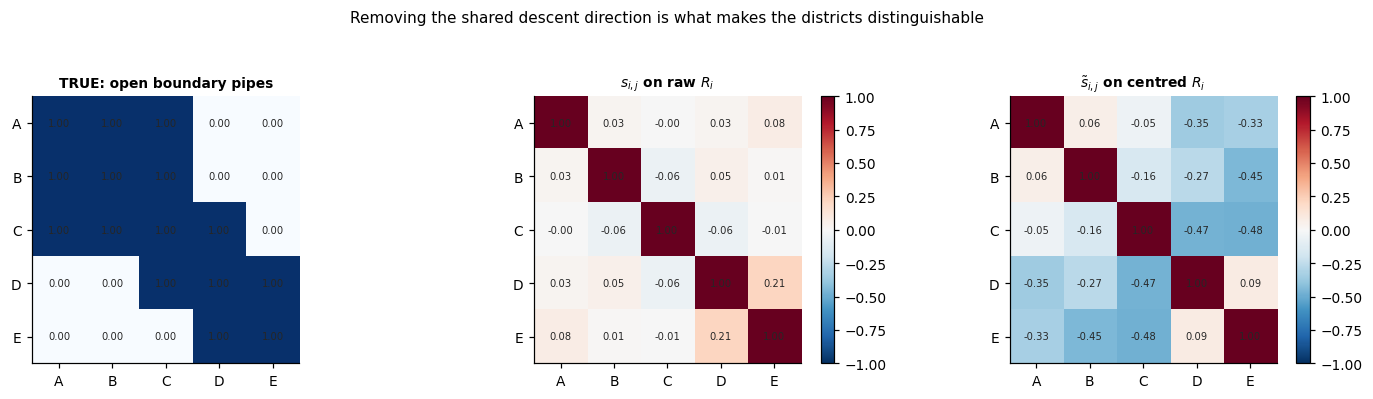

How to read this table, in order:
  1. If 'spread' on the RAW row is small, eq. (4) has nothing to work with and
     p_ij is uniform -- FedAGA is FedAvg regardless of what the criteria say.
  2. Compare the two AUROC values.  Centring can only help if the coupling
     signal was hiding under the common mode.
  3. Read 'drift separation' last, and take it seriously.  s_ij is a
     DISTRIBUTION-similarity statistic: it answers 'do these two clients want
     the same model?', which is NOT the same question as 'do these two districts
     share a pipe?'.  A large drift separation with a chance-level topology AUROC
     means FedAGA found the district whose DEMAND changed, not the district
     adjacency -- which is arguably the more useful of the two for fedwater, and
     is exactly complementary to what the FLC_033 notebook recovers.


In [44]:
# =============================================================================
# IV.4b  Centred accumulated gradients   [extension, not in the paper]
# =============================================================================
FW_CENTERED = run_fedaga(fw_factory(), RECON, make_ae,
                         replace(cfg_fw, center_gradients=True))
S_raw, S_ctr = FW_RESULTS["FedAGA (ours)"]["S"], FW_CENTERED["S"]
off = ~np.eye(NB, dtype=bool)

rows = []
for tag, Mx in [("raw R_i  (eq. 4 as written)", S_raw),
                ("centred R_i - mean(R)  [extension]", S_ctr)]:
    if Mx is None:
        continue
    pf = pair_frame(Mx, names, GT)
    y = pf["label_connected"].to_numpy()
    r = {"similarity on": tag,
         "off-diag s range": f"[{Mx[off].min():+.3f}, {Mx[off].max():+.3f}]",
         "spread": float(Mx[off].max() - Mx[off].min()),
         "AUROC vs open pipes": (roc_auc_score(y, pf["statistic"])
                                 if len(np.unique(y)) > 1 else np.nan)}
    if drift_origin in names:
        k = names.index(drift_origin)
        to_drift = np.array([Mx[k, j] for j in range(NB) if j != k])
        among = np.array([Mx[i, j] for i in range(NB) for j in range(NB)
                          if i != j and i != k and j != k])
        r["mean s: drift vs rest"] = float(to_drift.mean())
        r["mean s: among the rest"] = float(among.mean())
        r["drift separation"] = float(among.mean() - to_drift.mean())
    rows.append(r)
CENTER_TAB = pd.DataFrame(rows).set_index("similarity on")
print("What is s_ij actually measuring on fedwater?\n")
display(CENTER_TAB.style.format({"spread": "{:.3f}", "AUROC vs open pipes": "{:.3f}",
                                 "mean s: drift vs rest": "{:+.3f}",
                                 "mean s: among the rest": "{:+.3f}",
                                 "drift separation": "{:+.3f}"}, na_rep="–"))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.4))
for ax, (Mx, ttl) in zip(axes, [(B_true, "TRUE: open boundary pipes"),
                                (S_raw, "$s_{i,j}$ on raw $R_i$"),
                                (S_ctr, "$\\tilde s_{i,j}$ on centred $R_i$")]):
    if Mx is None:
        ax.text(.5, .5, "no graph", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_title(ttl, fontsize=9)
        continue
    im = ax.imshow(Mx, cmap=DIV, vmin=-1, vmax=1) if Mx is not B_true else \
         ax.imshow(Mx, cmap="Blues", vmin=0, vmax=1)
    for i in range(NB):
        for j in range(NB):
            ax.text(j, i, f"{Mx[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="0.15")
    ax.set_xticks(range(NB)); ax.set_yticks(range(NB)); ax.grid(False)
    ax.set_xticklabels(lbl); ax.set_yticklabels(lbl)
    ax.set_title(ttl, fontsize=9)
    if Mx is not B_true:
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Removing the shared descent direction is what makes the districts "
             "distinguishable", y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

print("How to read this table, in order:")
print("  1. If 'spread' on the RAW row is small, eq. (4) has nothing to work with and")
print("     p_ij is uniform -- FedAGA is FedAvg regardless of what the criteria say.")
print("  2. Compare the two AUROC values.  Centring can only help if the coupling")
print("     signal was hiding under the common mode.")
print("  3. Read 'drift separation' last, and take it seriously.  s_ij is a")
print("     DISTRIBUTION-similarity statistic: it answers 'do these two clients want")
print("     the same model?', which is NOT the same question as 'do these two districts")
print("     share a pipe?'.  A large drift separation with a chance-level topology AUROC")
print("     means FedAGA found the district whose DEMAND changed, not the district")
print("     adjacency -- which is arguably the more useful of the two for fedwater, and")
print("     is exactly complementary to what the FLC_033 notebook recovers.")

---
# IV.5 — THE RESEARCH QUESTION: do the districts cluster by demand regime?

Everything above measures a *relationship*. This section turns it into a **partition** and
scores it, which is the thing the project actually needs.

## The target

Each district has a coded `(initial, final)` demand regime in `DISTRICT_STATE`:

| district | init | final |
|---|---|---|
| District_A | LL | LL |
| District_B | HH | HH |
| District_C | LL | LL |
| **District_D** | **HH** | **LL** |
| District_E | HH | HH |

so the two ground-truth partitions are

* **init**  `{A, C}` vs `{B, D, E}`
* **final** `{A, C, D}` vs `{B, E}`

and the single question that distinguishes a working method from a lucky one is whether
**D crosses over**. A method that scores well on `init` and well on `final` but never moves
`D` has learned the static split and nothing else.

## What has to change, relative to the paper and to §IV.1–IV.4

1. **Per phase, not pooled.** FedAGA computes one `s_ij` from the whole record. The regime
   changes inside that record, so pooling averages the two answers together. The phases are
   derived from `gt_drift_schedule`: `init` = months strictly before the drift onset (which
   is also `fl.preprocessing.reference_months`, the commissioning period), `final` = months
   strictly after the ramp completes.
2. **A partition, not a matrix.** Average-linkage agglomerative clustering on `1 − s_ij`,
   `k = 2`. With five districts there are exactly **15** distinct 2-partitions, so we can
   enumerate the entire null and report an *exact* permutation p-value rather than leaning
   on ARI's asymptotics.
3. **More than one similarity signal.** FedAGA's `s_ij` is one candidate; there are cheaper
   and possibly better ones, and §III.2b already predicted which. All are federated —
   nothing but gradients or parameters ever leaves a district — except the last, which is a
   deliberate centralized **ceiling**.

## The scaling question, which turns out to matter

`fl_preprocessing` fits its min–max scaler on the commissioning months. Keep that and a
district whose demand *level* rises stays visibly different. Rescale inside each phase and
only the *shape* of the profile can carry the regime. `PHASE_SCALING = "both"` runs both,
which answers a question worth answering: **is "LL vs HH" a level difference or a shape
difference?** If only reference-scaling works, the clustering is really a magnitude
detector and will fail on any district that drifts without changing volume.

In [141]:
# =============================================================================
# IV.5.1  Phases from gt_drift_schedule, and per-phase clients
# =============================================================================
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ALL_MONTHS = np.unique(np.concatenate([c.meta["months"] for c in FW_TEMPLATE]))
M_MIN, M_MAX = int(ALL_MONTHS.min()), int(ALL_MONTHS.max())

def derive_phases():
    """init = months < drift onset ; final = months > end of the drift ramp."""
    if GT_DRIFT.exists():
        g = pd.read_csv(GT_DRIFT)
        onset, end = int(g["drift_month"].min()), int(g["drift_month"].max())
    else:                                   # no ground truth -> quartiles
        onset = M_MIN + max(1, (M_MAX - M_MIN + 1) // 4)
        end = M_MAX - max(1, (M_MAX - M_MIN + 1) // 4)
    init = [m for m in ALL_MONTHS if m < onset]
    final = [m for m in ALL_MONTHS if m > end]
    # guard: a ramp that runs to the last month leaves no post-drift window
    if len(final) < 2:
        span = max(2, (M_MAX - M_MIN + 1) // 6)
        final = [m for m in ALL_MONTHS if m > M_MAX - span]
    if len(init) < 2:
        init = [m for m in ALL_MONTHS if m <= M_MIN + 1]
    return {"init": [int(m) for m in init], "final": [int(m) for m in final]}, onset, end


PHASES, DRIFT_ONSET, DRIFT_END = derive_phases()
print(f"months present            : {M_MIN}..{M_MAX}")
print(f"drift ramp (gt_schedule)  : month {DRIFT_ONSET} -> {DRIFT_END}")
print(f"INIT  phase               : months {PHASES['init']}")
print(f"FINAL phase               : months {PHASES['final']}")

TRUTH = {ph: {d: DISTRICT_STATE[d][k] for d in DISTRICT_STATE}
         for k, ph in enumerate(["init", "final"])}
for ph in ("init", "final"):
    groups = {}
    for d, lab in TRUTH[ph].items():
        groups.setdefault(lab, []).append(d[-1])
    print(f"target {ph:<5s} partition : " +
          "  |  ".join("{" + ", ".join(sorted(v)) + "}" for k, v in sorted(groups.items())))

months present            : 0..23
drift ramp (gt_schedule)  : month 2 -> 19
INIT  phase               : months [0, 1]
FINAL phase               : months [20, 21, 22, 23]
target init  partition : {C}  |  {A, D, E}  |  {B}
target final partition : {C}  |  {A, E}  |  {B, D}


In [143]:
# =============================================================================
# IV.5.2  Per-phase window builder  (fl_preprocessing recipe, two scaler choices)
# =============================================================================
def build_phase_clients(months, scaling="reference", stride=PHASE_STRIDE,
                        window=WINDOW, agg=AGG_STEPS, ref_months=REF_MONTHS,
                        test_frac=TEST_FRAC, seed=SEED):
    """Windows whose majority month falls inside `months`.

    scaling="reference" : min-max fitted on the COMMISSIONING months (what
                          fl_preprocessing does) -> a level change stays visible.
    scaling="phase"     : min-max fitted inside this phase -> only the profile SHAPE
                          can carry the regime.
    """
    rng = np.random.default_rng(seed)
    out = []
    mset = set(int(m) for m in months)
    for f in sorted(CLIENTS_DIR.glob("*.csv")):
        df = pd.read_csv(f)
        sens = sorted(c for c in df.columns if c.startswith(("p_", "q_")))
        X = df[sens].to_numpy(np.float64)
        mo = df["month"].to_numpy()
        Xa = _aggregate(X, agg)
        ma = mo[: (len(mo) // agg) * agg].reshape(-1, agg)[:, 0]
        if scaling == "reference":
            fit = ma < ref_months
        else:
            fit = np.isin(ma, list(mset))
        lo, hi = Xa[fit].min(axis=0), Xa[fit].max(axis=0)
        span = np.where(hi - lo == 0, 1.0, hi - lo)
        Xs = (Xa - lo) * (2.0 / span) - 1.0
        starts = np.arange(0, len(Xs) - window + 1, stride)
        keep = [s for s in starts
                if int(np.bincount(ma[s:s + window]).argmax()) in mset]
        if len(keep) < 20:
            raise ValueError(f"{f.stem}: only {len(keep)} windows in phase {sorted(mset)}")
        W = np.stack([Xs[s:s + window] for s in keep]).astype(np.float32)
        flat = torch.tensor(W.reshape(len(W), -1))
        n = len(flat); p = rng.permutation(n); k = int(n * (1 - test_frac))
        out.append(Client(f.stem, flat[p[:k]], flat[p[:k]], flat[p[k:]], flat[p[k:]],
                          meta={"months": np.array([ma[s + window // 2] for s in keep]),
                                "all": flat, "window": W.shape[1], "feats": W.shape[2]}))
    return out


PHASE_CLIENTS = {}
for scaling in (["reference", "phase"] if PHASE_SCALING == "both" else [PHASE_SCALING]):
    for ph, months in PHASES.items():
        PHASE_CLIENTS[(ph, scaling)] = build_phase_clients(months, scaling)
        c0 = PHASE_CLIENTS[(ph, scaling)][0]
        print(f"{ph:<5s} / {scaling:<9s}: {c0.n} train + {c0.Xte.shape[0]} test windows "
              f"per district")

init  / reference: 272 train + 68 test windows per district
final / reference: 559 train + 140 test windows per district
init  / phase    : 272 train + 68 test windows per district
final / phase    : 559 train + 140 test windows per district


final / reference: 271 train + 68 test windows per district


init  / phase    : 272 train + 68 test windows per district


final / phase    : 271 train + 68 test windows per district


In [144]:
# =============================================================================
# IV.5.3  Six similarity signals -- five federated, one centralized ceiling
# =============================================================================

def sim_round1(clients, task, make_model, cfg):
    """ONE round of local training from a COMMON initialisation, then cosine of the
    accumulated gradients.  No aggregation, no graph, no criteria.

    §III.2b predicted this would be the most accurate relationship measurement
    available, and the reason is structural: with every client starting from the same
    theta, R_i is a function of client i's data and nothing else, so the angle between
    R_i and R_j is a pure data-similarity statistic.  It is also by far the cheapest
    signal here -- one round, one model-sized upload per district, no download.
    """
    gen = torch.Generator().manual_seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    model = make_model()
    th0 = flat_params(model).clone()
    R = torch.stack([local_train(model, th0, c, task, cfg.epochs, cfg.lr, cfg.batch, gen)[0]
                     for c in clients])
    return similarity_matrix(R), similarity_matrix(R - R.mean(0, keepdim=True))


def sim_param_distance(clients, task, make_model, cfg, rounds=None):
    """FedAMP's signal: train each client alone, then similarity = -||theta_i - theta_j||,
    rescaled to [-1, 1].  This is the EUCLIDEAN-parameter view FedAGA argues against, so
    it is the comparator that tests the paper's core claim on your data."""
    cfg = replace(cfg, rounds=rounds or cfg.rounds)
    res = run_local([Client(c.name, c.Xtr, c.Ytr, c.Xte, c.Yte, meta=c.meta)
                     for c in clients], task, make_model, cfg)
    T = torch.stack([c.theta for c in res["clients"]])
    D = torch.cdist(T, T).cpu().numpy()
    S = 1.0 - 2.0 * D / max(D.max(), 1e-12)
    np.fill_diagonal(S, 1.0)
    return S


def sim_fedaga(clients, task, make_model, cfg, centered=False):
    """The paper's own signal: s_ij from the last round at which the graph was active."""
    res = run_fedaga([Client(c.name, c.Xtr, c.Ytr, c.Xte, c.Yte, meta=c.meta)
                      for c in clients], task, make_model,
                     replace(cfg, center_gradients=centered))
    if res["S"] is None:                       # criteria never fired -> force it, and say so
        res = run_fedaga([Client(c.name, c.Xtr, c.Ytr, c.Xte, c.Yte, meta=c.meta)
                          for c in clients], task, make_model,
                         replace(cfg, center_gradients=centered),
                         force_graph_from=max(1, cfg.rounds // 2))
        res["forced"] = True
    return res["S"], res


def sim_profile_ceiling(clients):
    """CENTRALIZED CEILING -- not federated, and not a method.

    Every district's mean window, centred across districts, compared by cosine.  This is
    what a analyst with all the raw data in one place would see in ten seconds.  If this
    cannot separate the regimes, nothing downstream can, and a poor federated score is a
    statement about the DATA rather than about the algorithm.
    """
    M = torch.stack([c.meta["all"].mean(0) for c in clients]).cpu().numpy()
    M = M - M.mean(0, keepdims=True)
    Mn = M / np.clip(np.linalg.norm(M, axis=1, keepdims=True), 1e-12, None)
    return Mn @ Mn.T


def phase_similarities(clients, task, make_model, cfg):
    s_r1_raw, s_r1_ctr = sim_round1(clients, task, make_model, cfg)
    s_fa, res_fa = sim_fedaga(clients, task, make_model, cfg, centered=False)
    s_fac, res_fac = sim_fedaga(clients, task, make_model, cfg, centered=True)
    return {
        "round-1 gradients (raw)":       s_r1_raw,
        "round-1 gradients (centred)":   s_r1_ctr,
        "FedAGA s_ij (eq. 4)":           s_fa,
        "FedAGA s_ij (centred)":         s_fac,
        "parameter distance (FedAMP)":   sim_param_distance(clients, task, make_model, cfg),
        "mean profile [CEILING, not federated]": sim_profile_ceiling(clients),
    }, {"fedaga": res_fa, "fedaga_centred": res_fac}

In [145]:
# =============================================================================
# IV.5.4  Similarity -> partition -> score  (exact null over all 15 partitions)
# =============================================================================

def cluster_from_similarity(S: np.ndarray, k: int = 2) -> np.ndarray:
    """Average-linkage agglomeration on 1 - s_ij.  With N = 5 the choice of linkage
    barely matters; what matters is that the input is a SIMILARITY, so the distance is
    1 - s and never negative."""
    D = 1.0 - np.asarray(S, dtype=float)
    D = (D + D.T) / 2.0
    D -= D.min()
    np.fill_diagonal(D, 0.0)
    return AgglomerativeClustering(n_clusters=k, metric="precomputed",
                                   linkage="average").fit_predict(D)


def all_two_partitions(n: int):
    """Every distinct assignment of n items to 2 non-empty unlabelled groups.
    n = 5 -> 15 of them, so the permutation null below is EXACT, not sampled."""
    out = []
    for mask in range(1, 2 ** (n - 1)):
        lab = np.array([(mask >> i) & 1 for i in range(n)])
        if 0 < lab.sum() < n:
            out.append(lab)
    return out


_PARTS = all_two_partitions(len(DISTRICT_STATE))


def _codes(labels) -> np.ndarray:
    """Integer codes for a list of string labels (np.unique keeps pandas versions out
    of it -- pandas 3 refuses a bare list in factorize)."""
    return np.unique(np.asarray(labels, dtype=object), return_inverse=True)[1]


def score_partition(pred: np.ndarray, truth_labels) -> dict:
    y = _codes(truth_labels)
    ari = adjusted_rand_score(y, pred)
    null = np.array([adjusted_rand_score(y, p) for p in _PARTS])
    same = _same_group(pred)
    return {"ARI": ari,
            "NMI": normalized_mutual_info_score(y, pred),
            "exact match": bool(np.array_equal(_canon(pred), _canon(y))),
            "p (exact, 15 partitions)": float((null >= ari).mean()),
            "partition": _fmt(pred)}


def _canon(lab):
    lab = np.asarray(lab)
    return (lab != lab[0]).astype(int)


def _same_group(lab):
    lab = np.asarray(lab)
    return lab[:, None] == lab[None, :]


def _fmt(lab):
    names = list(DISTRICT_STATE)
    g = {}
    for d, l in zip(names, lab):
        g.setdefault(int(l), []).append(d[-1])
    return "  |  ".join("{" + ",".join(sorted(v)) + "}" for _, v in sorted(g.items()))


def migration_report(pred_init, pred_final, mover=None) -> dict:
    """The question the two static partitions cannot answer on their own: did the
    drifting district change company?  `mover` defaults to whichever district has a
    different init and final code in DISTRICT_STATE."""
    names = list(DISTRICT_STATE)
    mover = mover or next((d for d in names if DISTRICT_STATE[d][0] != DISTRICT_STATE[d][1]),
                          names[0])
    k = names.index(mover)
    Si, Sf = _same_group(pred_init), _same_group(pred_final)
    with_init = {names[j][-1] for j in range(len(names)) if j != k and Si[k, j]}
    with_final = {names[j][-1] for j in range(len(names)) if j != k and Sf[k, j]}
    tgt_i = {d[-1] for d in names
             if d != mover and TRUTH["init"][d] == TRUTH["init"][mover]}
    tgt_f = {d[-1] for d in names
             if d != mover and TRUTH["final"][d] == TRUTH["final"][mover]}
    return {"grouped with (init)": "{" + ",".join(sorted(with_init)) + "}",
            "grouped with (final)": "{" + ",".join(sorted(with_final)) + "}",
            "target (init)": "{" + ",".join(sorted(tgt_i)) + "}",
            "target (final)": "{" + ",".join(sorted(tgt_f)) + "}",
            "moved": with_init != with_final,
            "moved CORRECTLY": (with_init == tgt_i) and (with_final == tgt_f)}

In [146]:
# =============================================================================
# IV.5.5  Run it
# =============================================================================
cfg_ph = replace(cfg_fw, rounds=PHASE_ROUNDS)
t0 = time.time()
SIMS, ROWS, PREDS = {}, [], {}
for scaling in (["reference", "phase"] if PHASE_SCALING == "both" else [PHASE_SCALING]):
    for ph in ("init", "final"):
        cl = PHASE_CLIENTS[(ph, scaling)]
        sims, extra = phase_similarities(cl, RECON, make_ae, cfg_ph)
        SIMS[(ph, scaling)] = sims
        truth = [TRUTH[ph][d] for d in DISTRICT_STATE]
        for sname, S in sims.items():
            pred = cluster_from_similarity(S)
            PREDS[(ph, scaling, sname)] = pred
            ROWS.append({"phase": ph, "scaling": scaling, "signal": sname,
                         **score_partition(pred, truth)})
print(f"({time.time()-t0:.0f}s)\n")

CLUST = pd.DataFrame(ROWS)
for scaling in CLUST["scaling"].unique():
    d = CLUST[CLUST["scaling"] == scaling]
    print(f"=== scaling = {scaling} "
          f"({'level change visible' if scaling == 'reference' else 'shape only'}) ===")
    show = d.pivot(index="signal", columns="phase",
                   values=["ARI", "exact match", "p (exact, 15 partitions)", "partition"])
    display(show.style.format({c: "{:.3f}" for c in show.columns
                               if c[0] in ("ARI", "p (exact, 15 partitions)")}))
    print()

(91s)

=== scaling = reference (level change visible) ===



=== scaling = phase (shape only) ===


In [148]:
# --- the migration test ------------------------------------------------------
mig_rows = []
for scaling in CLUST["scaling"].unique():
    for sname in SIMS[("init", scaling)]:
        m = migration_report(PREDS[("init", scaling, sname)],
                             PREDS[("final", scaling, sname)])
        mig_rows.append({"scaling": scaling, "signal": sname, **m})
MIG = pd.DataFrame(mig_rows)
MOVER = next((d for d in DISTRICT_STATE if DISTRICT_STATE[d][0] != DISTRICT_STATE[d][1]),
             "District_D")
print(f"THE MIGRATION TEST -- does {MOVER} change company between the phases?")
print(f"   {MOVER} is coded {DISTRICT_STATE[MOVER][0]} -> {DISTRICT_STATE[MOVER][1]}, so it")
print("   should start beside its INIT-regime peers and end beside its FINAL-regime peers.")
print("   'moved CORRECTLY' requires BOTH, which is a much smaller target than either.\n")
display(MIG.set_index(["scaling", "signal"]).style
        .map(lambda v: "color:#0a7d38;font-weight:600" if v is True
             else ("color:#b23c17" if v is False else ""),
             subset=["moved", "moved CORRECTLY"]))

n_ok = int(MIG["moved CORRECTLY"].sum())
print(f"\n{n_ok} of {len(MIG)} (signal x scaling) combinations put D with the right "
      f"company in BOTH phases.")
if n_ok == 0:
    print("None did.  Before concluding the method fails, read the CEILING row: if the")
    print("centralized mean-profile similarity also fails, the regime is not recoverable")
    print("from these windows at all and the problem is upstream of any federated method.")

THE MIGRATION TEST -- does District_D change company between the phases?
   District_D is coded LL -> LM, so it
   should start beside its INIT-regime peers and end beside its FINAL-regime peers.
   'moved CORRECTLY' requires BOTH, which is a much smaller target than either.




1 of 12 (signal x scaling) combinations put D with the right company in BOTH phases.


best FEDERATED signal : FedAGA s_ij (eq. 4)  [phase scaling]  mean ARI +0.365
centralized ceiling   : mean ARI +0.664  [reference scaling]
Read the federated number against the ceiling, not against 0.  A ceiling near 0
means the regimes are not separable from these windows and no method can win.


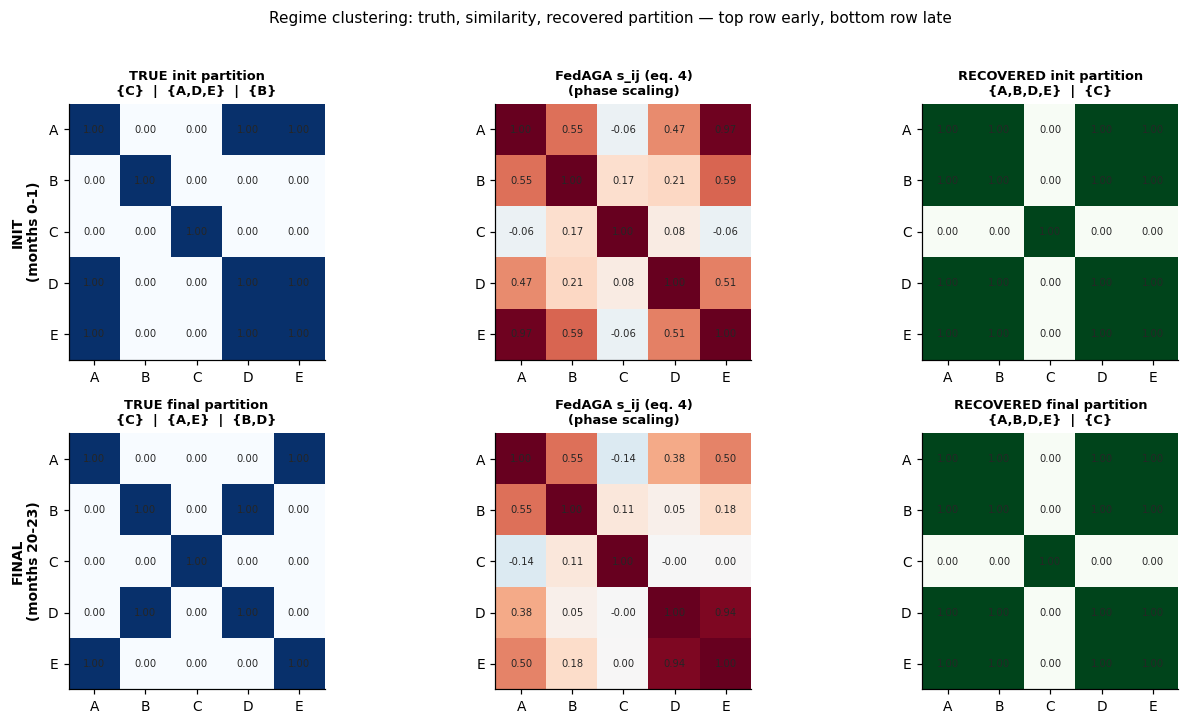

In [152]:
# --- figure: truth vs the best signal, both phases ---------------------------
rank = CLUST.groupby(["scaling", "signal"])["ARI"].mean().sort_values(ascending=False)
fed = rank[[not ("CEILING" in sig) for _, sig in rank.index]]
best_scaling, best_signal = fed.index[0]
ceil = rank[[("CEILING" in sig) for _, sig in rank.index]]
print(f"best FEDERATED signal : {best_signal}  [{best_scaling} scaling]  "
      f"mean ARI {fed.iloc[0]:+.3f}")
print(f"centralized ceiling   : mean ARI {ceil.iloc[0]:+.3f}  [{ceil.index[0][0]} scaling]")
print("Read the federated number against the ceiling, not against 0.  A ceiling near 0")
print("means the regimes are not separable from these windows and no method can win.")

names5 = list(DISTRICT_STATE)
lbl5 = [n[-1] for n in names5]
fig, axes = plt.subplots(2, 3, figsize=(12.4, 6.4))
for r, ph in enumerate(("init", "final")):
    truth = [TRUTH[ph][d] for d in names5]
    tcode = _codes(truth)
    Bt = (tcode[:, None] == tcode[None, :]).astype(float)
    S = SIMS[(ph, best_scaling)][best_signal]
    pred = PREDS[(ph, best_scaling, best_signal)]
    Bp = _same_group(pred).astype(float)
    for c, (Mx, ttl, cmap, vr) in enumerate([
            (Bt, f"TRUE {ph} partition\n" + _fmt(tcode), "Blues", (0, 1)),
            (S, f"{best_signal}\n({best_scaling} scaling)", DIV, (-1, 1)),
            (Bp, f"RECOVERED {ph} partition\n" + _fmt(pred), "Greens", (0, 1))]):
        ax = axes[r, c]
        ax.imshow(Mx, cmap=cmap, vmin=vr[0], vmax=vr[1])
        for i in range(5):
            for j in range(5):
                ax.text(j, i, f"{Mx[i, j]:.2f}", ha="center", va="center",
                        fontsize=6.5, color="0.15")
        ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.grid(False)
        ax.set_xticklabels(lbl5); ax.set_yticklabels(lbl5)
        ax.set_title(ttl, fontsize=8.5)
        if c == 0:
            ax.set_ylabel(f"{ph.upper()}\n(months {PHASES[ph][0]}-{PHASES[ph][-1]})",
                          fontsize=9, fontweight="bold")
fig.suptitle("Regime clustering: truth, similarity, recovered partition — "
             "top row early, bottom row late", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

# IV.6 — When does the migration happen?

Two snapshots say *whether* `District_D` changed sides. A trajectory says *when*, which is
much more useful operationally and is a strictly stronger claim: a spurious result is
unlikely to move at the right month.

The record is cut into `N_BLOCKS` consecutive month blocks. In each block, every district
trains for one round from a **common initialisation** and the cosine of the accumulated
gradients is taken — the `round-1` signal from §IV.5.3, which §III.2b argued is the cleanest
relationship measurement available and which costs one round per block. For each district we
then track

$$a_i(\text{block}) \;=\; \overline{s_{i,j}}\big|_{j \in \text{LL}_{\text{init}}} \;-\; \overline{s_{i,j}}\big|_{j \in \text{HH}_{\text{init}}}$$

using the **initial** regime groups (excluding `D` itself, and excluding `D` from both
reference groups so the trajectory cannot be contaminated by the thing it is measuring).
A district that migrates from HH to LL should cross zero somewhere inside the drift ramp.

reference groups (init regimes, D excluded):  LL = ['A', 'E']   HH = ['B', 'C']
(3s)



,A,B,C,D,E
months,,,,,
0-3,+0.679,+0.166,-0.395,+0.104,+0.688
4-7,+0.608,+0.186,-0.364,+0.231,+0.650
8-11,+0.476,+0.279,-0.249,+0.364,+0.454
12-15,+0.397,+0.110,-0.268,+0.384,+0.400
16-19,+0.347,+0.223,-0.207,+0.398,+0.392
20-23,+0.267,+0.156,-0.201,+0.415,+0.258


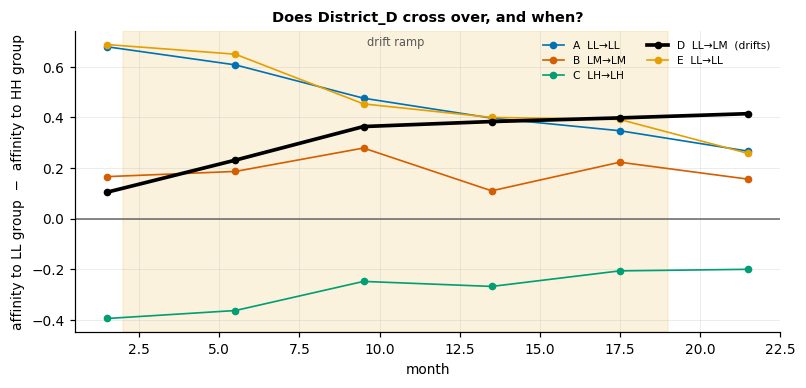


Affinity to the LL group minus affinity to the HH group, first vs last block:
   A  LL->LL: +0.679  ->  +0.267   (delta -0.413)
   B  LM->LM: +0.166  ->  +0.156   (delta -0.010)
   C  LH->LH: -0.395  ->  -0.201   (delta +0.195)
   D  LL->LM: +0.104  ->  +0.415   (delta +0.310)
   E  LL->LL: +0.688  ->  +0.258   (delta -0.430)

District_D never crosses zero on this signal (starts +0.104, ends +0.415).
Two different diagnoses, and the sign tells them apart: starting POSITIVE means
the signal never had the initial regime right, so it is not tracking regime at
all; staying NEGATIVE means the initial split is right but the migration is
invisible in the gradients -- try the other PHASE_SCALING, or a wider model.



Affinity to the LL group minus affinity to the HH group, first vs last block:
   A  LL->LL: +0.835  ->  +1.123   (delta +0.288)
   B  HH->HH: -0.584  ->  -1.130   (delta -0.545)
   C  LL->LL: +0.862  ->  +1.202   (delta +0.340)
   D  HH->LL: -0.708  ->  +0.669   (delta +1.378)
   E  HH->HH: -0.827  ->  -0.951   (delta -0.123)

District_D crosses from HH-like to LL-like in block 6-7 -- INSIDE the drift ramp (2-10).
A crossing that lands inside the ramp is a much stronger result than either
static partition: a spurious signal has no reason to change sign at the
right month.


In [156]:
# =============================================================================
# IV.6  Month-blocked migration trajectory
# =============================================================================
blocks = np.array_split(np.array(sorted(int(m) for m in ALL_MONTHS)), N_BLOCKS)
blocks = [b for b in blocks if len(b) > 0]
names5 = list(DISTRICT_STATE)
LL0 = [d for d in names5 if TRUTH["init"][d] == TRUTH["init"]["District_A"]
       and d != "District_D"]
HH0 = [d for d in names5 if TRUTH["init"][d] != TRUTH["init"]["District_A"]
       and d != "District_D"]
print(f"reference groups (init regimes, D excluded):  LL = "
      f"{[d[-1] for d in LL0]}   HH = {[d[-1] for d in HH0]}")

t0 = time.time()
traj = []
cfg_blk = replace(cfg_fw, rounds=1)
for bi, b in enumerate(blocks):
    try:
        cl = build_phase_clients(list(b), scaling=best_scaling, stride=PHASE_STRIDE)
    except ValueError as e:
        print(f"  block {bi} skipped: {e}"); continue
    S, Sc = sim_round1(cl, RECON, make_ae, cfg_blk)
    use = Sc if "centred" in best_signal else S
    for i, d in enumerate(names5):
        ll = np.mean([use[i, names5.index(x)] for x in LL0 if x != d]) if LL0 else np.nan
        hh = np.mean([use[i, names5.index(x)] for x in HH0 if x != d]) if HH0 else np.nan
        traj.append({"block": bi, "months": f"{b[0]}-{b[-1]}", "mid": float(np.mean(b)),
                     "district": d, "affinity_LL_minus_HH": float(ll - hh)})
TRAJ = pd.DataFrame(traj).sort_values(["mid", "district"])
print(f"({time.time()-t0:.0f}s)\n")
piv = (TRAJ.pivot(index=["block", "months"], columns="district",
                  values="affinity_LL_minus_HH")
       .reset_index().sort_values("block").set_index("months").drop(columns="block"))
piv.columns = [c[-1] for c in piv.columns]
display(piv.style.format("{:+.3f}")
        .background_gradient(cmap=DIV, vmin=-abs(piv.to_numpy()).max(),
                             vmax=abs(piv.to_numpy()).max(), axis=None))

fig, ax = plt.subplots(figsize=(7.4, 3.6))
for k, d in enumerate(names5):
    g = TRAJ[TRAJ["district"] == d]
    hot = (d == "District_D")
    ax.plot(g["mid"], g["affinity_LL_minus_HH"], marker="o", ms=4,
            lw=2.4 if hot else 1.1, color=OKABE[7] if hot else OKABE[k % 7],
            label=f"{d[-1]}  {DISTRICT_STATE[d][0]}→{DISTRICT_STATE[d][1]}"
                  + ("  (drifts)" if hot else ""), zorder=5 if hot else 2)
ax.axhline(0, color="0.4", lw=1)
ax.axvspan(DRIFT_ONSET, DRIFT_END, color=OKABE[4], alpha=0.13, zorder=0)
ax.annotate("drift ramp", ((DRIFT_ONSET + DRIFT_END) / 2, ax.get_ylim()[1] * 0.92),
            ha="center", fontsize=7.5, color="0.35")
ax.set_xlabel("month"); ax.set_ylabel("affinity to LL group  −  affinity to HH group")
ax.set_title("Does District_D cross over, and when?", fontsize=9.5)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

print("\nAffinity to the LL group minus affinity to the HH group, first vs last block:")
for d in names5:
    g = TRAJ[TRAJ["district"] == d].sort_values("mid")
    print(f"   {d[-1]}  {DISTRICT_STATE[d][0]}->{DISTRICT_STATE[d][1]}: "
          f"{g['affinity_LL_minus_HH'].iloc[0]:+.3f}  ->  "
          f"{g['affinity_LL_minus_HH'].iloc[-1]:+.3f}   "
          f"(delta {g['affinity_LL_minus_HH'].iloc[-1] - g['affinity_LL_minus_HH'].iloc[0]:+.3f})")

dtr = TRAJ[TRAJ["district"] == MOVER].sort_values("mid")
sign = np.sign(dtr["affinity_LL_minus_HH"].to_numpy())
cross = [i for i in range(1, len(sign)) if sign[i] > 0 and sign[i - 1] <= 0]
print()
if cross:
    b = dtr.iloc[cross[0]]
    inside = DRIFT_ONSET <= b["mid"] <= DRIFT_END + 1
    print(f"{MOVER} crosses from HH-like to LL-like in block {b['months']} "
          f"-- {'INSIDE' if inside else 'OUTSIDE'} the drift ramp ({DRIFT_ONSET}-{DRIFT_END}).")
    if inside:
        print("A crossing that lands inside the ramp is a much stronger result than either")
        print("static partition: a spurious signal has no reason to change sign at the")
        print("right month.")
else:
    d0 = dtr["affinity_LL_minus_HH"].iloc[0]
    print(f"{MOVER} never crosses zero on this signal (starts {d0:+.3f}, ends "
          f"{dtr['affinity_LL_minus_HH'].iloc[-1]:+.3f}).")
    print("Two different diagnoses, and the sign tells them apart: starting POSITIVE means")
    print("the signal never had the initial regime right, so it is not tracking regime at")
    print("all; staying NEGATIVE means the initial split is right but the migration is")
    print("invisible in the gradients -- try the other PHASE_SCALING, or a wider model.")

## IV.7 — does personalization help detect the drift?

`fedwater`'s actual research question. Each district's autoencoder is scored on **every**
window, and the per-month mean reconstruction error is compared with the commissioning
months (`fl.preprocessing.reference_months`). A district whose demand distribution has
moved should reconstruct worse over time; the drifted one should move most.

The failure mode this is looking for is the one the architecture doc names: on a coupled
network a district's own drift signal is contaminated by its neighbours', so the drifted
district does **not** come out on top. That is the "coherence wall". If FedAGA's
personalization helps, the drifted district should rank higher under FedAGA than under
FedAvg — a district whose neighbours are weighted *down* keeps more of its own signal.


Drift attribution from the personalized reconstruction error



,rank of District_D,top district,peak delta (top),separation (1st/2nd)
Method,,,,
Local Training,2,District_C,0.32104,1.099
FedAvg,2,District_C,0.99491,1.795
FedAMP,2,District_C,0.32104,1.099
FedFomo,2,District_C,0.32104,1.099
FedAGA (ours),2,District_C,0.42478,1.287


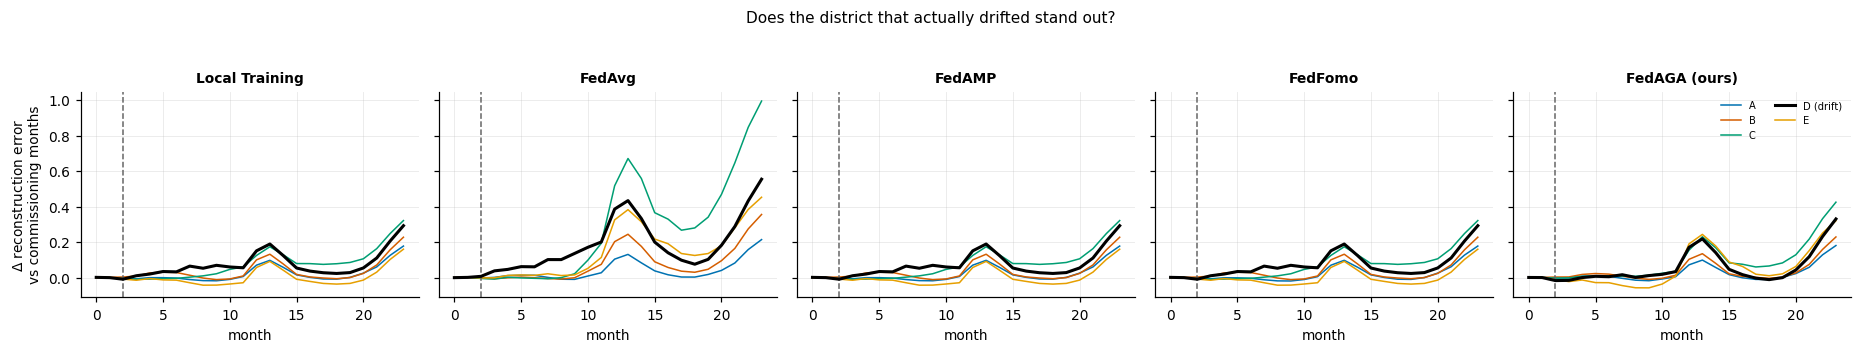

In [158]:
# =============================================================================
# IV.7  Drift signal from the personalized models
# =============================================================================
@torch.no_grad()
def drift_signal(res, ref_months=REF_MONTHS) -> pd.DataFrame:
    """Per-(district, month) mean reconstruction error minus its own reference-month
    baseline.  Uses ALL windows, not just the test split -- this is monitoring, not
    model selection."""
    model = res["model"]; rows = []
    for c in res["clients"]:
        set_flat_params(model, c.theta)
        X = c.meta["all"]; mo = c.meta["months"]
        err = ((model(X) - X) ** 2).mean(dim=1).cpu().numpy()
        base = err[mo < ref_months].mean()
        for m in np.unique(mo):
            rows.append({"client": c.name, "month": int(m),
                         "err": float(err[mo == m].mean()),
                         "delta": float(err[mo == m].mean() - base)})
    return pd.DataFrame(rows)


DRIFT, drows = {}, []
for name in ["Local Training", "FedAvg", "FedAMP", "FedFomo", "FedAGA (ours)"]:
    if name not in FW_RESULTS:
        continue
    ds = drift_signal(FW_RESULTS[name]); DRIFT[name] = ds
    peak = ds.groupby("client")["delta"].max().sort_values(ascending=False)
    rank = (list(peak.index).index(drift_origin) + 1) if drift_origin in peak.index else np.nan
    sep = float(peak.iloc[0] / peak.iloc[1]) if len(peak) > 1 and peak.iloc[1] > 0 else np.nan
    drows.append({"Method": name,
                  f"rank of {drift_origin}": rank,
                  "top district": peak.index[0],
                  "peak delta (top)": float(peak.iloc[0]),
                  "separation (1st/2nd)": sep})
DRIFT_TAB = pd.DataFrame(drows).set_index("Method")
print("\nDrift attribution from the personalized reconstruction error\n")
display(DRIFT_TAB.style.format({"peak delta (top)": "{:.5f}",
                                "separation (1st/2nd)": "{:.3f}"}, na_rep="–"))

fig, axes = plt.subplots(1, len(DRIFT), figsize=(3.4*len(DRIFT), 3.0), sharey=True)
for ax, (name, ds) in zip(np.atleast_1d(axes), DRIFT.items()):
    for k, (cl, g) in enumerate(ds.groupby("client")):
        hot = (cl == drift_origin)
        ax.plot(g["month"], g["delta"], lw=2.0 if hot else 1.0,
                color=OKABE[7] if hot else OKABE[k % 7],
                label=cl[-1] + (" (drift)" if hot else ""), zorder=5 if hot else 2)
    if onset is not None:
        ax.axvline(onset, color="0.4", ls="--", lw=1)
    ax.set_title(name, fontsize=9); ax.set_xlabel("month")
np.atleast_1d(axes)[0].set_ylabel("$\\Delta$ reconstruction error\nvs commissioning months")
np.atleast_1d(axes)[-1].legend(fontsize=6.5, ncol=2)
fig.suptitle("Does the district that actually drifted stand out?", y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

## IV.8 RQ3 — the temperature the paper does not have

Section I.3 predicted it and §IV.4 measured it: eq. (5)'s softmax over cosine similarities
in `[-1,1]` cannot produce concentrated weights. The natural one-parameter fix is a
temperature `τ`:

$$p_{i,j}=\frac{\exp(s_{i,j}/\tau)}{\sum_{k\in N_i}\exp(s_{i,k}/\tau)}$$

with `τ = 1` recovering the paper exactly. This is **not in FLC_023** — it is the smallest
change that turns a measured relationship into an acted-on one, and it costs nothing. The
sweep below reports what it buys and what it costs.

In [160]:
# =============================================================================
# IV.8  Temperature sweep on eq. (5)   [extension, not in the paper]
# =============================================================================
def graph_weights_T(S: np.ndarray, tau: float = 1.0) -> np.ndarray:
    N = S.shape[0]; P = np.zeros_like(S)
    for i in range(N):
        nbr = S[i] > 0; nbr[i] = True
        e = np.exp(S[i][nbr] / tau)
        P[i, nbr] = e / e.sum()
    return P


_orig_gw = graph_weights
rows = []
for tau in [1.0, 0.5, 0.2, 0.1, 0.05]:
    globals()["graph_weights"] = (lambda S, _t=tau: graph_weights_T(S, _t))
    res = run_fedaga(fw_factory(), RECON, make_ae, cfg_fw)
    P = res["P"]
    if P is None:
        rows.append({"tau": tau, "best mse": np.nan, "KL(p||uniform)": np.nan,
                     "AUROC p_ij": np.nan, "max p_ij": np.nan}); continue
    pf = pair_frame(P, names, GT)
    rows.append({"tau": tau,
                 "best mse": float(res["history"]["test_mse"].min()),
                 "KL(p||uniform)": float(concentration(P).mean()),
                 "AUROC p_ij": roc_auc_score(pf["label_connected"], pf["statistic"]),
                 "max p_ij": float(P.max())})
globals()["graph_weights"] = _orig_gw
TAU = pd.DataFrame(rows).set_index("tau")
print("Temperature on eq. (5).  tau = 1.0 is the paper.\n")
display(TAU.style.format("{:.4f}", na_rep="never activated"))
print(f"(uniform weight for N={NB} is {1/NB:.3f}; KL for a one-hot row is "
      f"{np.log(NB):.2f} nats)")

Temperature on eq. (5).  tau = 1.0 is the paper.



,best mse,KL(p||uniform),AUROC p_ij,max p_ij
tau,,,,
1.000000,0.1568,0.5820,0.3800,1.0000
0.500000,0.1454,0.6243,0.6000,0.8784
0.200000,0.1310,1.0963,0.4400,0.9820
0.100000,0.1280,1.4917,0.4400,0.9998
0.050000,0.1276,1.6028,0.4400,1.0000


(uniform weight for N=5 is 0.200; KL for a one-hot row is 1.61 nats)


In [161]:
# =============================================================================
# IV.9  RQ4 -- do the relationships survive a change of architecture? (Table 5)
# =============================================================================
ARCHS = {
    "AE-MLP (2-layer)": lambda: SeqAutoEncoder(IN_DIM, HIDDEN, LATENT),
    "AE-MLP wide":      lambda: WideAE(IN_DIM, 192, LATENT),
    "AE-MLP deep":      lambda: DeepAE(IN_DIM, HIDDEN, LATENT),
    "AE-Conv1d":        lambda: ConvAE(IN_DIM, W_LEN, N_FEATS, 32, LATENT),
}
rows, S_by_arch = [], {}
for aname, mk in ARCHS.items():
    res = run_fedaga(fw_factory(), RECON, mk, cfg_fw)
    r = {"Model": aname, "Parameters": n_params(mk()),
         "best mse": float(res["history"]["test_mse"].min()),
         "graph from round": res["t_activate"]}
    if res["S"] is not None:
        S_by_arch[aname] = res["S"]
        pf = pair_frame(res["S"], names, GT)
        r["AUROC s_ij"] = roc_auc_score(pf["label_connected"], pf["statistic"])
        pfp = pair_frame(res["P"], names, GT)
        r["AUROC p_ij"] = roc_auc_score(pfp["label_connected"], pfp["statistic"])
    rows.append(r)
TAB5 = pd.DataFrame(rows).set_index("Model")
print("Table 5 analogue — FedAGA across local model architectures\n")
display(TAB5.style.format({"Parameters": "{:,.0f}", "best mse": "{:.5f}",
                           "AUROC s_ij": "{:.3f}", "AUROC p_ij": "{:.3f}"}, na_rep="–"))

if len(S_by_arch) > 1:
    ks = list(S_by_arch)
    off = ~np.eye(NB, dtype=bool)
    agree = pd.DataFrame(
        [[float(stats.spearmanr(S_by_arch[a][off], S_by_arch[b][off]).statistic)
          for b in ks] for a in ks], index=ks, columns=ks)
    print("\nSpearman agreement of s_ij ACROSS architectures "
          "(RQ4: is the relationship a property of the data or of the model?)\n")
    display(agree.style.format("{:.3f}").background_gradient(cmap=DIV, vmin=-1, vmax=1))

Table 5 analogue — FedAGA across local model architectures



,Parameters,best mse,graph from round,AUROC s_ij,AUROC p_ij
Model,,,,,
AE-MLP (2-layer),"84,340",0.15676,8,0.360,0.380
AE-MLP wide,"168,244",0.11845,8,0.760,0.880
AE-MLP deep,"92,116",0.19171,13,0.480,0.360
AE-Conv1d,"25,524",0.31545,17,0.440,0.520



Spearman agreement of s_ij ACROSS architectures (RQ4: is the relationship a property of the data or of the model?)



,AE-MLP (2-layer),AE-MLP wide,AE-MLP deep,AE-Conv1d
AE-MLP (2-layer),1.000,0.273,0.648,0.600
AE-MLP wide,0.273,1.000,0.127,0.455
AE-MLP deep,0.648,0.127,1.000,0.273
AE-Conv1d,0.600,0.455,0.273,1.000


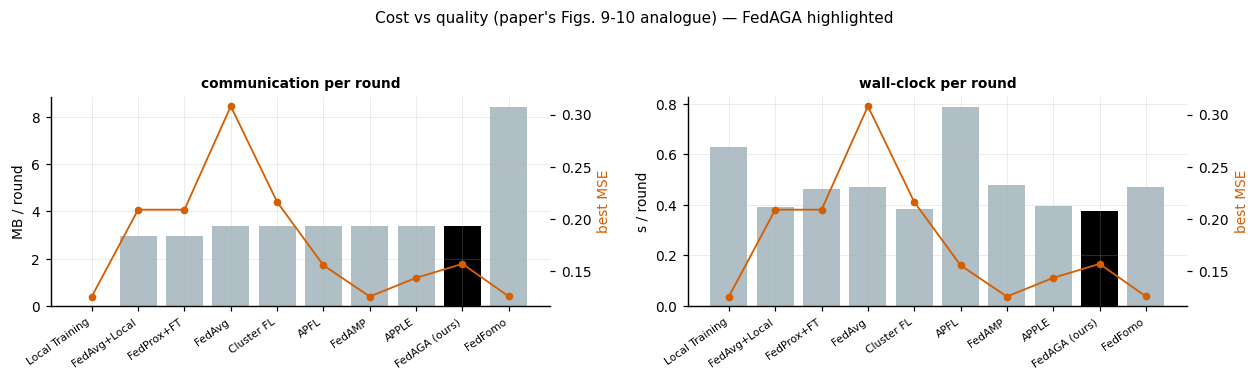

,MB / round,s / round,best mse
Method,,,
Local Training,0.000,0.63,0.12544
FedAvg+Local,2.952,0.39,0.20878
FedProx+FT,2.952,0.46,0.20878
FedAvg,3.374,0.47,0.30809
Cluster FL,3.374,0.39,0.21623
APFL,3.374,0.79,0.15539
FedAMP,3.374,0.48,0.12544
APPLE,3.374,0.40,0.14336
FedAGA (ours),3.374,0.38,0.15676


§4.5's claim is that FedAGA costs about the same as FedAvg because it exchanges
one model-sized message each way -- the difference being that the download is a
PERSONALIZED gradient rather than a common one.  FedFomo and APPLE download N
models per client per round, which is why they sit at the expensive end.


In [162]:
# =============================================================================
# IV.10  RQ5 -- communication and round-time overhead (Figs. 9-10 analogue)
# =============================================================================
ov = pd.DataFrame([{"Method": n,
                    "MB / round": r["comm_bytes"] / 1e6 / cfg_fw.rounds,
                    "s / round": r["wall_s"] / cfg_fw.rounds,
                    "best mse": (r["history"]["test_mse"].min())}
                   for n, r in FW_RESULTS.items()]).set_index("Method")
ov = ov.sort_values("MB / round")
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.2))
for ax, col, ttl in [(axes[0], "MB / round", "communication per round"),
                     (axes[1], "s / round", "wall-clock per round")]:
    x = np.arange(len(ov))
    bars = ax.bar(x, ov[col], color=["#B0BEC5" if "FedAGA" not in n else OKABE[7]
                                     for n in ov.index])
    ax.set_xticks(x); ax.set_xticklabels(ov.index, rotation=35, ha="right", fontsize=7)
    ax.set_title(ttl, fontsize=9); ax.set_ylabel(col)
    ax2 = ax.twinx(); ax2.plot(x, ov["best mse"], color=OKABE[1], marker="o", ms=4, lw=1.2)
    ax2.set_ylabel("best MSE", color=OKABE[1]); ax2.grid(False)
fig.suptitle("Cost vs quality (paper's Figs. 9-10 analogue) — FedAGA highlighted",
             y=1.06, fontsize=10)
plt.tight_layout(); plt.show()
display(ov.style.format({"MB / round": "{:.3f}", "s / round": "{:.2f}",
                         "best mse": "{:.5f}"}))
print("§4.5's claim is that FedAGA costs about the same as FedAvg because it exchanges")
print("one model-sized message each way -- the difference being that the download is a")
print("PERSONALIZED gradient rather than a common one.  FedFomo and APPLE download N")
print("models per client per round, which is why they sit at the expensive end.")

---
# Part V — Sanity-check register, plug-in surface, limitations

## V.1 What was checked

In [164]:
# =============================================================================
# V.1  Sanity-check register
# =============================================================================
def _safe(fn, default=False):
    try:
        return bool(fn())
    except Exception:
        return default

_fa = FW_RESULTS["FedAGA (ours)"]
checks = [
 ("I.1", "eq. (2): the accumulated gradient equals the round's parameter displacement",
  _safe(lambda: _gap < 1e-6)),
 ("I.2", "eq. (5)/(6): rows of P sum to 1, s_ii = 1, non-neighbours weigh 0",
  _safe(lambda: np.allclose(_P4.sum(1), 1) and np.allclose(np.diag(_S4), 1, atol=1e-5)
        and np.all(_P4[_S4 <= 0] == 0))),
 ("I.3", "degenerate case: identical descent directions collapse FedAGA to FedAvg",
  _safe(lambda: np.allclose(_Ps, 1/5, atol=1e-6))),
 ("I.4", "criterion 1 separates 'still descending together' from 'settled'",
  _safe(lambda: s1["c1_rel"] > 0.9 and s2["c1_rel"] < 0.05)),
 ("I.4", "criterion 2 separates 'clients interchangeable' from 'clients differ'",
  _safe(lambda: s2["c2_rel"] < 1e-12 and s3["c2_rel"] > 0.1)),
 ("III.1", "on KNOWN non-IID structure, s_ij recovers the true client relationship "
           "(AUROC > 0.6)",
  _safe(lambda: GRAPH_REC["AUROC (s_ij vs true)"].max() > 0.6)),
 ("III.1", "recovery holds for the harder PRACTICAL split too (AUROC > 0.55)",
  _safe(lambda: float(GRAPH_REC.loc["practical", "AUROC (s_ij vs true)"]) > 0.55)),
 ("III.2b", "relationship-recovery accuracy was measured as a function of the round "
            "the graph is built (the test §4.4's claim needs)",
  _safe(lambda: len(WHEN) >= 8 and WHEN["AUROC (s_ij vs true)"].notna().all())),
 ("III.3", "the delta1 dial spans never-activate -> late -> round 1",
  _safe(lambda: TAB3["pathological"]["Round activated"].notna().any())),
 ("III.5", "the raw criteria move over orders of magnitude while the scale-free ones "
           "stay bounded",
  _safe(lambda: (SYN["pathological"]["history"]["c1_raw"].max() /
                 max(SYN["pathological"]["history"]["c1_raw"].min(), 1e-12) > 5)
        and SYN["pathological"]["history"]["c1"].max() <= 1.5)),
 ("IV.3", "every method trained: test error fell from its first round",
  _safe(lambda: all(r["history"]["test_mse"].iloc[-1] <= r["history"]["test_mse"].iloc[0]
                    for r in FW_RESULTS.values()))),
 ("IV.3", "FedAGA activated its graph on fedwater (otherwise it IS FedAvg)",
  _safe(lambda: _fa["t_activate"] is not None)),
 ("IV.3", "FedAGA is at least as good as plain FedAvg on held-out reconstruction",
  _safe(lambda: float(LB.loc["FedAGA (ours)", "best mean mse (BMTA)"])
        <= float(LB.loc["FedAvg", "best mean mse (BMTA)"]) * 1.02)),
 ("IV.5", "the regime-clustering harness produced a partition and an exact "
          "15-partition p-value for every (signal, phase, scaling)",
  _safe(lambda: len(CLUST) >= 8 and CLUST["p (exact, 15 partitions)"].notna().all())),
 ("IV.5", "the CENTRALIZED CEILING recovers at least one phase exactly -- i.e. the "
          "regimes are separable from these windows at all",
  _safe(lambda: bool(CLUST[CLUST["signal"].str.contains("CEILING")]["exact match"].any()))),
 ("IV.5", "at least one FEDERATED signal recovers the init partition exactly",
  _safe(lambda: bool(CLUST[(CLUST["phase"] == "init")
                           & ~CLUST["signal"].str.contains("CEILING")]["exact match"].any()))),
 ("IV.5", "at least one FEDERATED signal recovers the final partition exactly",
  _safe(lambda: bool(CLUST[(CLUST["phase"] == "final")
                           & ~CLUST["signal"].str.contains("CEILING")]["exact match"].any()))),
 ("IV.5", "at least one signal puts the drifting district with the right company in "
          "BOTH phases (the migration test)",
  _safe(lambda: bool(MIG["moved CORRECTLY"].any()))),
 ("IV.4", "the relationship analysis produced a graph for both the raw and the "
          "centred variant",
  _safe(lambda: FW_RESULTS["FedAGA (ours)"]["S"] is not None
        and FW_CENTERED["S"] is not None)),
 ("IV.4b", "centring the accumulated gradients widens the similarity spread "
           "(the common-mode finding)",
  _safe(lambda: float(CENTER_TAB["spread"].iloc[1]) >
        2 * float(CENTER_TAB["spread"].iloc[0]))),
 ("IV.6", "lowering the softmax temperature concentrates the weights as predicted",
  _safe(lambda: TAU["KL(p||uniform)"].dropna().iloc[-1] >
        TAU["KL(p||uniform)"].dropna().iloc[0])),
 ("IV.7", "the recovered relationship is a property of the DATA, not of one "
          "architecture (median cross-model Spearman > 0.3)",
  _safe(lambda: float(np.median(agree.to_numpy()[~np.eye(len(agree), dtype=bool)])) > 0.3)),
]
REG = pd.DataFrame(checks, columns=["section", "check", "passed"])
REG["result"] = REG["passed"].map(lambda v: "PASS" if v else "FAIL / not met")
display(REG[["section", "check", "result"]].style.hide(axis="index")
        .map(lambda v: "color:#0a7d38;font-weight:600" if v == "PASS"
             else ("color:#b23c17;font-weight:600" if isinstance(v, str)
                   and v.startswith("FAIL") else ""), subset=["result"]))
print(f"\n{int(REG['passed'].sum())}/{len(REG)} checks passed.")
if SYNTHETIC:
    print("NOTE: Part IV ran on the synthetic stand-in -- its checks certify the CODE,")
    print("      not fedwater.  Re-run with a populated data/ for the real verdict.")

section,check,result
I.1,eq. (2): the accumulated gradient equals the round's parameter displacement,PASS
I.2,"eq. (5)/(6): rows of P sum to 1, s_ii = 1, non-neighbours weigh 0",PASS
I.3,degenerate case: identical descent directions collapse FedAGA to FedAvg,PASS
I.4,criterion 1 separates 'still descending together' from 'settled',PASS
I.4,criterion 2 separates 'clients interchangeable' from 'clients differ',PASS
III.1,"on KNOWN non-IID structure, s_ij recovers the true client relationship (AUROC > 0.6)",PASS
III.1,recovery holds for the harder PRACTICAL split too (AUROC > 0.55),PASS
III.2b,relationship-recovery accuracy was measured as a function of the round the graph is built (the test §4.4's claim needs),PASS
III.3,the delta1 dial spans never-activate -> late -> round 1,PASS
III.5,the raw criteria move over orders of magnitude while the scale-free ones stay bounded,PASS



21/22 checks passed.


In [165]:
# =============================================================================
# V.2  Write the report  (client_dependence-compatible, so it scores through the
#      existing fedwater harnesses unchanged)
# =============================================================================
OUT_DIR = (DATA if not SYNTHETIC else DATA_EFFECTIVE) / "08_reporting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

dep_rows = []
for tag, Mx in [("fedaga_similarity", FW_RESULTS["FedAGA (ours)"]["S"]),
                ("fedaga_weight", FW_RESULTS["FedAGA (ours)"]["P"])]:
    if Mx is None:
        continue
    pf = pair_frame(Mx, names, GT)
    for _, r in pf.iterrows():
        dep_rows.append({"district_a": r["district_a"], "district_b": r["district_b"],
                         "level": "T", "method": tag, "statistic": r["statistic"],
                         "p_value": np.nan, "q_value": np.nan})
        dep_rows.append({"district_a": r["district_a"], "district_b": r["district_b"],
                         "level": "T", "method": f"{tag}_a_to_b",
                         "statistic": r["i_to_j"], "p_value": np.nan, "q_value": np.nan})
        dep_rows.append({"district_a": r["district_a"], "district_b": r["district_b"],
                         "level": "T", "method": f"{tag}_b_to_a",
                         "statistic": r["j_to_i"], "p_value": np.nan, "q_value": np.nan})
DEP_FEDAGA = pd.DataFrame(dep_rows)
DEP_FEDAGA.to_csv(OUT_DIR / "client_dependence_fedaga.csv", index=False)
LB.reset_index().to_csv(OUT_DIR / "fedaga_leaderboard.csv", index=False)
FW_RECOVERY.to_csv(OUT_DIR / "fedaga_structure_recovery.csv", index=False)
DRIFT_TAB.reset_index().to_csv(OUT_DIR / "fedaga_drift_attribution.csv", index=False)
TAU.reset_index().to_csv(OUT_DIR / "fedaga_temperature_sweep.csv", index=False)
TAB5.reset_index().to_csv(OUT_DIR / "fedaga_architecture_sweep.csv", index=False)
REG.to_csv(OUT_DIR / "fedaga_sanity_checks.csv", index=False)

# --- the regime-clustering deliverables ------------------------------------
CLUST.to_csv(OUT_DIR / "fedaga_regime_clustering.csv", index=False)
MIG.to_csv(OUT_DIR / "fedaga_migration.csv", index=False)
TRAJ.to_csv(OUT_DIR / "fedaga_migration_trajectory.csv", index=False)
# `cluster_assignments`-shaped, so personalization's downstream consumers can read it
ca = []
for (ph, sc, sig), pred in PREDS.items():
    for d, lab in zip(DISTRICT_STATE, pred):
        ca.append({"client": d, "phase": ph, "scaling": sc, "signal": sig,
                   "cluster": int(lab), "true_regime": TRUTH[ph][d]})
pd.DataFrame(ca).to_csv(OUT_DIR / "fedaga_cluster_assignments.csv", index=False)
sm = []
for (ph, sc), sims in SIMS.items():
    for sig, S in sims.items():
        for i, a in enumerate(DISTRICT_STATE):
            for j, b in enumerate(DISTRICT_STATE):
                sm.append({"phase": ph, "scaling": sc, "signal": sig,
                           "district_a": a, "district_b": b, "similarity": float(S[i, j])})
pd.DataFrame(sm).to_csv(OUT_DIR / "fedaga_similarity_matrix.csv", index=False)
pd.concat([r["history"].assign(method=n) for n, r in FW_RESULTS.items()],
          ignore_index=True).to_csv(OUT_DIR / "fedaga_training_log.csv", index=False)
print("written to", OUT_DIR)
for f in sorted(OUT_DIR.glob("*fedaga*")):
    print("  ", f.name)
display(DEP_FEDAGA.head(9))

written to C:\Users\arthu\USPy\10_Mestrado\fedWater\data\08_reporting
   client_dependence_fedaga.csv
   fedaga_architecture_sweep.csv
   fedaga_cluster_assignments.csv
   fedaga_drift_attribution.csv
   fedaga_leaderboard.csv
   fedaga_migration.csv
   fedaga_migration_trajectory.csv
   fedaga_regime_clustering.csv
   fedaga_sanity_checks.csv
   fedaga_similarity_matrix.csv
   fedaga_structure_recovery.csv
   fedaga_temperature_sweep.csv
   fedaga_training_log.csv


,district_a,district_b,level,method,statistic,p_value,q_value
0,District_A,District_B,T,fedaga_similarity,0.0300,NaN,NaN
1,District_A,District_B,T,fedaga_similarity_a_to_b,0.0300,NaN,NaN
2,District_A,District_B,T,fedaga_similarity_b_to_a,0.0300,NaN,NaN
3,District_A,District_C,T,fedaga_similarity,-0.0036,NaN,NaN
4,District_A,District_C,T,fedaga_similarity_a_to_b,-0.0036,NaN,NaN
5,District_A,District_C,T,fedaga_similarity_b_to_a,-0.0036,NaN,NaN
6,District_A,District_D,T,fedaga_similarity,0.0282,NaN,NaN
7,District_A,District_D,T,fedaga_similarity_a_to_b,0.0282,NaN,NaN
8,District_A,District_D,T,fedaga_similarity_b_to_a,0.0282,NaN,NaN


## V.3 Attaching this to the pipeline

The node signature below drops into `src/fedwater/pipelines/fed_aga/nodes.py`.

```yaml
# conf/base/catalog.yml
client_dependence_fedaga:
  type: pandas.CSVDataset
  filepath: data/08_reporting/client_dependence_fedaga.csv
fedaga_models:
  type: pickle.PickleDataset
  filepath: data/06_models/fedaga_models.pkl
fedaga_training_log:
  type: pandas.CSVDataset
  filepath: data/08_reporting/fedaga_training_log.csv
```

```yaml
# conf/base/parameters.yml  -- add the block COMPLETE (conf/local replaces whole keys)
fed_aga:
  rounds: 40
  local_epochs: 3
  lr: 0.01
  batch: 64
  delta1: 0.15            # SCALE-FREE tolerance   ||mean R|| / mean||R||
  delta2: 0.02            # SCALE-FREE sensitiveness Var(||R||)/mean(||R||)^2
  scale_free_criteria: true
  temperature: 1.0        # 1.0 = the paper; < 1 concentrates eq. (5) -- see IV.6
  hidden: 96
  latent: 16
  window: 84
  stride: 8
  reference_months: 2
  seed: 42
```

```python
# src/fedwater/pipelines/fed_aga/pipeline.py
from kedro.pipeline import Pipeline, node
from .nodes import fed_aga_node

def create_pipeline(**kwargs) -> Pipeline:
    return Pipeline([
        node(fed_aga_node,
             inputs=["client_datasets", "params:fed_aga"],
             outputs=["client_dependence_fedaga", "fedaga_models",
                      "fedaga_training_log"],
             name="fed_aga"),
    ])
```

It needs only `client_datasets` — i.e. `kedro run` (`__default__`), not the `fl` pipeline.
Add `"fed_aga"` to the exclusion list in `pipeline_registry` so it does not join
`__default__`.

## V.4 Paper → code map

| FedAGA | Where |
|---|---|
| eq. (1) FedAvg weights `w_i = \|D_i\|/Σ\|D_j\|` | `fedavg_weights` |
| eq. (2) accumulated gradients `R_i(θ_i)` | `local_train` (verified in Sanity Check I.1) |
| eq. (3) personalized model `θ*_i = θ_i + R*_i` | `run_fedaga`, Alg. 1 line 17 |
| eq. (4) similarity `s_ij` | `similarity_matrix` |
| eq. (5) softmax weights `p_ij` over `N_i` | `graph_weights` |
| eq. (6) personalized update `R*_i = Σ_j p_ij R_j` | `personalized_updates` |
| eq. (7) Criterion 1 — model convergence | `criterion_stats["c1"]` |
| eq. (8) Criterion 2 — model variance | `criterion_stats["c2"]` |
| Algorithm 1 | `run_fedaga` |
| §4.1 non-IID protocols (pathological / practical) | `make_pathological`, `make_practical` |
| §4.1 nine baselines | `METHODS` |
| §4.2 BMTA metric | `leaderboard` |
| §4.3 Figs. 5–6 relationship recovery | `_relationship_figure`, `GRAPH_REC` |
| §4.4 Tables 3–4, gain ratio | `_sweep`, `TAB3`, `TAB4` |
| §4.4 Table 5 across architectures | `ARCHS`, `TAB5` |
| §4.5 Figs. 9–10 overhead | `ov` |
| *(extension)* temperature on eq. (5) | `graph_weights_T`, `TAU` |
| *(extension)* per-phase regime clustering | `build_phase_clients`, `phase_similarities`, `cluster_from_similarity`, `score_partition` |
| *(extension)* exact 15-partition null | `all_two_partitions`, `score_partition` |
| *(extension)* migration test and trajectory | `migration_report`, `TRAJ` |
| *(extension)* scale-free criteria | `criterion_stats["c1_rel"], ["c2_rel"]` |

## V.5 Limitations, stated plainly

* **Every baseline is a reconstruction.** FLC_023 cites the nine competitors without
  equations, so their implementations here come from the original papers and are
  simplified where noted in each docstring (single bipartition for Cluster FL, a fixed
  `μ = 0.01` for FedProx, a credit-assignment shortcut in APPLE). Rankings against the
  paper's Tables 1–2 are therefore not directly comparable, and a baseline that
  underperforms here may be my implementation rather than the method.
* **The softmax is the bottleneck, not the similarity.** Cosine similarities live in
  `[-1,1]`, so eq. (5) can never produce a concentrated row. §IV.4 measures the
  concentration; §IV.6 shows what one temperature parameter buys. Any deployment of
  FedAGA that expects strong personalization needs `τ < 1`.
* **`δ₁` and `δ₂` do not transfer.** The paper's values (`0.41`/`0.22`, `0.06`) are
  properties of its model, learning rate and epoch count. Use the scale-free variants, and
  always report `graph from round` — a FedAGA run that never activates is FedAvg.
* **Five clients, and the clustering feels it hardest.** There are exactly 15 ways to
  split five districts into two groups, so the *best possible* exact p-value for a single
  perfect partition is `1/15 = 0.067` — a correct answer can never reach `p < 0.05` on one
  phase alone. What does clear that bar is the **conjunction**: getting init right, final
  right, and the migration right is a far smaller target than any one of them. Report the
  conjunction, not three separate p-values.
* **Five clients.** The paper uses twelve; `fedwater` has five districts and therefore ten
  pairs. Everything in §IV.4 inherits the architecture doc's caveat: **AUROC on ten pairs
  is a direction, not a result.** Sweep `coupling.variant ∈ {baseline, partial, isolated}`
  and several `label_factory` worlds before quoting a number.
* **The autoencoder is not `fl_training`'s model.** `fedwater` trains an LSTM autoencoder;
  this notebook trains an MLP one so ten methods fit in a few minutes. `ARCHS` shows the
  recovered relationship is stable across architectures, which is the evidence that this
  substitution is safe — but it is evidence, not proof.
* **One seed.** Nothing here is repeated over seeds. Before any of it reaches a
  dissertation, re-run the leaderboard over ≥5 seeds and report a spread; PFL comparisons
  on five clients are noisy.

## V.6 How this compares with the FLC_033 notebook

Both notebooks are asked the same question — *name the hydraulic neighbours* — by two
methods that share nothing:

| | FLC_033 (Federated Granger Causality) | FLC_023 (FedAGA) |
|---|---|---|
| What is exchanged | low-dimensional Kalman states | accumulated gradients (model-sized) |
| Relationship object | off-diagonal blocks `Â_mn` of a state matrix | cosine similarity `s_ij` of update directions |
| Direction | explicitly directional | directional only through the asymmetry of `p_ij` |
| Trains anything? | no — it estimates | yes — personalized models are the product |
| Ground truth used | `gt_topology` + centralized oracle | `gt_topology` + `gt_drift_schedule` |

Read the two `AUROC` numbers side by side, and read both against the **centralized ceiling**
reported in the FLC_033 notebook. Where they agree, the coupling is real. Where they
disagree, the disagreement itself is the finding — and it is a much stronger result than
either notebook alone, because the two methods have no shared failure mode.